## ANNEX A: DATA ENGINEERING

## Step 1 - Data Engineering Process (Summary)

### Step 1.1 Download data:

### Step 1.1.1 Weather data
#### Step 1.1.1.1 Download weather data:

We start by downloading unstructured data from https://open-meteo.com/en/docs/historical-weather-api

In [1]:
import requests
import pandas as pd
from pathlib import Path

# Configuration
NYC_LATITUDE = 40.7128
NYC_LONGITUDE = -74.0060
TIMEZONE = "America/New_York"

# Date range for 2024 (January 1 to November 30, 2024)
START_DATE = "2024-01-01"
END_DATE = "2025-11-30"

# Output path (relative to this script's location: scripts/../meteorology)
OUTPUT_DIR = Path.cwd() / "meteorology"
OUTPUT_FILE = OUTPUT_DIR / "weather_nyc_2024_jan_nov.csv"

# Ensure output directory exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("NYC WEATHER DATA DOWNLOAD - 2024-2025")
print("="*80)
print()
print(f"Location: New York City ({NYC_LATITUDE}, {NYC_LONGITUDE})")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Timezone: {TIMEZONE}")
print(f"Output: {OUTPUT_FILE}")
print()

# Build API request URL
base_url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": NYC_LATITUDE,
    "longitude": NYC_LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": [
        "temperature_2m",
        "precipitation",
        "weathercode",
        "windspeed_10m",
        "visibility"
    ],
    "timezone": TIMEZONE,
    "temperature_unit": "fahrenheit",
    "windspeed_unit": "mph",
    "precipitation_unit": "inch"
}

print("Requesting data from Open-Meteo API...")
print(f"URL: {base_url}")
print()

# Make API request
try:
    response = requests.get(base_url, params=params)
    response.raise_for_status()
    data = response.json()
    print("✓ Data downloaded successfully")
    print()
except requests.exceptions.RequestException as e:
    print(f"ERROR: Failed to download data: {e}")
    exit(1)

# Extract hourly data
hourly = data['hourly']

# Create DataFrame
df = pd.DataFrame({
    'datetime': pd.to_datetime(hourly['time']),
    'temperature': hourly['temperature_2m'],
    'precipitation': hourly['precipitation'],
    'weathercode': hourly['weathercode'],
    'windspeed': hourly['windspeed_10m'],
    'visibility': hourly['visibility']
})

print("Data structure:")
print(f"  Records: {len(df):,}")
print(f"  Columns: {len(df.columns)}")
print(f"  Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print()

NYC WEATHER DATA DOWNLOAD - 2024-2025

Location: New York City (40.7128, -74.006)
Date range: 2024-01-01 to 2025-11-30
Timezone: America/New_York
Output: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/meteorology/weather_nyc_2024_jan_nov.csv

Requesting data from Open-Meteo API...
URL: https://archive-api.open-meteo.com/v1/archive

✓ Data downloaded successfully

Data structure:
  Records: 16,800
  Columns: 6
  Date range: 2024-01-01 00:00:00 to 2025-11-30 23:00:00



### Step 1.1.1.2 transform and encode weather data using WMO codes

In [2]:
# WMO codes: https://open-meteo.com/en/docs
def classify_weather(code):
    """Classify WMO weather code into weather type."""
    if pd.isna(code):
        return 'clear'
    
    code = int(code)
    
    # Clear sky
    if code == 0:
        return 'clear'
    
    # Mainly clear, partly cloudy, overcast
    elif code in [1, 2, 3]:
        return 'cloudy'
    
    # Fog
    elif code in [45, 48]:
        return 'fog'
    
    # Drizzle
    elif code in [51, 53, 55, 56, 57]:
        return 'rain'
    
    # Rain
    elif code in [61, 63, 65, 66, 67, 80, 81, 82]:
        return 'rain'
    
    # Snow
    elif code in [71, 73, 75, 77, 85, 86]:
        return 'snow'
    
    # Thunderstorm
    elif code in [95, 96, 99]:
        return 'storm'
    
    else:
        return 'clear'

print("Classifying weather types...")
df['weather_type'] = df['weathercode'].apply(classify_weather)
df.head()

Classifying weather types...


,datetime,temperature,precipitation,weathercode,windspeed,visibility,weather_type
0,2024-01-01 00:00:00,35.3,0.0,3,3.9,None,cloudy
1,2024-01-01 01:00:00,35.2,0.0,3,5.5,None,cloudy
2,2024-01-01 02:00:00,37.0,0.0,3,7.1,None,cloudy
3,2024-01-01 03:00:00,37.2,0.0,3,6.0,None,cloudy
4,2024-01-01 04:00:00,37.0,0.0,2,5.0,None,cloudy


### 1.1.1.3 Basic stats and Nan verification for weather

In [3]:
# Weather type distribution
print()
print("Weather type distribution:")
weather_counts = df['weather_type'].value_counts()
for weather, count in weather_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {weather:10s}: {count:,} ({pct:.1f}%)")
print()

# Basic statistics
print("Basic statistics:")
print(f"  Avg temperature: {df['temperature'].mean():.1f}°F")
print(f"  Min temperature: {df['temperature'].min():.1f}°F")
print(f"  Max temperature: {df['temperature'].max():.1f}°F")
print(f"  Total precipitation: {df['precipitation'].sum():.2f} inches")
print(f"  Avg wind speed: {df['windspeed'].mean():.1f} mph")
print()

# Check for missing values
print("Missing values:")
missing = df.isnull().sum()
for col, count in missing.items():
    if count > 0:
        pct = (count / len(df)) * 100
        print(f"  {col}: {count:,} ({pct:.2f}%)")
if missing.sum() == 0:
    print("  None")
print()

# Save to CSV
print(f"Saving to: {OUTPUT_FILE.name}")
df.to_csv(OUTPUT_FILE, index=False)

file_size_mb = OUTPUT_FILE.stat().st_size / (1024**2)
print(f"✓ File saved: {file_size_mb:.2f} MB")
print()

# Display sample
print("Sample data (first 5 rows):")
print(df.head())
print()

print("="*80)
print("DOWNLOAD COMPLETE")
print("="*80)
print()
print(f"✓ Weather data for 2024 ready: {OUTPUT_FILE}")
print(f"✓ {len(df):,} hourly observations")
print(f"✓ Date range: {START_DATE} to {END_DATE}")
print()


Weather type distribution:
  cloudy    : 8,583 (51.1%)
  clear     : 5,797 (34.5%)
  rain      : 2,225 (13.2%)
  snow      : 195 (1.2%)

Basic statistics:
  Avg temperature: 56.1°F
  Min temperature: 2.0°F
  Max temperature: 104.7°F
  Total precipitation: 91.84 inches
  Avg wind speed: 6.9 mph

Missing values:
  visibility: 16,800 (100.00%)

Saving to: weather_nyc_2024_jan_nov.csv
✓ File saved: 0.69 MB

Sample data (first 5 rows):
             datetime  temperature  precipitation  weathercode  windspeed  \
0 2024-01-01 00:00:00         35.3            0.0            3        3.9   
1 2024-01-01 01:00:00         35.2            0.0            3        5.5   
2 2024-01-01 02:00:00         37.0            0.0            3        7.1   
3 2024-01-01 03:00:00         37.2            0.0            3        6.0   
4 2024-01-01 04:00:00         37.0            0.0            2        5.0   

  visibility weather_type  
0       None       cloudy  
1       None       cloudy  
2       None     

### Step 1.1.2 Download and initial transform for Uber and Yellow Data

#### 1.1.2.1 UBER data download

Uber data comes in a dataset called High Volume FHV Trip Records; let's download from 2024/01/01 to 2025/11/30

In [4]:
#!/usr/bin/env python3

import requests
from pathlib import Path
from tqdm import tqdm
import sys


def download_file(url: str, output_path: Path) -> bool:
    """Download a file with a progress bar."""
    try:
        if output_path.exists():
            size_mb = output_path.stat().st_size / (1024**2)
            print(f"  ✓ Already exists: {output_path.name} ({size_mb:.1f} MB)")
            return True

        response = requests.get(url, stream=True, timeout=30)
        response.raise_for_status()

        total = int(response.headers.get('content-length', 0))

        with open(output_path, 'wb') as f:
            with tqdm(total=total, unit='B', unit_scale=True,
                     desc=f"  {output_path.name}", leave=False) as pbar:
                for chunk in response.iter_content(8192):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))

        size_mb = output_path.stat().st_size / (1024**2)
        print(f"  ✓ Downloaded: {output_path.name} ({size_mb:.1f} MB)")
        return True

    except Exception as e:
        print(f"  ✗ Error {output_path.name}: {e}")
        if output_path.exists():
            output_path.unlink()
        return False


def main():
    print("="*80)
    print("DOWNLOAD: NYC UBER/HVFHV DATA")
    print("="*80)
    print()

    # Configuration
    BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"
    YEARS_MONTHS = {
        2024: list(range(1, 13)),  # Jan-Dec 2024
        2025: list(range(1, 12)),  # Jan-Nov 2025
    }

    # RELATIVE PATH - works both as a .py script and in a Jupyter notebook
    try:
        script_dir = Path(__file__).resolve().parent
    except NameError:
        script_dir = Path.cwd()
    output_dir = script_dir / "data" / "uber_raw"
    output_dir.mkdir(parents=True, exist_ok=True)

    total_files = sum(len(m) for m in YEARS_MONTHS.values())

    print(f"Project: {script_dir.name}")
    print(f"Output: {output_dir.relative_to(script_dir)}")
    print(f"Files: {total_files} (2024: 12, 2025: 11)")
    print(f"Note: HVFHV = High Volume For-Hire Vehicles (Uber, Lyft)")
    print()

    # Download
    stats = {'ok': 0, 'skip': 0, 'fail': 0}

    for year, months in YEARS_MONTHS.items():
        print(f"YEAR {year}:")
        print("-"*80)

        for month in months:
            # NYC TLC uses "fhvhv" prefix for Uber/Lyft
            filename = f"fhvhv_tripdata_{year}-{month:02d}.parquet"
            url = f"{BASE_URL}/{filename}"
            path = output_dir / filename

            if path.exists():
                stats['skip'] += 1
            elif download_file(url, path):
                stats['ok'] += 1
            else:
                stats['fail'] += 1
        print()

    # Summary
    print("="*80)
    print("SUMMARY - UBER/HVFHV")
    print("="*80)

    total_size = sum(f.stat().st_size for f in output_dir.glob("*.parquet")) / (1024**3)

    print(f"Total files: {total_files}")
    print(f"Downloaded: {stats['ok']}")
    print(f"Already existed: {stats['skip']}")
    print(f"Failed: {stats['fail']}")
    print(f"Total size: {total_size:.2f} GB")
    print(f"Location: {output_dir.relative_to(script_dir)}")
    print()

    if stats['fail'] > 0:
        print(f"⚠ {stats['fail']} files failed. Re-run to retry.")
        sys.exit(1)
    else:
        print("✓ Uber/HVFHV ready!")
        print("All raw data downloaded!")


if __name__ == "__main__":
    main()



DOWNLOAD: NYC UBER/HVFHV DATA

Project: ML1-FinalProject
Output: data/uber_raw
Files: 23 (2024: 12, 2025: 11)
Note: HVFHV = High Volume For-Hire Vehicles (Uber, Lyft)

YEAR 2024:
--------------------------------------------------------------------------------


  ✓ Downloaded: fhvhv_tripdata_2024-01.parquet (450.9 MB)


  ✓ Downloaded: fhvhv_tripdata_2024-02.parquet (441.1 MB)


  ✓ Downloaded: fhvhv_tripdata_2024-03.parquet (484.4 MB)


  ✓ Downloaded: fhvhv_tripdata_2024-04.parquet (454.1 MB)


...

  ✓ Downloaded: fhvhv_tripdata_2025-07.parquet (464.7 MB)


  ✓ Downloaded: fhvhv_tripdata_2025-08.parquet (457.4 MB)


  ✓ Downloaded: fhvhv_tripdata_2025-09.parquet (458.6 MB)


  ✓ Downloaded: fhvhv_tripdata_2025-10.parquet (494.5 MB)


  ✓ Downloaded: fhvhv_tripdata_2025-11.parquet (484.0 MB)

SUMMARY - UBER/HVFHV
Total files: 23
Downloaded: 23
Already existed: 0
Failed: 0
Total size: 10.43 GB
Location: data/uber_raw

✓ Uber/HVFHV ready!
All raw data downloaded!


##### 1.1.2.2 Filtering UBER

Uber comes with other provider as LYFT, so it is neccesary to filter only uber category: hvfhs_license_num  HV0003: Uber.

In [5]:
#!/usr/bin/env python3


from pathlib import Path
import pandas as pd
from datetime import datetime
from tqdm import tqdm


def filter_uber_file(input_path: Path, output_path: Path) -> dict:
    """
    Filter a single FHVHV file to keep only Uber (HV0003) trips.
    
    Returns:
        Dictionary with filtering statistics
    """
    # Load data
    df = pd.read_parquet(input_path)
    
    stats = {
        'file': input_path.name,
        'rows_in': len(df),
        'columns': len(df.columns)
    }
    
    # Filter for Uber only (HV0003)
    df_uber = df[df['hvfhs_license_num'] == 'HV0003'].copy()
    
    stats['rows_out'] = len(df_uber)
    stats['rows_removed'] = stats['rows_in'] - stats['rows_out']
    stats['pct_kept'] = (stats['rows_out'] / stats['rows_in']) * 100 if stats['rows_in'] > 0 else 0
    
    # Save filtered file
    df_uber.to_parquet(output_path, index=False, compression='snappy')
    stats['output_size_mb'] = output_path.stat().st_size / (1024**2)
    
    return stats


def main():
    """Filter all FHVHV files for Uber trips only."""
    
    print("="*70)
    print("UBER (HV0003) FILTERING")
    print("="*70)
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # Targets ML1-FinalProject for both input and output
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    input_dir = base_dir / "data" / "uber_raw"
    output_dir = base_dir / "uber_filtered"

    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all parquet files (2024 and 2025)
    parquet_files_2024 = sorted(input_dir.glob("fhvhv_tripdata_2024-*.parquet"))
    parquet_files_2025 = sorted(input_dir.glob("fhvhv_tripdata_2025-*.parquet"))
    parquet_files = parquet_files_2024 + parquet_files_2025
    
    if not parquet_files:
        print(f"ERROR: No files found in {input_dir}")
        return
    
    print(f"\nInput directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Filter: hvfhs_license_num == 'HV0003'")
    print(f"Files to process: {len(parquet_files)}\n")
    
    # Process each file with progress bar
    all_stats = []
    
    with tqdm(total=len(parquet_files), desc="Filtering FHVHV files", unit="file") as pbar:
        for input_file in parquet_files:
            try:
                # Keep same filename but in uber_filtered directory
                output_file = output_dir / input_file.name.replace('fhvhv_tripdata', 'uber_tripdata')
                stats = filter_uber_file(input_file, output_file)
                all_stats.append(stats)
                
                pbar.set_postfix({
                    'file': input_file.name,
                    'kept': f"{stats['pct_kept']:.1f}%",
                    'rows': f"{stats['rows_out']:,}"
                })
                pbar.update(1)
                
            except Exception as e:
                print(f"\n  ERROR processing {input_file.name}: {e}")
                import traceback
                traceback.print_exc()
                pbar.update(1)
                continue
    
    # Generate summary
    print("\n" + "="*70)
    print("FILTERING SUMMARY")
    print("="*70)
    
    total_rows_in = sum(s['rows_in'] for s in all_stats)
    total_rows_out = sum(s['rows_out'] for s in all_stats)
    total_rows_removed = sum(s['rows_removed'] for s in all_stats)
    total_size_mb = sum(s['output_size_mb'] for s in all_stats)
    overall_pct = (total_rows_out / total_rows_in) * 100 if total_rows_in > 0 else 0
    
    print(f"\nFiles processed: {len(all_stats)}/{len(parquet_files)}")
    print(f"Total rows in: {total_rows_in:,}")
    print(f"Total rows out (Uber): {total_rows_out:,}")
    print(f"Total rows removed (non-Uber): {total_rows_removed:,}")
    print(f"Percentage kept: {overall_pct:.1f}%")
    print(f"Total output size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)")
    
    # Save detailed log
    log_file = output_dir / "filtering_log.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*70 + "\n")
        f.write("UBER (HV0003) FILTERING LOG\n")
        f.write("="*70 + "\n")
        f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Input directory: {input_dir}\n")
        f.write(f"Output directory: {output_dir}\n")
        f.write(f"Filter: hvfhs_license_num == 'HV0003'\n\n")
        
        f.write("SUMMARY STATISTICS:\n")
        f.write("-"*70 + "\n")
        f.write(f"Files processed: {len(all_stats)}/{len(parquet_files)}\n")
        f.write(f"Total rows in: {total_rows_in:,}\n")
        f.write(f"Total rows out (Uber): {total_rows_out:,}\n")
        f.write(f"Total rows removed: {total_rows_removed:,}\n")
        f.write(f"Percentage kept: {overall_pct:.1f}%\n")
        f.write(f"Total size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)\n\n")
        
        f.write("FILE-BY-FILE DETAILS:\n")
        f.write("-"*70 + "\n")
        for stat in all_stats:
            f.write(f"\n{stat['file']}:\n")
            f.write(f"  Rows in: {stat['rows_in']:,}\n")
            f.write(f"  Rows out: {stat['rows_out']:,} ({stat['pct_kept']:.1f}%)\n")
            f.write(f"  Rows removed: {stat['rows_removed']:,}\n")
            f.write(f"  Output size: {stat['output_size_mb']:.1f} MB\n")
        
        f.write("\n" + "="*70 + "\n")
        f.write("END OF LOG\n")
        f.write("="*70 + "\n")
    
    print(f"\nLog saved to: {log_file}")
import os
from pathlib import Path

bad_file = Path.cwd() / "data" / "uber_raw" / "fhvhv_tripdata_2024-01.parquet"
bad_file.unlink()
print(f"Deleted: {bad_file.name}")
print("="*70)
print("FILTERING COMPLETE")
print("="*70)


if __name__ == "__main__":
    main()


Deleted: fhvhv_tripdata_2024-01.parquet
FILTERING COMPLETE
UBER (HV0003) FILTERING

Input directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/data/uber_raw
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/uber_filtered
Filter: hvfhs_license_num == 'HV0003'
Files to process: 22



Filtering FHVHV files: 100%|██████████| 22/22 [09:29<00:00, 25.91s/file, file=fhvhv_tripdata_2025-11.parquet, kept=71.6%, rows=14,908,456]


FILTERING SUMMARY

Files processed: 22/22
Total rows in: 441,287,764
Total rows out (Uber): 324,708,861
Total rows removed (non-Uber): 116,578,903
Percentage kept: 73.6%
Total output size: 8618.0 MB (8.42 GB)

Log saved to: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/uber_filtered/filtering_log.txt


#### 1.1.2.3 Transform UBER

Transform filtered Uber data to match Yellow taxi format.

Transformations:
- Create provider = 2 (Uber identifier)
- Rename: pickup_datetime -> pickup_datetime 
- Rename: dropoff_datetime -> dropoff_datetime 
- Rename: trip_miles -> trip_distance
- Rename: trip_time (minutes) -> trip_time
- Rename: base_passenger_fare -> fare_amount
- Rename: sales_tax -> tax
- Rename: tolls -> tolls_amount
- Create: total_amount = base_passenger_fare + tolls + bcf + sales_tax + congestion_surcharge + airport_fee + tips
- Keep: congestion_surcharge, airport_fee
- Handle: cbd_congestion_fee (not in Uber data - set to 0)
- Delete: All other Uber-specific columns

Final column order (must match Yellow):
1. pickup_datetime, 2. provider, 3. dropoff_datetime,
4. PULocationID, 5. DOLocationID, 6. trip_distance, 7. trip_time,
8. fare_amount, 9. tax, 10. tolls_amount, 11. total_amount,
12. congestion_surcharge, 13. airport_fee, 14. cbd_congestion_fee

In [9]:
#!/usr/bin/env python3

from pathlib import Path
import pandas as pd
from datetime import datetime
from tqdm import tqdm


def transform_uber_file(input_path: Path, output_path: Path) -> dict:
    """
    Transform a single filtered Uber file to standard format.
    
    Returns:
        Dictionary with transformation statistics
    """
    # Load data
    df = pd.read_parquet(input_path)
    
    stats = {
        'file': input_path.name,
        'rows_in': len(df),
        'columns_in': len(df.columns)
    }
    
    # 1. Create provider (2 = Uber)
    df['provider'] = 2
    
    # 2. Rename trip_miles to trip_distance
    df['trip_distance'] = df['trip_miles']
    
    # 3. Convert trip_time from minutes to seconds
    # FHVHV has trip_time in minutes, we need seconds to match Yellow
    if 'trip_time' in df.columns:
        df['trip_time'] = (df['trip_time'] * 60).astype('int64')
    else:
        # Calculate from pickup/dropoff if trip_time doesn't exist
        pickup = pd.to_datetime(df['pickup_datetime'])
        dropoff = pd.to_datetime(df['dropoff_datetime'])
        df['trip_time'] = (dropoff - pickup).dt.total_seconds().astype('int64')
    
    # 4. Rename base_passenger_fare to fare_amount
    df['fare_amount'] = df['base_passenger_fare']
    
    # 5. Rename sales_tax to tax
    df['tax'] = df['sales_tax']
    
    # 6. Rename tolls to tolls_amount
    df['tolls_amount'] = df['tolls']
    
    # 7. Calculate total_amount (sum of all fare components)
    # total_amount = base_passenger_fare + tolls + bcf + sales_tax + congestion_surcharge + airport_fee + tips
    df['total_amount'] = (
        df['base_passenger_fare'].fillna(0) +
        df['tolls'].fillna(0) +
        df['bcf'].fillna(0) +
        df['sales_tax'].fillna(0) +
        df['congestion_surcharge'].fillna(0) +
        df['airport_fee'].fillna(0) +
        df['tips'].fillna(0)
    )
    
    # 8. Handle cbd_congestion_fee
    # Uber doesn't have separate CBD fee in FHVHV data - it's included in congestion_surcharge
    # Set to 0 to match Yellow format (we'll calculate it later if needed)
    # Also handles 2024 data where CBD congestion pricing didn't exist
    if 'cbd_congestion_fee' not in df.columns:
        df['cbd_congestion_fee'] = 0.0
    
    # 9. Define final columns in EXACT order (must match Yellow)
    final_columns = [
        'pickup_datetime',
        'provider',
        'dropoff_datetime',
        'PULocationID',
        'DOLocationID',
        'trip_distance',
        'trip_time',
        'fare_amount',
        'tax',
        'tolls_amount',
        'total_amount',
        'congestion_surcharge',
        'airport_fee',
        'cbd_congestion_fee'
    ]
    
    # 10. Select and reorder columns
    df_transformed = df[final_columns].copy()
    
    # 11. Statistics
    stats['columns_out'] = len(df_transformed.columns)
    stats['rows_out'] = len(df_transformed)
    stats['trip_time_min'] = df_transformed['trip_time'].min()
    stats['trip_time_max'] = df_transformed['trip_time'].max()
    stats['trip_time_mean'] = df_transformed['trip_time'].mean()
    stats['total_amount_mean'] = df_transformed['total_amount'].mean()
    
    # 12. Save transformed file
    df_transformed.to_parquet(output_path, index=False, compression='snappy')
    stats['output_size_mb'] = output_path.stat().st_size / (1024**2)
    
    return stats


def main():
    """Process all filtered Uber files."""
    
    print("="*70)
    print("UBER DATA TRANSFORMATION")
    print("="*70)
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    input_dir = base_dir / "uber_filtered"
    output_dir = base_dir / "Uber_transformed"
    
    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all parquet files (works for both 2024 and 2025)
    parquet_files_2025 = sorted(input_dir.glob("uber_tripdata_2025-*.parquet"))
    parquet_files_2024 = sorted(input_dir.glob("uber_tripdata_2024-*.parquet"))
    parquet_files = parquet_files_2024 + parquet_files_2025
    
    if not parquet_files:
        print(f"ERROR: No files found in {input_dir}")
        print("Looking for: uber_tripdata_2024-*.parquet or uber_tripdata_2025-*.parquet")
        print("Run filter_uber.py first to create filtered Uber files.")
        return
    
    print(f"\nInput directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Files to process: {len(parquet_files)}")
    if parquet_files_2024:
        print(f"  2024 files: {len(parquet_files_2024)}")
    if parquet_files_2025:
        print(f"  2025 files: {len(parquet_files_2025)}")
    print()
    
    # Process each file with progress bar
    all_stats = []
    
    with tqdm(total=len(parquet_files), desc="Processing Uber files", unit="file") as pbar:
        for input_file in parquet_files:
            try:
                output_file = output_dir / input_file.name
                stats = transform_uber_file(input_file, output_file)
                all_stats.append(stats)
                
                pbar.set_postfix({
                    'file': input_file.name,
                    'rows': f"{stats['rows_out']:,}",
                    'size': f"{stats['output_size_mb']:.0f}MB"
                })
                pbar.update(1)
                
            except Exception as e:
                print(f"\n  ERROR processing {input_file.name}: {e}")
                import traceback
                traceback.print_exc()
                pbar.update(1)
                continue
    
    # Generate summary
    print("\n" + "="*70)
    print("TRANSFORMATION SUMMARY")
    print("="*70)
    
    total_rows = sum(s['rows_out'] for s in all_stats)
    total_size_mb = sum(s['output_size_mb'] for s in all_stats)
    avg_total_amount = sum(s['total_amount_mean'] for s in all_stats) / len(all_stats) if all_stats else 0
    
    print(f"\nFiles processed: {len(all_stats)}/{len(parquet_files)}")
    print(f"Total rows: {total_rows:,}")
    print(f"Total output size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)")
    print(f"Average total_amount: ${avg_total_amount:.2f}")
    print(f"\nFinal column order (14 columns):")
    print("  1. pickup_datetime")
    print("  2. provider (=2 for Uber)")
    print("  3. dropoff_datetime")
    print("  4. PULocationID")
    print("  5. DOLocationID")
    print("  6. trip_distance")
    print("  7. trip_time (seconds)")
    print("  8. fare_amount")
    print("  9. tax")
    print("  10. tolls_amount")
    print("  11. total_amount")
    print("  12. congestion_surcharge")
    print("  13. airport_fee")
    print("  14. cbd_congestion_fee (=0 for Uber, =0 for 2024 data)")
    
    # Save detailed log
    log_file = output_dir / "transformation_log.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*70 + "\n")
        f.write("UBER TRANSFORMATION LOG\n")
        f.write("="*70 + "\n")
        f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Input directory: {input_dir}\n")
        f.write(f"Output directory: {output_dir}\n\n")
        
        f.write("TRANSFORMATION RULES:\n")
        f.write("-"*70 + "\n")
        f.write("1. provider: Created (value = 2 for Uber)\n")
        f.write("2. trip_distance: Renamed from trip_miles\n")
        f.write("3. trip_time: Converted from minutes to seconds\n")
        f.write("4. fare_amount: Renamed from base_passenger_fare\n")
        f.write("5. tax: Renamed from sales_tax\n")
        f.write("6. tolls_amount: Renamed from tolls\n")
        f.write("7. total_amount: Calculated = base_passenger_fare + tolls + bcf + sales_tax + congestion_surcharge + airport_fee + tips\n")
        f.write("8. cbd_congestion_fee: Set to 0 (not in Uber data, also N/A for 2024)\n")
        f.write("9. Deleted: hvfhs_license_num, dispatching_base_num, originating_base_num,\n")
        f.write("            request_datetime, on_scene_datetime, base_passenger_fare, bcf,\n")
        f.write("            sales_tax, driver_pay, tips, shared_*, access_a_ride_flag,\n")
        f.write("            wav_*, wait_time_minutes, response_time_minutes\n\n")
        
        f.write("FINAL COLUMN ORDER (must match Yellow):\n")
        f.write("-"*70 + "\n")
        final_cols = [
            "pickup_datetime", "provider", "dropoff_datetime",
            "PULocationID", "DOLocationID", "trip_distance", "trip_time",
            "fare_amount", "tax", "tolls_amount", "total_amount",
            "congestion_surcharge", "airport_fee", "cbd_congestion_fee"
        ]
        for i, col in enumerate(final_cols, 1):
            f.write(f"{i:2d}. {col}\n")
        f.write("\n")
        
        f.write("SUMMARY STATISTICS:\n")
        f.write("-"*70 + "\n")
        f.write(f"Files processed: {len(all_stats)}/{len(parquet_files)}\n")
        f.write(f"Total rows: {total_rows:,}\n")
        f.write(f"Total size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)\n")
        f.write(f"Average total_amount: ${avg_total_amount:.2f}\n\n")
        
        f.write("FILE-BY-FILE DETAILS:\n")
        f.write("-"*70 + "\n")
        for stat in all_stats:
            f.write(f"\n{stat['file']}:\n")
            f.write(f"  Rows: {stat['rows_in']:,} -> {stat['rows_out']:,}\n")
            f.write(f"  Columns: {stat['columns_in']} -> {stat['columns_out']}\n")
            f.write(f"  Output size: {stat['output_size_mb']:.1f} MB\n")
            f.write(f"  Trip time: min={stat['trip_time_min']:.0f}s, ")
            f.write(f"max={stat['trip_time_max']:.0f}s, ")
            f.write(f"mean={stat['trip_time_mean']:.0f}s\n")
            f.write(f"  Total amount: mean=${stat['total_amount_mean']:.2f}\n")
        
        f.write("\n" + "="*70 + "\n")
        f.write("END OF LOG\n")
        f.write("="*70 + "\n")
    
    print(f"\nLog saved to: {log_file}")
    print("="*70)
    print("TRANSFORMATION COMPLETE")
    print("="*70)
    print("\nNOTE: cbd_congestion_fee set to 0.0 for all Uber data")
    print("      (also N/A for 2024 data - CBD congestion pricing started in January 2025)")


if __name__ == "__main__":
    main()


UBER DATA TRANSFORMATION

Input directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/uber_filtered
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/Uber_transformed
Files to process: 22
  2024 files: 11
  2025 files: 11



Processing Uber files: 100%|██████████| 22/22 [04:51<00:00, 13.24s/file, file=uber_tripdata_2025-11.parquet, rows=14,908,456, size=271MB]


TRANSFORMATION SUMMARY

Files processed: 22/22
Total rows: 324,708,861
Total output size: 5866.6 MB (5.73 GB)
Average total_amount: $33.65

Final column order (14 columns):
  1. pickup_datetime
  2. provider (=2 for Uber)
  3. dropoff_datetime
  4. PULocationID
  5. DOLocationID
  6. trip_distance
  7. trip_time (seconds)
  8. fare_amount
  9. tax
  10. tolls_amount
  11. total_amount
  12. congestion_surcharge
  13. airport_fee
  14. cbd_congestion_fee (=0 for Uber, =0 for 2024 data)

Log saved to: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/Uber_transformed/transformation_log.txt
TRANSFORMATION COMPLETE

NOTE: cbd_congestion_fee set to 0.0 for all Uber data
      (also N/A for 2024 data - CBD congestion pricing started in January 2025)



##### 1.1.2.4 Yellow taxi data download

In [10]:
#!/usr/bin/env python3

import requests
from pathlib import Path
from tqdm import tqdm
import sys


def download_file(url: str, output_path: Path) -> bool:
    """Download a file with a progress bar."""
    try:
        if output_path.exists():
            size_mb = output_path.stat().st_size / (1024**2)
            print(f"  ✓ Already exists: {output_path.name} ({size_mb:.1f} MB)")
            return True

        response = requests.get(url, stream=True, timeout=30)
        response.raise_for_status()

        total = int(response.headers.get('content-length', 0))

        with open(output_path, 'wb') as f:
            with tqdm(total=total, unit='B', unit_scale=True,
                     desc=f"  {output_path.name}", leave=False) as pbar:
                for chunk in response.iter_content(8192):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))

        size_mb = output_path.stat().st_size / (1024**2)
        print(f"  ✓ Downloaded: {output_path.name} ({size_mb:.1f} MB)")
        return True

    except Exception as e:
        print(f"  ✗ Error {output_path.name}: {e}")
        if output_path.exists():
            output_path.unlink()
        return False


def main():
    print("="*80)
    print("DOWNLOAD: NYC YELLOW TAXI DATA")
    print("="*80)
    print()

    # Configuration
    BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"
    YEARS_MONTHS = {
        2024: list(range(1, 13)),  # Jan-Dec 2024
        2025: list(range(1, 12)),  # Jan-Nov 2025
    }

    # RELATIVE PATH - works both as a .py script and in a Jupyter notebook
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    output_dir = base_dir / "data" / "yellow_raw"
    output_dir.mkdir(parents=True, exist_ok=True)

    total_files = sum(len(m) for m in YEARS_MONTHS.values())

    print(f"Project: {base_dir.name}")
    print(f"Output: {output_dir.relative_to(base_dir)}")
    print(f"Files: {total_files} (2024: 12, 2025: 11)")
    print()

    # Download
    stats = {'ok': 0, 'skip': 0, 'fail': 0}

    for year, months in YEARS_MONTHS.items():
        print(f"YEAR {year}:")
        print("-"*80)

        for month in months:
            filename = f"yellow_tripdata_{year}-{month:02d}.parquet"
            url = f"{BASE_URL}/{filename}"
            path = output_dir / filename

            if path.exists():
                stats['skip'] += 1
            elif download_file(url, path):
                stats['ok'] += 1
            else:
                stats['fail'] += 1
        print()

    # Summary
    print("="*80)
    print("SUMMARY - YELLOW TAXI")
    print("="*80)

    total_size = sum(f.stat().st_size for f in output_dir.glob("*.parquet")) / (1024**3)

    print(f"Total files: {total_files}")
    print(f"Downloaded: {stats['ok']}")
    print(f"Already existed: {stats['skip']}")
    print(f"Failed: {stats['fail']}")
    print(f"Total size: {total_size:.2f} GB")
    print(f"Location: {output_dir.relative_to(base_dir)}")
    print()

    if stats['fail'] > 0:
        print(f"⚠ {stats['fail']} files failed. Re-run to retry.")
        sys.exit(1)
    else:
        print("✓ Yellow Taxi ready!")



if __name__ == "__main__":
    main()


DOWNLOAD: NYC YELLOW TAXI DATA

Project: ML1-FinalProject
Output: data/yellow_raw
Files: 23 (2024: 12, 2025: 11)

YEAR 2024:
--------------------------------------------------------------------------------

YEAR 2025:
--------------------------------------------------------------------------------

SUMMARY - YELLOW TAXI
Total files: 23
Downloaded: 0
Already existed: 23
Failed: 0
Total size: 1.35 GB
Location: data/yellow_raw

✓ Yellow Taxi ready!


##### 1.1.2.5 Transform Yellow taxi

Transform NYC Yellow Taxi raw data into a standardized format compatible with Uber data.

Transformations applied to each file:
1. provider        : Created with value 1 (Yellow Taxi identifier)
2. trip_time       : Calculated in seconds (tpep_dropoff_datetime - tpep_pickup_datetime)
3. tax             : Renamed from mta_tax
4. airport_fee     : Renamed from Airport_fee (capital A in source)
5. cbd_congestion_fee : Set to 0.0 for 2024 files (CBD pricing started January 2025)

Columns removed: VendorID, passenger_count, RatecodeID, store_and_fwd_flag,
                 payment_type, extra, mta_tax, tip_amount, improvement_surcharge, Airport_fee

Final column order (14 columns, must match Uber format):
  tpep_pickup_datetime, provider, tpep_dropoff_datetime, PULocationID, DOLocationID,
  trip_distance, trip_time, fare_amount, tax, tolls_amount, total_amount,
  congestion_surcharge, airport_fee, cbd_congestion_fee

In [11]:
#!/usr/bin/env python3

from pathlib import Path
import pandas as pd
from datetime import datetime
from tqdm import tqdm


def transform_yellow_file(input_path: Path, output_path: Path) -> dict:
    """
    Transform a single Yellow taxi file.
    
    Returns:
        Dictionary with transformation statistics
    """
    # Load data
    df = pd.read_parquet(input_path)
    
    stats = {
        'file': input_path.name,
        'rows_in': len(df),
        'columns_in': len(df.columns)
    }
    
    # 1. Create provider (nominal value = 1 for Yellow)
    df['provider'] = 1
    
    # 2. Calculate trip_time (in seconds)
    pickup = pd.to_datetime(df['tpep_pickup_datetime'])
    dropoff = pd.to_datetime(df['tpep_dropoff_datetime'])
    df['trip_time'] = (dropoff - pickup).dt.total_seconds().astype('int64')
    
    # 3. Rename mta_tax to tax
    if 'mta_tax' in df.columns:
        df['tax'] = df['mta_tax']
    
    # 4. Rename Airport_fee to airport_fee
    if 'Airport_fee' in df.columns:
        df['airport_fee'] = df['Airport_fee']
    
    # 5. Handle cbd_congestion_fee (doesn't exist in 2024 data)
    # CBD congestion pricing started in January 2025
    if 'cbd_congestion_fee' not in df.columns:
        df['cbd_congestion_fee'] = 0.0
    
    # 6. Define final columns in EXACT order (must match Uber)
    final_columns = [
        'tpep_pickup_datetime',
        'provider',
        'tpep_dropoff_datetime',
        'PULocationID',
        'DOLocationID',
        'trip_distance',
        'trip_time',
        'fare_amount',
        'tax',
        'tolls_amount',
        'total_amount',
        'congestion_surcharge',
        'airport_fee',
        'cbd_congestion_fee'
    ]
    
    # 7. Select and reorder columns
    df_transformed = df[final_columns].copy()
    
    # 8. Statistics
    stats['columns_out'] = len(df_transformed.columns)
    stats['rows_out'] = len(df_transformed)
    stats['trip_time_min'] = df_transformed['trip_time'].min()
    stats['trip_time_max'] = df_transformed['trip_time'].max()
    stats['trip_time_mean'] = df_transformed['trip_time'].mean()
    
    # 9. Save transformed file
    df_transformed.to_parquet(output_path, index=False, compression='snappy')
    stats['output_size_mb'] = output_path.stat().st_size / (1024**2)
    
    return stats


def main():
    """Process all Yellow taxi files."""
    
    print("="*70)
    print("YELLOW TAXI DATA TRANSFORMATION")
    print("="*70)
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    input_dir = base_dir / "data" / "yellow_raw"
    output_dir = base_dir / "yellow_transformed"

    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all parquet files (works for both 2024 and 2025)
    parquet_files_2025 = sorted(input_dir.glob("yellow_tripdata_2025-*.parquet"))
    parquet_files_2024 = sorted(input_dir.glob("yellow_tripdata_2024-*.parquet"))
    parquet_files = parquet_files_2024 + parquet_files_2025
    
    if not parquet_files:
        print(f"ERROR: No files found in {input_dir}")
        print("Looking for: yellow_tripdata_2024-*.parquet or yellow_tripdata_2025-*.parquet")
        return
    
    print(f"\nInput directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Files to process: {len(parquet_files)}")
    if parquet_files_2024:
        print(f"  2024 files: {len(parquet_files_2024)}")
    if parquet_files_2025:
        print(f"  2025 files: {len(parquet_files_2025)}")
    print()
    
    # Process each file with progress bar
    all_stats = []
    
    with tqdm(total=len(parquet_files), desc="Processing Yellow files", unit="file") as pbar:
        for input_file in parquet_files:
            try:
                output_file = output_dir / input_file.name
                stats = transform_yellow_file(input_file, output_file)
                all_stats.append(stats)
                
                pbar.set_postfix({
                    'file': input_file.name,
                    'rows': f"{stats['rows_out']:,}",
                    'size': f"{stats['output_size_mb']:.0f}MB"
                })
                pbar.update(1)
                
            except Exception as e:
                print(f"\n  ERROR processing {input_file.name}: {e}")
                import traceback
                traceback.print_exc()
                pbar.update(1)
                continue
    
    # Generate summary
    print("\n" + "="*70)
    print("TRANSFORMATION SUMMARY")
    print("="*70)
    
    total_rows = sum(s['rows_out'] for s in all_stats)
    total_size_mb = sum(s['output_size_mb'] for s in all_stats)
    
    print(f"\nFiles processed: {len(all_stats)}/{len(parquet_files)}")
    print(f"Total rows: {total_rows:,}")
    print(f"Total output size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)")
    print(f"\nFinal column order (14 columns):")
    print("  1. tpep_pickup_datetime")
    print("  2. provider (=1 for Yellow)")
    print("  3. tpep_dropoff_datetime")
    print("  4. PULocationID")
    print("  5. DOLocationID")
    print("  6. trip_distance")
    print("  7. trip_time")
    print("  8. fare_amount")
    print("  9. tax")
    print("  10. tolls_amount")
    print("  11. total_amount")
    print("  12. congestion_surcharge")
    print("  13. airport_fee")
    print("  14. cbd_congestion_fee (=0 for 2024 data)")
    
    # Save detailed log
    log_file = output_dir / "transformation_log.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*70 + "\n")
        f.write("YELLOW TAXI TRANSFORMATION LOG\n")
        f.write("="*70 + "\n")
        f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Input directory: {input_dir}\n")
        f.write(f"Output directory: {output_dir}\n\n")
        
        f.write("TRANSFORMATION RULES:\n")
        f.write("-"*70 + "\n")
        f.write("1. provider: Created (nominal value = 1)\n")
        f.write("2. trip_time: Created (tpep_dropoff_datetime - tpep_pickup_datetime in seconds)\n")
        f.write("3. tax: Renamed from mta_tax\n")
        f.write("4. airport_fee: Renamed from Airport_fee\n")
        f.write("5. cbd_congestion_fee: Set to 0.0 if column doesn't exist (2024 data)\n")
        f.write("6. Deleted: VendorID, passenger_count, RatecodeID, store_and_fwd_flag,\n")
        f.write("            payment_type, extra, mta_tax, tip_amount,\n")
        f.write("            improvement_surcharge, Airport_fee\n\n")
        
        f.write("FINAL COLUMN ORDER (must match Uber):\n")
        f.write("-"*70 + "\n")
        final_cols = [
            "tpep_pickup_datetime", "provider", "tpep_dropoff_datetime",
            "PULocationID", "DOLocationID", "trip_distance", "trip_time",
            "fare_amount", "tax", "tolls_amount", "total_amount",
            "congestion_surcharge", "airport_fee", "cbd_congestion_fee"
        ]
        for i, col in enumerate(final_cols, 1):
            f.write(f"{i:2d}. {col}\n")
        f.write("\n")
        
        f.write("SUMMARY STATISTICS:\n")
        f.write("-"*70 + "\n")
        f.write(f"Files processed: {len(all_stats)}/{len(parquet_files)}\n")
        f.write(f"Total rows: {total_rows:,}\n")
        f.write(f"Total size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)\n\n")
        
        f.write("FILE-BY-FILE DETAILS:\n")
        f.write("-"*70 + "\n")
        for stat in all_stats:
            f.write(f"\n{stat['file']}:\n")
            f.write(f"  Rows: {stat['rows_in']:,} -> {stat['rows_out']:,}\n")
            f.write(f"  Columns: {stat['columns_in']} -> {stat['columns_out']}\n")
            f.write(f"  Output size: {stat['output_size_mb']:.1f} MB\n")
            f.write(f"  Trip time: min={stat['trip_time_min']:.0f}s, ")
            f.write(f"max={stat['trip_time_max']:.0f}s, ")
            f.write(f"mean={stat['trip_time_mean']:.0f}s\n")
        
        f.write("\n" + "="*70 + "\n")
        f.write("END OF LOG\n")
        f.write("="*70 + "\n")
    
    print(f"\nLog saved to: {log_file}")
    print("="*70)
    print("TRANSFORMATION COMPLETE")
    print("="*70)
    print("\nNOTE: cbd_congestion_fee set to 0.0 for all 2024 data")
    print("      (CBD congestion pricing started in January 2025)")


if __name__ == "__main__":
    main()


YELLOW TAXI DATA TRANSFORMATION

Input directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/data/yellow_raw
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_transformed
Files to process: 23
  2024 files: 12
  2025 files: 11



Processing Yellow files: 100%|██████████| 23/23 [00:38<00:00,  1.66s/file, file=yellow_tripdata_2025-11.parquet, rows=4,181,444, size=79MB]


TRANSFORMATION SUMMARY

Files processed: 23/23
Total rows: 85,587,316
Total output size: 1610.2 MB (1.57 GB)

Final column order (14 columns):
  1. tpep_pickup_datetime
  2. provider (=1 for Yellow)
  3. tpep_dropoff_datetime
  4. PULocationID
  5. DOLocationID
  6. trip_distance
  7. trip_time
  8. fare_amount
  9. tax
  10. tolls_amount
  11. total_amount
  12. congestion_surcharge
  13. airport_fee
  14. cbd_congestion_fee (=0 for 2024 data)

Log saved to: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_transformed/transformation_log.txt
TRANSFORMATION COMPLETE

NOTE: cbd_congestion_fee set to 0.0 for all 2024 data
      (CBD congestion pricing started in January 2025)


### 1.2 Data Engineering

#### 1.2.1 Uber data engineering

Clean and enhance Uber transformed data.

Operations:
1. Fix trip_time bug (recalculate from timestamps, original was 60x too large)
2. Remove negative values (trip_time, trip_distance, fare_amount, total_amount)
3. Remove extreme outliers
4. Remove invalid speeds
5. Remove invalid LocationIDs
6. Add calculated fields: in_cbd_zone, speed_mph, cost_per_mile
7. Calculate cbd_congestion_fee ONLY for trips on/after January 5, 2025
8. Keep datetime columns in standard format

In [12]:
#!/usr/bin/env python3

from pathlib import Path
import pandas as pd
from datetime import datetime
from tqdm import tqdm

# CBD zone LocationIDs (Manhattan CBD - south of 60th Street)
CBD_ZONES = {
    4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90, 100, 103, 104, 105, 107, 113, 114, 116, 120, 
    125, 127, 128, 137, 140, 141, 142, 143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166, 170, 186, 194, 202, 
    209, 211, 224, 229, 230, 231, 232, 233, 234, 236, 237, 238, 239, 243, 244, 246, 249, 261, 262
}

# CBD congestion pricing start date
CBD_START_DATE = pd.Timestamp('2025-01-05')


def clean_uber_file(input_path: Path, output_path: Path) -> dict:
    """
    Clean and enhance a single Uber file.
    
    Returns:
        Dictionary with cleaning statistics
    """
    # Load transformed data
    df = pd.read_parquet(input_path)
    
    stats = {
        'file': input_path.name,
        'rows_initial': len(df),
        'rows_removed': {}
    }
    
    initial_count = len(df)
    
    # 1. FIX trip_time bug - recalculate from timestamps
    # Transform script incorrectly converted minutes to seconds (multiplied by 60)
    # but the source already had seconds, so values are 60x too large
    pickup = pd.to_datetime(df['pickup_datetime'])
    dropoff = pd.to_datetime(df['dropoff_datetime'])
    df['trip_time'] = (dropoff - pickup).dt.total_seconds().astype('int64')
    
    # 2. Remove negative values
    before = len(df)
    df = df[
        (df['trip_time'] >= 0) &
        (df['trip_distance'] >= 0) &
        (df['fare_amount'] >= 0) &
        (df['total_amount'] >= 0)
    ].copy()
    stats['rows_removed']['negative_values'] = before - len(df)
    
    # 3. Remove extreme outliers
    before = len(df)
    df = df[
        (df['trip_distance'] <= 100) &  # Max 100 miles
        (df['trip_time'] <= 10800) &    # Max 3 hours
        (df['fare_amount'] <= 500) &    # Max $500 fare
        (df['total_amount'] <= 600)     # Max $600 total
    ].copy()
    stats['rows_removed']['extreme_outliers'] = before - len(df)
    
    # 4. Calculate speed and remove invalid speeds
    # Vectorized: avoid division by zero
    df['speed_mph'] = 0.0
    moving = df['trip_time'] > 0
    df.loc[moving, 'speed_mph'] = df.loc[moving, 'trip_distance'] / (df.loc[moving, 'trip_time'] / 3600)
    
    before = len(df)
    df = df[
        (df['speed_mph'] >= 3) &   # Min 3 mph
        (df['speed_mph'] <= 80)    # Max 80 mph
    ].copy()
    stats['rows_removed']['invalid_speed'] = before - len(df)
    
    # 5. Remove invalid LocationIDs
    before = len(df)
    df = df[
        (df['PULocationID'] >= 1) & (df['PULocationID'] <= 263) &
        (df['DOLocationID'] >= 1) & (df['DOLocationID'] <= 263)
    ].copy()
    stats['rows_removed']['invalid_location'] = before - len(df)
    
    # 6. Add in_cbd_zone based on PULocationID
    df['in_cbd_zone'] = df['PULocationID'].apply(lambda x: 1 if x in CBD_ZONES else 0)
    
    # 7. Calculate cost_per_mile (vectorized, avoid division by zero)
    df['cost_per_mile'] = 0.0
    has_distance = df['trip_distance'] > 0
    df.loc[has_distance, 'cost_per_mile'] = df.loc[has_distance, 'total_amount'] / df.loc[has_distance, 'trip_distance']
    
    # 8. Calculate cbd_congestion_fee ONLY for trips on/after January 5, 2025
    # For trips before Jan 5, 2025: keep at 0.0
    # For trips on/after Jan 5, 2025: $2.50 if CBD, $0.00 if non-CBD
    pickup_dt = pd.to_datetime(df['pickup_datetime'])
    after_cbd = pickup_dt >= CBD_START_DATE

    df['cbd_congestion_fee'] = 0.0
    df.loc[after_cbd & (df['in_cbd_zone'] == 1), 'cbd_congestion_fee'] = 2.50

    # Count trips before/after CBD start date
    trips_before_cbd = (~after_cbd).sum()
    trips_after_cbd = after_cbd.sum()
    
    stats['trips_before_cbd_start'] = trips_before_cbd
    stats['trips_after_cbd_start'] = trips_after_cbd
    stats['cbd_fee_applied'] = trips_after_cbd
    
    # Final statistics
    stats['rows_final'] = len(df)
    stats['retention_rate'] = (len(df) / initial_count) * 100
    stats['avg_speed'] = df['speed_mph'].mean()
    stats['avg_cost_per_mile'] = df['cost_per_mile'].mean()
    stats['cbd_trips'] = (df['in_cbd_zone'] == 1).sum()
    stats['cbd_trips_pct'] = (stats['cbd_trips'] / len(df)) * 100
    
    # Save cleaned file
    df.to_parquet(output_path, index=False, compression='snappy')
    stats['output_size_mb'] = output_path.stat().st_size / (1024**2)
    
    return stats


def main():
    """Process all Uber transformed files."""
    
    print("="*80)
    print("UBER DATA CLEANING")
    print("="*80)
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    input_dir = base_dir / "Uber_transformed"
    output_dir = base_dir / "uber_cleaned"

    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all parquet files
    parquet_files = sorted(input_dir.glob("uber_tripdata_*.parquet"))
    
    if not parquet_files:
        print(f"ERROR: No files found in {input_dir}")
        print("Run transform_uber.py first.")
        return
    
    print(f"\nInput directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Files to process: {len(parquet_files)}")
    print(f"\nCBD Congestion Pricing Start Date: {CBD_START_DATE.strftime('%B %d, %Y')}")
    print(f"CBD zones: {len(CBD_ZONES)} LocationIDs")
    print()
    
    # Process files
    all_stats = []
    
    with tqdm(total=len(parquet_files), desc="Cleaning Uber files", unit="file") as pbar:
        for input_file in parquet_files:
            try:
                output_file = output_dir / input_file.name
                stats = clean_uber_file(input_file, output_file)
                all_stats.append(stats)
                
                pbar.set_postfix({
                    'file': input_file.name,
                    'retention': f"{stats['retention_rate']:.1f}%",
                    'cbd_fee': f"{stats['cbd_fee_applied']:,}"
                })
                pbar.update(1)
                
            except Exception as e:
                print(f"\n  ERROR processing {input_file.name}: {e}")
                import traceback
                traceback.print_exc()
                pbar.update(1)
                continue
    
    # Summary
    print("\n" + "="*80)
    print("CLEANING SUMMARY")
    print("="*80)
    
    total_initial = sum(s['rows_initial'] for s in all_stats)
    total_final = sum(s['rows_final'] for s in all_stats)
    total_removed = total_initial - total_final
    total_size = sum(s['output_size_mb'] for s in all_stats)
    
    total_before_cbd = sum(s['trips_before_cbd_start'] for s in all_stats)
    total_after_cbd = sum(s['trips_after_cbd_start'] for s in all_stats)
    
    print(f"\nFiles processed: {len(all_stats)}/{len(parquet_files)}")
    print(f"Total rows: {total_initial:,} → {total_final:,}")
    print(f"Retention rate: {(total_final/total_initial)*100:.2f}%")
    print(f"Total output size: {total_size:.1f} MB ({total_size/1024:.2f} GB)")
    
    print(f"\nCBD CONGESTION FEE APPLICATION:")
    print(f"  Trips before Jan 5, 2025: {total_before_cbd:,} (cbd_fee = $0.00)")
    print(f"  Trips on/after Jan 5, 2025: {total_after_cbd:,} (cbd_fee = $2.50/$0.00)")
    
    print(f"\nRows removed by reason:")
    reasons = ['negative_values', 'extreme_outliers', 'invalid_speed', 'invalid_location']
    for reason in reasons:
        count = sum(s['rows_removed'].get(reason, 0) for s in all_stats)
        pct = (count / total_initial) * 100
        print(f"  {reason:20s}: {count:,} ({pct:.2f}%)")
    
    # Save log
    log_file = output_dir / "cleaning_log.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("UBER CLEANING LOG\n")
        f.write("="*80 + "\n")
        f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"CBD Pricing Start: {CBD_START_DATE.strftime('%B %d, %Y')}\n\n")
        
        f.write("CLEANING OPERATIONS:\n")
        f.write("-"*80 + "\n")
        f.write("1. FIX trip_time bug (recalculate from timestamps)\n")
        f.write("2. Remove negative values\n")
        f.write("3. Remove extreme outliers\n")
        f.write("4. Calculate speed_mph and remove invalid speeds\n")
        f.write("5. Remove invalid LocationIDs\n")
        f.write("6. Add in_cbd_zone (1=CBD pickup, 0=non-CBD)\n")
        f.write("7. Calculate cost_per_mile\n")
        f.write("8. Calculate cbd_congestion_fee:\n")
        f.write(f"   - Before {CBD_START_DATE.strftime('%B %d, %Y')}: $0.00\n")
        f.write(f"   - On/after {CBD_START_DATE.strftime('%B %d, %Y')}: $2.50 (CBD) / $0.00 (non-CBD)\n\n")
        
        f.write("SUMMARY:\n")
        f.write("-"*80 + "\n")
        f.write(f"Files: {len(all_stats)}/{len(parquet_files)}\n")
        f.write(f"Total rows: {total_initial:,} → {total_final:,}\n")
        f.write(f"Retention: {(total_final/total_initial)*100:.2f}%\n")
        f.write(f"Size: {total_size:.1f} MB\n\n")
        
        f.write("CBD FEE APPLICATION:\n")
        f.write("-"*80 + "\n")
        f.write(f"Trips before CBD start: {total_before_cbd:,}\n")
        f.write(f"Trips with CBD fee: {total_after_cbd:,}\n\n")
        
        f.write("FILE DETAILS:\n")
        f.write("-"*80 + "\n")
        for stat in all_stats:
            f.write(f"\n{stat['file']}:\n")
            f.write(f"  Initial: {stat['rows_initial']:,}\n")
            f.write(f"  Final: {stat['rows_final']:,}\n")
            f.write(f"  Retention: {stat['retention_rate']:.2f}%\n")
            f.write(f"  Before CBD: {stat['trips_before_cbd_start']:,}\n")
            f.write(f"  With CBD fee: {stat['cbd_fee_applied']:,}\n")
            f.write(f"  CBD trips: {stat['cbd_trips']:,} ({stat['cbd_trips_pct']:.1f}%)\n")
            f.write(f"  Avg speed: {stat['avg_speed']:.1f} mph\n")
            f.write(f"  Avg $/mile: ${stat['avg_cost_per_mile']:.2f}\n")
    
    print(f"\nLog saved to: {log_file}")
    print("="*80)
    print("CLEANING COMPLETE")
    print("="*80)


if __name__ == "__main__":
    main()


UBER DATA CLEANING

Input directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/Uber_transformed
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/uber_cleaned
Files to process: 22

CBD Congestion Pricing Start Date: January 05, 2025
CBD zones: 68 LocationIDs



Cleaning Uber files:   0%|          | 0/22 [00:00<?, ?file/s]

Cleaning Uber files: 100%|██████████| 22/22 [10:54<00:00, 29.73s/file, file=uber_tripdata_2025-11.parquet, retention=94.9%, cbd_fee=14,153,420]


CLEANING SUMMARY

Files processed: 22/22
Total rows: 324,708,861 → 309,233,531
Retention rate: 95.23%
Total output size: 10247.6 MB (10.01 GB)

CBD CONGESTION FEE APPLICATION:
  Trips before Jan 5, 2025: 158,995,224 (cbd_fee = $0.00)
  Trips on/after Jan 5, 2025: 150,238,307 (cbd_fee = $2.50/$0.00)

Rows removed by reason:
  negative_values     : 42,542 (0.01%)
  extreme_outliers    : 39,847 (0.01%)
  invalid_speed       : 1,096,564 (0.34%)
  invalid_location    : 14,296,377 (4.40%)

Log saved to: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/uber_cleaned/cleaning_log.txt
CLEANING COMPLETE


#### 1.2.2 Yellow Taxi Data Engineering

Cleaning operations (applied in order):
1. Recalculate trip_time (seconds) from tpep_pickup/dropoff_datetime timestamps
2. Remove rows with negative values in: trip_time, trip_distance, fare_amount, total_amount
3. Remove extreme outliers:
      trip_distance > 100 miles | trip_time > 3 hours (10800s)
      fare_amount > $500        | total_amount > $600
4. Calculate speed_mph (vectorized); remove trips outside 3–80 mph range
5. Remove rows with invalid LocationIDs (valid range: 1–263)
6. Add in_cbd_zone: 1 if PULocationID is in Manhattan CBD zone, else 0
7. Calculate cost_per_mile = total_amount / trip_distance (vectorized)
8. Calculate cbd_congestion_fee (vectorized):
      Before Jan 5, 2025 → $0.00
      On/after Jan 5, 2025, CBD pickup  → $1.25
      On/after Jan 5, 2025, non-CBD     → $0.75
9. Rename tpep_pickup_datetime → pickup_datetime
         tpep_dropoff_datetime → dropoff_datetime

In [13]:
#!/usr/bin/env python3

from pathlib import Path
import pandas as pd
from datetime import datetime
from tqdm import tqdm

# CBD zone LocationIDs (Manhattan CBD - south of 60th Street)
CBD_ZONES = {
    4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90, 100, 103, 104, 105, 107, 113, 114, 116, 120, 
    125, 127, 128, 137, 140, 141, 142, 143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166, 170, 186, 194, 202, 
    209, 211, 224, 229, 230, 231, 232, 233, 234, 236, 237, 238, 239, 243, 244, 246, 249, 261, 262
}

# CBD congestion pricing start date
CBD_START_DATE = pd.Timestamp('2025-01-05')


def clean_yellow_file(input_path: Path, output_path: Path) -> dict:
    """
    Clean and enhance a single Yellow taxi file.
    
    Returns:
        Dictionary with cleaning statistics
    """
    # Load transformed data
    df = pd.read_parquet(input_path)
    
    stats = {
        'file': input_path.name,
        'rows_initial': len(df),
        'rows_removed': {}
    }
    
    initial_count = len(df)
    
    # 1. Recalculate trip_time from timestamps to verify
    pickup = pd.to_datetime(df['tpep_pickup_datetime'])
    dropoff = pd.to_datetime(df['tpep_dropoff_datetime'])
    df['trip_time'] = (dropoff - pickup).dt.total_seconds().astype('int64')
    
    # 2. Remove negative values
    before = len(df)
    df = df[
        (df['trip_time'] >= 0) &
        (df['trip_distance'] >= 0) &
        (df['fare_amount'] >= 0) &
        (df['total_amount'] >= 0)
    ].copy()
    stats['rows_removed']['negative_values'] = before - len(df)
    
    # 3. Remove extreme outliers
    before = len(df)
    df = df[
        (df['trip_distance'] <= 100) &  # Max 100 miles
        (df['trip_time'] <= 10800) &    # Max 3 hours
        (df['fare_amount'] <= 500) &    # Max $500 fare
        (df['total_amount'] <= 600)     # Max $600 total
    ].copy()
    stats['rows_removed']['extreme_outliers'] = before - len(df)
    
    # 4. Calculate speed and remove invalid speeds
    # Vectorized: avoid division by zero
    df['speed_mph'] = 0.0
    moving = df['trip_time'] > 0
    df.loc[moving, 'speed_mph'] = df.loc[moving, 'trip_distance'] / (df.loc[moving, 'trip_time'] / 3600)
    
    before = len(df)
    df = df[
        (df['speed_mph'] >= 3) &   # Min 3 mph
        (df['speed_mph'] <= 80)    # Max 80 mph
    ].copy()
    stats['rows_removed']['invalid_speed'] = before - len(df)
    
    # 5. Remove invalid LocationIDs
    before = len(df)
    df = df[
        (df['PULocationID'] >= 1) & (df['PULocationID'] <= 263) &
        (df['DOLocationID'] >= 1) & (df['DOLocationID'] <= 263)
    ].copy()
    stats['rows_removed']['invalid_location'] = before - len(df)
    
    # 6. Add in_cbd_zone based on PULocationID
    df['in_cbd_zone'] = df['PULocationID'].apply(lambda x: 1 if x in CBD_ZONES else 0)
    
    # 7. Calculate cost_per_mile (vectorized, avoid division by zero)
    df['cost_per_mile'] = 0.0
    has_distance = df['trip_distance'] > 0
    df.loc[has_distance, 'cost_per_mile'] = df.loc[has_distance, 'total_amount'] / df.loc[has_distance, 'trip_distance']
    
    # 8. Calculate cbd_congestion_fee ONLY for trips on/after January 5, 2025
    # For trips before Jan 5, 2025: keep at 0.0
    # For trips on/after Jan 5, 2025: $1.25 if CBD, $0.75 if non-CBD
    pickup_dt = pd.to_datetime(df['tpep_pickup_datetime'])
    after_cbd = pickup_dt >= CBD_START_DATE

    df['cbd_congestion_fee'] = 0.0
    df.loc[after_cbd & (df['in_cbd_zone'] == 1), 'cbd_congestion_fee'] = 1.25
    df.loc[after_cbd & (df['in_cbd_zone'] == 0), 'cbd_congestion_fee'] = 0.75

    # Count trips before/after CBD start date
    trips_before_cbd = (~after_cbd).sum()
    trips_after_cbd = after_cbd.sum()
    
    stats['trips_before_cbd_start'] = trips_before_cbd
    stats['trips_after_cbd_start'] = trips_after_cbd
    stats['cbd_fee_applied'] = trips_after_cbd
    
    # 9. Rename datetime columns to standard format
    df = df.rename(columns={
        'tpep_pickup_datetime': 'pickup_datetime',
        'tpep_dropoff_datetime': 'dropoff_datetime'
    })
    
    # Final statistics
    stats['rows_final'] = len(df)
    stats['retention_rate'] = (len(df) / initial_count) * 100
    stats['avg_speed'] = df['speed_mph'].mean()
    stats['avg_cost_per_mile'] = df['cost_per_mile'].mean()
    stats['cbd_trips'] = (df['in_cbd_zone'] == 1).sum()
    stats['cbd_trips_pct'] = (stats['cbd_trips'] / len(df)) * 100
    
    # Save cleaned file
    df.to_parquet(output_path, index=False, compression='snappy')
    stats['output_size_mb'] = output_path.stat().st_size / (1024**2)
    
    return stats


def main():
    """Process all Yellow taxi transformed files."""
    
    print("="*80)
    print("YELLOW TAXI DATA CLEANING")
    print("="*80)
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    input_dir = base_dir / "yellow_transformed"
    output_dir = base_dir / "yellow_cleaned"
    
    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all parquet files
    parquet_files = sorted(input_dir.glob("yellow_tripdata_*.parquet"))
    
    if not parquet_files:
        print(f"ERROR: No files found in {input_dir}")
        print("Run transform_yellow.py first.")
        return
    
    print(f"\nInput directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Files to process: {len(parquet_files)}")
    print(f"\nCBD Congestion Pricing Start Date: {CBD_START_DATE.strftime('%B %d, %Y')}")
    print(f"CBD zones: {len(CBD_ZONES)} LocationIDs")
    print()
    
    # Process files
    all_stats = []
    
    with tqdm(total=len(parquet_files), desc="Cleaning Yellow files", unit="file") as pbar:
        for input_file in parquet_files:
            try:
                output_file = output_dir / input_file.name
                stats = clean_yellow_file(input_file, output_file)
                all_stats.append(stats)
                
                pbar.set_postfix({
                    'file': input_file.name,
                    'retention': f"{stats['retention_rate']:.1f}%",
                    'cbd_fee': f"{stats['cbd_fee_applied']:,}"
                })
                pbar.update(1)
                
            except Exception as e:
                print(f"\n  ERROR processing {input_file.name}: {e}")
                import traceback
                traceback.print_exc()
                pbar.update(1)
                continue
    
    # Summary
    print("\n" + "="*80)
    print("CLEANING SUMMARY")
    print("="*80)
    
    total_initial = sum(s['rows_initial'] for s in all_stats)
    total_final = sum(s['rows_final'] for s in all_stats)
    total_removed = total_initial - total_final
    total_size = sum(s['output_size_mb'] for s in all_stats)
    
    total_before_cbd = sum(s['trips_before_cbd_start'] for s in all_stats)
    total_after_cbd = sum(s['trips_after_cbd_start'] for s in all_stats)
    
    print(f"\nFiles processed: {len(all_stats)}/{len(parquet_files)}")
    print(f"Total rows: {total_initial:,} → {total_final:,}")
    print(f"Retention rate: {(total_final/total_initial)*100:.2f}%")
    print(f"Total output size: {total_size:.1f} MB ({total_size/1024:.2f} GB)")
    
    print(f"\nCBD CONGESTION FEE APPLICATION:")
    print(f"  Trips before Jan 5, 2025: {total_before_cbd:,} (cbd_fee = $0.00)")
    print(f"  Trips on/after Jan 5, 2025: {total_after_cbd:,} (cbd_fee = $1.25/$0.75)")
    
    print(f"\nRows removed by reason:")
    reasons = ['negative_values', 'extreme_outliers', 'invalid_speed', 'invalid_location']
    for reason in reasons:
        count = sum(s['rows_removed'].get(reason, 0) for s in all_stats)
        pct = (count / total_initial) * 100
        print(f"  {reason:20s}: {count:,} ({pct:.2f}%)")
    
    # Save log
    log_file = output_dir / "cleaning_log.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("YELLOW TAXI CLEANING LOG\n")
        f.write("="*80 + "\n")
        f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"CBD Pricing Start: {CBD_START_DATE.strftime('%B %d, %Y')}\n\n")
        
        f.write("CLEANING OPERATIONS:\n")
        f.write("-"*80 + "\n")
        f.write("1. Recalculate trip_time from timestamps\n")
        f.write("2. Remove negative values\n")
        f.write("3. Remove extreme outliers\n")
        f.write("4. Calculate speed_mph and remove invalid speeds\n")
        f.write("5. Remove invalid LocationIDs\n")
        f.write("6. Add in_cbd_zone (1=CBD pickup, 0=non-CBD)\n")
        f.write("7. Calculate cost_per_mile\n")
        f.write("8. Calculate cbd_congestion_fee:\n")
        f.write(f"   - Before {CBD_START_DATE.strftime('%B %d, %Y')}: $0.00\n")
        f.write(f"   - On/after {CBD_START_DATE.strftime('%B %d, %Y')}: $1.25 (CBD) / $0.75 (non-CBD)\n")
        f.write("9. Rename datetime columns\n\n")
        
        f.write("SUMMARY:\n")
        f.write("-"*80 + "\n")
        f.write(f"Files: {len(all_stats)}/{len(parquet_files)}\n")
        f.write(f"Total rows: {total_initial:,} → {total_final:,}\n")
        f.write(f"Retention: {(total_final/total_initial)*100:.2f}%\n")
        f.write(f"Size: {total_size:.1f} MB\n\n")
        
        f.write("CBD FEE APPLICATION:\n")
        f.write("-"*80 + "\n")
        f.write(f"Trips before CBD start: {total_before_cbd:,}\n")
        f.write(f"Trips with CBD fee: {total_after_cbd:,}\n\n")
        
        f.write("FILE DETAILS:\n")
        f.write("-"*80 + "\n")
        for stat in all_stats:
            f.write(f"\n{stat['file']}:\n")
            f.write(f"  Initial: {stat['rows_initial']:,}\n")
            f.write(f"  Final: {stat['rows_final']:,}\n")
            f.write(f"  Retention: {stat['retention_rate']:.2f}%\n")
            f.write(f"  Before CBD: {stat['trips_before_cbd_start']:,}\n")
            f.write(f"  With CBD fee: {stat['cbd_fee_applied']:,}\n")
            f.write(f"  CBD trips: {stat['cbd_trips']:,} ({stat['cbd_trips_pct']:.1f}%)\n")
            f.write(f"  Avg speed: {stat['avg_speed']:.1f} mph\n")
            f.write(f"  Avg $/mile: ${stat['avg_cost_per_mile']:.2f}\n")
    
    print(f"\nLog saved to: {log_file}")
    print("="*80)
    print("CLEANING COMPLETE")
    print("="*80)


if __name__ == "__main__":
    main()


YELLOW TAXI DATA CLEANING

Input directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_transformed
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_cleaned
Files to process: 23

CBD Congestion Pricing Start Date: January 05, 2025
CBD zones: 68 LocationIDs



Cleaning Yellow files: 100%|██████████| 23/23 [01:18<00:00,  3.42s/file, file=yellow_tripdata_2025-11.parquet, retention=84.3%, cbd_fee=3,523,007]


CLEANING SUMMARY

Files processed: 23/23
Total rows: 85,587,316 → 77,657,265
Retention rate: 90.73%
Total output size: 2432.8 MB (2.38 GB)

CBD CONGESTION FEE APPLICATION:
  Trips before Jan 5, 2025: 38,908,565 (cbd_fee = $0.00)
  Trips on/after Jan 5, 2025: 38,748,700 (cbd_fee = $1.25/$0.75)

Rows removed by reason:
  negative_values     : 3,542,289 (4.14%)
  extreme_outliers    : 45,657 (0.05%)
  invalid_speed       : 3,678,545 (4.30%)
  invalid_location    : 663,560 (0.78%)

Log saved to: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_cleaned/cleaning_log.txt
CLEANING COMPLETE


#### 1.2.3 Merge weather data to Uber

1. Auto-detect years from Uber filenames
2. Find corresponding weather CSV for each year
3. Round pickup_datetime down to nearest hour
4. Left join Uber rows with weather data on hourly timestamp
5. Weather columns added: temperature, precipitation, windspeed,
   weathercode, visibility, weather_type

In [14]:
#!/usr/bin/env python3

from pathlib import Path
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import re


def merge_weather_to_file(taxi_file: Path, weather_df: pd.DataFrame, output_file: Path) -> dict:
    """
    Merge weather data to a single Uber file.
    
    Args:
        taxi_file: Path to Uber data file
        weather_df: Weather dataframe with datetime index
        output_file: Path to output file
        
    Returns:
        Dictionary with merge statistics
    """
    # Load Uber data
    df_uber = pd.read_parquet(taxi_file)
    
    stats = {
        'file': taxi_file.name,
        'rows_initial': len(df_uber),
        'columns_initial': len(df_uber.columns)
    }
    
    # Round pickup_datetime to nearest hour for weather lookup
    df_uber['pickup_hour'] = pd.to_datetime(df_uber['pickup_datetime']).dt.floor('h')
    
    # Merge with weather data
    df_merged = df_uber.merge(
        weather_df,
        left_on='pickup_hour',
        right_index=True,
        how='left'
    )
    
    # Drop the temporary pickup_hour column
    df_merged = df_merged.drop(columns=['pickup_hour'])
    
    # Statistics
    stats['rows_final'] = len(df_merged)
    stats['columns_final'] = len(df_merged.columns)
    stats['weather_matched'] = df_merged['temperature'].notna().sum()
    stats['weather_match_pct'] = (stats['weather_matched'] / stats['rows_final']) * 100
    stats['weather_missing'] = stats['rows_final'] - stats['weather_matched']
    
    # Weather statistics
    if stats['weather_matched'] > 0:
        stats['avg_temperature'] = df_merged['temperature'].mean()
        stats['avg_precipitation'] = df_merged['precipitation'].mean()
        # Calculate bad_weather from weather_type
        bad_weather_types = ['rain', 'snow', 'fog', 'storm']
        stats['bad_weather_trips'] = df_merged['weather_type'].isin(bad_weather_types).sum()
        stats['bad_weather_pct'] = (stats['bad_weather_trips'] / stats['rows_final']) * 100
    
    # Save
    df_merged.to_parquet(output_file, index=False, compression='snappy')
    stats['output_size_mb'] = output_file.stat().st_size / (1024**2)
    
    return stats


def detect_years_from_files(file_list):
    """Extract unique years from Uber file names."""
    years = set()
    for f in file_list:
        # Extract year from filename pattern: uber_tripdata_2024-01.parquet
        match = re.search(r'(\d{4})-\d{2}', f.name)
        if match:
            years.add(int(match.group(1)))
    return sorted(years)


def find_weather_file(base_dir: Path) -> Path:
    """
    Find weather CSV file in the meteorology directory.

    The file is expected to cover all years in the dataset
    (e.g. 2024-01-01 to 2025-11-30 in a single file).
    Returns the first match for: weather_nyc_*.csv
    """
    weather_dir = base_dir / "meteorology"

    files = sorted(weather_dir.glob("weather_nyc_*.csv"))
    if files:
        return files[0]

    raise FileNotFoundError(
        f"No weather file found in {weather_dir}\n"
        f"Expected: weather_nyc_*.csv"
    )


def main():
    """Merge weather data to all Uber clean files."""
    
    print("="*80)
    print("UBER + WEATHER MERGE (AUTO-DETECT YEAR)")
    print("="*80)
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    uber_dir = base_dir / "uber_cleaned"
    output_dir = base_dir / "Uber_weather"
    
    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all Uber files (any year)
    uber_files = sorted(uber_dir.glob("uber_tripdata_*.parquet"))
    
    if not uber_files:
        print(f"ERROR: No files found in {uber_dir}")
        print("Looking for: uber_tripdata_*.parquet")
        return
    
    # Detect years from filenames
    years = detect_years_from_files(uber_files)

    print(f"\nInput directory: {uber_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Files found: {len(uber_files)}")
    print(f"Years detected: {years}")

    # Load weather data ONCE — single file covers all years (e.g. 2024-2025)
    try:
        weather_file = find_weather_file(base_dir)
    except FileNotFoundError as e:
        print(f"ERROR: {e}")
        return

    print(f"\nLoading weather data from: {weather_file.name}")
    df_weather = pd.read_csv(weather_file)
    df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])
    df_weather = df_weather.set_index('datetime')

    print(f"Weather data loaded: {len(df_weather):,} hourly records")
    print(f"Date range: {df_weather.index.min()} to {df_weather.index.max()}")
    print(f"Weather columns: {len(df_weather.columns)}")

    # Process each year's files against the same weather dataframe
    all_stats = []

    for year in years:
        year_files = [f for f in uber_files if f"_{year}-" in f.name]
        print(f"\n{'='*80}")
        print(f"PROCESSING YEAR: {year} ({len(year_files)} files)")
        print(f"{'='*80}")

        with tqdm(total=len(year_files), desc=f"Merging {year} data", unit="file") as pbar:
            for uber_file in year_files:
                try:
                    output_file = output_dir / uber_file.name
                    stats = merge_weather_to_file(uber_file, df_weather, output_file)
                    all_stats.append(stats)

                    pbar.set_postfix({
                        'file': uber_file.name,
                        'match': f"{stats['weather_match_pct']:.1f}%",
                        'cols': stats['columns_final']
                    })
                    pbar.update(1)

                except Exception as e:
                    print(f"\n  ERROR processing {uber_file.name}: {e}")
                    import traceback
                    traceback.print_exc()
                    pbar.update(1)
                    continue
    
    # Generate overall summary
    print("\n" + "="*80)
    print("OVERALL MERGE SUMMARY")
    print("="*80)
    
    total_rows = sum(s['rows_final'] for s in all_stats)
    total_matched = sum(s['weather_matched'] for s in all_stats)
    total_missing = sum(s['weather_missing'] for s in all_stats)
    total_size_mb = sum(s['output_size_mb'] for s in all_stats)
    overall_match_pct = (total_matched / total_rows) * 100 if total_rows > 0 else 0
    
    print(f"\nYears processed: {years}")
    print(f"Files processed: {len(all_stats)}/{len(uber_files)}")
    print(f"Total rows: {total_rows:,}")
    print(f"Weather matched: {total_matched:,} ({overall_match_pct:.2f}%)")
    
    if total_rows > 0:
        print(f"Weather missing: {total_missing:,} ({total_missing/total_rows*100:.2f}%)")
    else:
        print(f"Weather missing: {total_missing:,} (N/A)")
    
    print(f"Total output size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)")
    
    # Column info
    if all_stats:
        cols_before = all_stats[0]['columns_initial']
        cols_after = all_stats[0]['columns_final']
        weather_cols = cols_after - cols_before
        print(f"\nColumns: {cols_before} -> {cols_after} (+{weather_cols} weather columns)")
    
    # Weather statistics
    total_bad_weather = sum(s.get('bad_weather_trips', 0) for s in all_stats)
    avg_temp = sum(s.get('avg_temperature', 0) for s in all_stats) / len(all_stats) if all_stats else 0
    avg_precip = sum(s.get('avg_precipitation', 0) for s in all_stats) / len(all_stats) if all_stats else 0
    
    print(f"\nWeather Statistics:")
    if total_rows > 0:
        print(f"  Bad weather trips: {total_bad_weather:,} ({total_bad_weather/total_rows*100:.1f}%)")
    else:
        print(f"  Bad weather trips: {total_bad_weather:,} (N/A)")
    print(f"  Average temperature: {avg_temp:.1f}°F")
    print(f"  Average precipitation: {avg_precip:.3f} inches")
    
    # Save detailed log
    log_file = output_dir / "weather_merge_log.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("UBER + WEATHER MERGE LOG\n")
        f.write("="*80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Input directory: {uber_dir}\n")
        f.write(f"Years processed: {years}\n")
        f.write(f"Output directory: {output_dir}\n\n")
        
        f.write("MERGE STRATEGY:\n")
        f.write("-"*80 + "\n")
        f.write("1. Auto-detect years from Uber filenames\n")
        f.write("2. Find corresponding weather file for each year\n")
        f.write("3. Round pickup_datetime down to nearest hour\n")
        f.write("4. Left join with weather data on hourly timestamp\n")
        f.write("5. Weather features added: temperature, precipitation, windspeed,\n")
        f.write("   weathercode, visibility, weather_type\n\n")
        
        f.write("SUMMARY STATISTICS:\n")
        f.write("-"*80 + "\n")
        f.write(f"Files processed: {len(all_stats)}/{len(uber_files)}\n")
        f.write(f"Total rows: {total_rows:,}\n")
        f.write(f"Weather matched: {total_matched:,} ({overall_match_pct:.2f}%)\n")
        f.write(f"Weather missing: {total_missing:,} ({total_missing/total_rows*100:.2f}%)\n")
        f.write(f"Total size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)\n\n")
        
        f.write("WEATHER STATISTICS:\n")
        f.write("-"*80 + "\n")
        if total_rows > 0:
            f.write(f"Bad weather trips: {total_bad_weather:,} ({total_bad_weather/total_rows*100:.1f}%)\n")
        else:
            f.write(f"Bad weather trips: {total_bad_weather:,} (N/A)\n")
        f.write(f"Average temperature: {avg_temp:.1f}°F\n")
        f.write(f"Average precipitation: {avg_precip:.3f} inches\n\n")
        
        f.write("FILE-BY-FILE DETAILS:\n")
        f.write("-"*80 + "\n")
        for stat in all_stats:
            f.write(f"\n{stat['file']}:\n")
            f.write(f"  Rows: {stat['rows_final']:,}\n")
            f.write(f"  Columns: {stat['columns_initial']} -> {stat['columns_final']}\n")
            f.write(f"  Weather matched: {stat['weather_matched']:,} ({stat['weather_match_pct']:.2f}%)\n")
            f.write(f"  Weather missing: {stat['weather_missing']:,}\n")
            if 'avg_temperature' in stat:
                f.write(f"  Avg temperature: {stat['avg_temperature']:.1f}°F\n")
                f.write(f"  Avg precipitation: {stat['avg_precipitation']:.3f} in\n")
                f.write(f"  Bad weather trips: {stat['bad_weather_trips']:,} ({stat['bad_weather_pct']:.1f}%)\n")
            f.write(f"  Output size: {stat['output_size_mb']:.1f} MB\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("END OF LOG\n")
        f.write("="*80 + "\n")
    
    print(f"\nLog saved to: {log_file}")
    print("="*80)
    print("WEATHER MERGE COMPLETE")
    print("="*80)


if __name__ == "__main__":
    main()


UBER + WEATHER MERGE (AUTO-DETECT YEAR)

Input directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/uber_cleaned
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/Uber_weather
Files found: 22
Years detected: [2024, 2025]

Loading weather data from: weather_nyc_2024_jan_nov.csv
Weather data loaded: 16,800 hourly records
Date range: 2024-01-01 00:00:00 to 2025-11-30 23:00:00
Weather columns: 6

PROCESSING YEAR: 2024 (11 files)


Merging 2024 data: 100%|██████████| 11/11 [01:26<00:00,  7.89s/file, file=uber_tripdata_2024-12.parquet, match=100.0%, cols=23]



PROCESSING YEAR: 2025 (11 files)


Merging 2025 data: 100%|██████████| 11/11 [01:24<00:00,  7.67s/file, file=uber_tripdata_2025-11.parquet, match=100.0%, cols=23]


OVERALL MERGE SUMMARY

Years processed: [2024, 2025]
Files processed: 22/22
Total rows: 309,233,531
Weather matched: 309,233,531 (100.00%)
Weather missing: 0 (0.00%)
Total output size: 10254.2 MB (10.01 GB)

Columns: 17 -> 23 (+6 weather columns)

Weather Statistics:
  Bad weather trips: 46,311,922 (15.0%)
  Average temperature: 58.0°F
  Average precipitation: 0.006 inches

Log saved to: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/Uber_weather/weather_merge_log.txt
WEATHER MERGE COMPLETE


#### 1.2.4 Merge weather data to Yellow taxis

1. Auto-detect years from Uber filenames
2. Find corresponding weather CSV for each year
3. Round pickup_datetime down to nearest hour
4. Left join Uber rows with weather data on hourly timestamp
5. Weather columns added: temperature, precipitation, windspeed,
   weathercode, visibility, weather_type

In [15]:
#!/usr/bin/env python3


from pathlib import Path
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import re


def merge_weather_to_file(taxi_file: Path, weather_df: pd.DataFrame, output_file: Path) -> dict:
    """
    Merge weather data to a single Yellow taxi file.
    
    Args:
        taxi_file: Path to taxi data file
        weather_df: Weather dataframe with datetime index
        output_file: Path to output file
        
    Returns:
        Dictionary with merge statistics
    """
    # Load taxi data
    df_taxi = pd.read_parquet(taxi_file)
    
    stats = {
        'file': taxi_file.name,
        'rows_initial': len(df_taxi),
        'columns_initial': len(df_taxi.columns)
    }
    
    # Round pickup_datetime to nearest hour for weather lookup
    df_taxi['pickup_hour'] = pd.to_datetime(df_taxi['pickup_datetime']).dt.floor('h')
    
    # Merge with weather data
    df_merged = df_taxi.merge(
        weather_df,
        left_on='pickup_hour',
        right_index=True,
        how='left'
    )
    
    # Drop the temporary pickup_hour column
    df_merged = df_merged.drop(columns=['pickup_hour'])
    
    # Statistics
    stats['rows_final'] = len(df_merged)
    stats['columns_final'] = len(df_merged.columns)
    stats['weather_matched'] = df_merged['temperature'].notna().sum()
    stats['weather_match_pct'] = (stats['weather_matched'] / stats['rows_final']) * 100
    stats['weather_missing'] = stats['rows_final'] - stats['weather_matched']
    
    # Weather statistics
    if stats['weather_matched'] > 0:
        stats['avg_temperature'] = df_merged['temperature'].mean()
        stats['avg_precipitation'] = df_merged['precipitation'].mean()
        # Calculate bad_weather from weather_type
        bad_weather_types = ['rain', 'snow', 'fog', 'storm']
        stats['bad_weather_trips'] = df_merged['weather_type'].isin(bad_weather_types).sum()
        stats['bad_weather_pct'] = (stats['bad_weather_trips'] / stats['rows_final']) * 100
    
    # Save
    df_merged.to_parquet(output_file, index=False, compression='snappy')
    stats['output_size_mb'] = output_file.stat().st_size / (1024**2)
    
    return stats


def detect_years_from_files(file_list):
    """Extract unique years from taxi file names."""
    years = set()
    for f in file_list:
        # Extract year from filename pattern: yellow_tripdata_2024-01.parquet
        match = re.search(r'(\d{4})-\d{2}', f.name)
        if match:
            years.add(int(match.group(1)))
    return sorted(years)


def find_weather_file(base_dir: Path) -> Path:
    """
    Find weather CSV file in the meteorology directory.

    The file is expected to cover all years in the dataset
    (e.g. 2024-01-01 to 2025-11-30 in a single file).
    Returns the first match for: weather_nyc_*.csv
    """
    weather_dir = base_dir / "meteorology"

    files = sorted(weather_dir.glob("weather_nyc_*.csv"))
    if files:
        return files[0]

    raise FileNotFoundError(
        f"No weather file found in {weather_dir}\n"
        f"Expected: weather_nyc_*.csv"
    )


def main():
    """Merge weather data to all Yellow taxi clean files."""
    
    print("="*80)
    print("YELLOW TAXI + WEATHER MERGE (AUTO-DETECT YEAR)")
    print("="*80)
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    taxi_dir = base_dir / "yellow_cleaned"
    output_dir = base_dir / "yellow_weather"

    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)

    # Get all taxi files (any year)
    taxi_files = sorted(taxi_dir.glob("yellow_tripdata_*.parquet"))

    if not taxi_files:
        print(f"ERROR: No files found in {taxi_dir}")
        print("Looking for: yellow_tripdata_*.parquet")
        return

    # Detect years from filenames
    years = detect_years_from_files(taxi_files)

    print(f"\nInput directory: {taxi_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Files found: {len(taxi_files)}")
    print(f"Years detected: {years}")

    # Load weather data ONCE — single file covers all years (e.g. 2024-2025)
    try:
        weather_file = find_weather_file(base_dir)
    except FileNotFoundError as e:
        print(f"ERROR: {e}")
        return

    print(f"\nLoading weather data from: {weather_file.name}")
    df_weather = pd.read_csv(weather_file)
    df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])
    df_weather = df_weather.set_index('datetime')

    print(f"Weather data loaded: {len(df_weather):,} hourly records")
    print(f"Date range: {df_weather.index.min()} to {df_weather.index.max()}")
    print(f"Weather columns: {len(df_weather.columns)}")

    # Process each year's files against the same weather dataframe
    all_stats = []

    for year in years:
        year_files = [f for f in taxi_files if f"_{year}-" in f.name]
        print(f"\n{'='*80}")
        print(f"PROCESSING YEAR: {year} ({len(year_files)} files)")
        print(f"{'='*80}")

        with tqdm(total=len(year_files), desc=f"Merging {year} data", unit="file") as pbar:
            for taxi_file in year_files:
                try:
                    output_file = output_dir / taxi_file.name
                    stats = merge_weather_to_file(taxi_file, df_weather, output_file)
                    all_stats.append(stats)

                    pbar.set_postfix({
                        'file': taxi_file.name,
                        'match': f"{stats['weather_match_pct']:.1f}%",
                        'cols': stats['columns_final']
                    })
                    pbar.update(1)

                except Exception as e:
                    print(f"\n  ERROR processing {taxi_file.name}: {e}")
                    import traceback
                    traceback.print_exc()
                    pbar.update(1)
                    continue
    
    # Generate overall summary
    print("\n" + "="*80)
    print("OVERALL MERGE SUMMARY")
    print("="*80)
    
    total_rows = sum(s['rows_final'] for s in all_stats)
    total_matched = sum(s['weather_matched'] for s in all_stats)
    total_missing = sum(s['weather_missing'] for s in all_stats)
    total_size_mb = sum(s['output_size_mb'] for s in all_stats)
    overall_match_pct = (total_matched / total_rows) * 100 if total_rows > 0 else 0
    
    print(f"\nYears processed: {years}")
    print(f"Files processed: {len(all_stats)}/{len(taxi_files)}")
    print(f"Total rows: {total_rows:,}")
    print(f"Weather matched: {total_matched:,} ({overall_match_pct:.2f}%)")
    
    if total_rows > 0:
        print(f"Weather missing: {total_missing:,} ({total_missing/total_rows*100:.2f}%)")
    else:
        print(f"Weather missing: {total_missing:,} (N/A)")
    
    print(f"Total output size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)")
    
    # Column info
    if all_stats:
        cols_before = all_stats[0]['columns_initial']
        cols_after = all_stats[0]['columns_final']
        weather_cols = cols_after - cols_before
        print(f"\nColumns: {cols_before} -> {cols_after} (+{weather_cols} weather columns)")
    
    # Weather statistics
    total_bad_weather = sum(s.get('bad_weather_trips', 0) for s in all_stats)
    avg_temp = sum(s.get('avg_temperature', 0) for s in all_stats) / len(all_stats) if all_stats else 0
    avg_precip = sum(s.get('avg_precipitation', 0) for s in all_stats) / len(all_stats) if all_stats else 0
    
    print(f"\nWeather Statistics:")
    if total_rows > 0:
        print(f"  Bad weather trips: {total_bad_weather:,} ({total_bad_weather/total_rows*100:.1f}%)")
    else:
        print(f"  Bad weather trips: {total_bad_weather:,} (N/A)")
    print(f"  Average temperature: {avg_temp:.1f}°F")
    print(f"  Average precipitation: {avg_precip:.3f} inches")
    
    # Save detailed log
    log_file = output_dir / "weather_merge_log.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("YELLOW TAXI + WEATHER MERGE LOG\n")
        f.write("="*80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Input directory: {taxi_dir}\n")
        f.write(f"Years processed: {years}\n")
        f.write(f"Output directory: {output_dir}\n\n")
        
        f.write("MERGE STRATEGY:\n")
        f.write("-"*80 + "\n")
        f.write("1. Auto-detect years from taxi filenames\n")
        f.write("2. Find corresponding weather file for each year\n")
        f.write("3. Round pickup_datetime down to nearest hour\n")
        f.write("4. Left join with weather data on hourly timestamp\n")
        f.write("5. Weather features added: temperature, precipitation, windspeed,\n")
        f.write("   weathercode, visibility, weather_type\n\n")
        
        f.write("SUMMARY STATISTICS:\n")
        f.write("-"*80 + "\n")
        f.write(f"Files processed: {len(all_stats)}/{len(taxi_files)}\n")
        f.write(f"Total rows: {total_rows:,}\n")
        f.write(f"Weather matched: {total_matched:,} ({overall_match_pct:.2f}%)\n")
        f.write(f"Weather missing: {total_missing:,} ({total_missing/total_rows*100:.2f}%)\n")
        f.write(f"Total size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)\n\n")
        
        f.write("WEATHER STATISTICS:\n")
        f.write("-"*80 + "\n")
        if total_rows > 0:
            f.write(f"Bad weather trips: {total_bad_weather:,} ({total_bad_weather/total_rows*100:.1f}%)\n")
        else:
            f.write(f"Bad weather trips: {total_bad_weather:,} (N/A)\n")
        f.write(f"Average temperature: {avg_temp:.1f}°F\n")
        f.write(f"Average precipitation: {avg_precip:.3f} inches\n\n")
        
        f.write("FILE-BY-FILE DETAILS:\n")
        f.write("-"*80 + "\n")
        for stat in all_stats:
            f.write(f"\n{stat['file']}:\n")
            f.write(f"  Rows: {stat['rows_final']:,}\n")
            f.write(f"  Columns: {stat['columns_initial']} -> {stat['columns_final']}\n")
            f.write(f"  Weather matched: {stat['weather_matched']:,} ({stat['weather_match_pct']:.2f}%)\n")
            f.write(f"  Weather missing: {stat['weather_missing']:,}\n")
            if 'avg_temperature' in stat:
                f.write(f"  Avg temperature: {stat['avg_temperature']:.1f}°F\n")
                f.write(f"  Avg precipitation: {stat['avg_precipitation']:.3f} in\n")
                f.write(f"  Bad weather trips: {stat['bad_weather_trips']:,} ({stat['bad_weather_pct']:.1f}%)\n")
            f.write(f"  Output size: {stat['output_size_mb']:.1f} MB\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("END OF LOG\n")
        f.write("="*80 + "\n")
    
    print(f"\nLog saved to: {log_file}")
    print("="*80)
    print("WEATHER MERGE COMPLETE")
    print("="*80)


if __name__ == "__main__":
    main()


YELLOW TAXI + WEATHER MERGE (AUTO-DETECT YEAR)

Input directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_cleaned
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_weather
Files found: 23
Years detected: [2024, 2025]

Loading weather data from: weather_nyc_2024_jan_nov.csv
Weather data loaded: 16,800 hourly records
Date range: 2024-01-01 00:00:00 to 2025-11-30 23:00:00
Weather columns: 6

PROCESSING YEAR: 2024 (12 files)


Merging 2024 data: 100%|██████████| 12/12 [00:21<00:00,  1.78s/file, file=yellow_tripdata_2024-12.parquet, match=100.0%, cols=23]



PROCESSING YEAR: 2025 (11 files)


Merging 2025 data: 100%|██████████| 11/11 [00:21<00:00,  1.98s/file, file=yellow_tripdata_2025-11.parquet, match=100.0%, cols=23]


OVERALL MERGE SUMMARY

Years processed: [2024, 2025]
Files processed: 23/23
Total rows: 77,657,265
Weather matched: 77,657,233 (100.00%)
Weather missing: 32 (0.00%)
Total output size: 2439.6 MB (2.38 GB)

Columns: 17 -> 23 (+6 weather columns)

Weather Statistics:
  Bad weather trips: 12,093,451 (15.6%)
  Average temperature: 57.9°F
  Average precipitation: 0.006 inches

Log saved to: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_weather/weather_merge_log.txt
WEATHER MERGE COMPLETE


### 1.4 Generating monthly datasets (uber + yellow taxis)

We join in monthly datasets the data from Uber and yellow taxis

Merge Yellow Taxi and Uber monthly data files into a single combined dataset.

1. Auto-detect years from filenames (2024, 2025, or both)
2. Pair Yellow and Uber files by year-month
3. Verify schema compatibility (columns, order, provider values)
4. Concatenate Yellow (provider=1) + Uber (provider=2) per month
5. Verify row count integrity after concatenation

In [16]:
#!/usr/bin/env python3

from pathlib import Path
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import re


def merge_monthly_files(yellow_file: Path, uber_file: Path, output_file: Path) -> dict:
    """
    Merge Yellow and Uber data for a single month.
    
    Args:
        yellow_file: Path to Yellow monthly file
        uber_file: Path to Uber monthly file
        output_file: Path to output combined file
        
    Returns:
        Dictionary with merge statistics
    """
    # Load data
    df_yellow = pd.read_parquet(yellow_file)
    df_uber = pd.read_parquet(uber_file)
    
    stats = {
        'month': yellow_file.stem.split('_')[-1],  # e.g., "2024-01"
        'yellow_rows': len(df_yellow),
        'uber_rows': len(df_uber),
        'yellow_cols': len(df_yellow.columns),
        'uber_cols': len(df_uber.columns)
    }
    
    # Verify schemas match
    yellow_cols = list(df_yellow.columns)
    uber_cols = list(df_uber.columns)
    
    if yellow_cols != uber_cols:
        raise ValueError(f"Column mismatch for month {stats['month']}: "
                        f"Yellow={yellow_cols} vs Uber={uber_cols}")
    
    # Verify provider values
    yellow_providers = df_yellow['provider'].unique()
    uber_providers = df_uber['provider'].unique()
    
    if not all(p == 1 for p in yellow_providers):
        raise ValueError(f"Month {stats['month']}: Yellow provider values should be 1, "
                        f"found {yellow_providers}")
    
    if not all(p == 2 for p in uber_providers):
        raise ValueError(f"Month {stats['month']}: Uber provider values should be 2, "
                        f"found {uber_providers}")
    
    # Concatenate
    df_combined = pd.concat([df_yellow, df_uber], ignore_index=True)
    
    # Statistics
    stats['combined_rows'] = len(df_combined)
    stats['combined_cols'] = len(df_combined.columns)
    
    # Verify concatenation
    provider_counts = df_combined['provider'].value_counts().to_dict()
    stats['yellow_in_combined'] = provider_counts.get(1, 0)
    stats['uber_in_combined'] = provider_counts.get(2, 0)
    
    # Data integrity checks
    stats['integrity_yellow'] = stats['yellow_in_combined'] == stats['yellow_rows']
    stats['integrity_uber'] = stats['uber_in_combined'] == stats['uber_rows']
    stats['integrity_total'] = stats['combined_rows'] == (stats['yellow_rows'] + stats['uber_rows'])
    
    # Provider distribution
    stats['pct_yellow'] = (stats['yellow_in_combined'] / stats['combined_rows']) * 100
    stats['pct_uber'] = (stats['uber_in_combined'] / stats['combined_rows']) * 100
    
    # CBD statistics
    if 'in_cbd_zone' in df_combined.columns:
        cbd_by_provider = df_combined.groupby('provider')['in_cbd_zone'].sum()
        stats['yellow_cbd_trips'] = cbd_by_provider.get(1, 0)
        stats['uber_cbd_trips'] = cbd_by_provider.get(2, 0)
        stats['yellow_cbd_pct'] = (stats['yellow_cbd_trips'] / stats['yellow_in_combined']) * 100
        stats['uber_cbd_pct'] = (stats['uber_cbd_trips'] / stats['uber_in_combined']) * 100
    
    # Weather statistics
    if 'weather_type' in df_combined.columns:
        bad_weather_types = ['rain', 'snow', 'fog', 'storm']
        bad_weather_by_provider = df_combined[df_combined['weather_type'].isin(bad_weather_types)].groupby('provider').size()
        stats['yellow_bad_weather'] = bad_weather_by_provider.get(1, 0)
        stats['uber_bad_weather'] = bad_weather_by_provider.get(2, 0)
        stats['yellow_bad_weather_pct'] = (stats['yellow_bad_weather'] / stats['yellow_in_combined']) * 100
        stats['uber_bad_weather_pct'] = (stats['uber_bad_weather'] / stats['uber_in_combined']) * 100
    
    # Average metrics
    stats['avg_trip_distance'] = df_combined['trip_distance'].mean()
    stats['avg_trip_time'] = df_combined['trip_time'].mean()
    stats['avg_total_amount'] = df_combined['total_amount'].mean()
    stats['avg_speed_mph'] = df_combined['speed_mph'].mean()
    
    # Save combined file
    df_combined.to_parquet(output_file, index=False, compression='snappy')
    stats['output_size_mb'] = output_file.stat().st_size / (1024**2)
    
    return stats


def detect_years_from_files(file_list):
    """Extract unique years from taxi file names."""
    years = set()
    for f in file_list:
        # Extract year from filename pattern: yellow_tripdata_2024-01.parquet
        match = re.search(r'(\d{4})-\d{2}', f.name)
        if match:
            years.add(int(match.group(1)))
    return sorted(years)


def pair_monthly_files(yellow_files, uber_files):
    """
    Pair Yellow and Uber files by year-month.
    
    Returns list of (yellow_file, uber_file) tuples sorted by year-month
    """
    # Create dictionaries keyed by year-month
    yellow_dict = {}
    for f in yellow_files:
        match = re.search(r'(\d{4}-\d{2})', f.name)
        if match:
            yellow_dict[match.group(1)] = f
    
    uber_dict = {}
    for f in uber_files:
        match = re.search(r'(\d{4}-\d{2})', f.name)
        if match:
            uber_dict[match.group(1)] = f
    
    # Find matching pairs
    pairs = []
    all_months = sorted(set(yellow_dict.keys()) | set(uber_dict.keys()))
    
    for month in all_months:
        if month in yellow_dict and month in uber_dict:
            pairs.append((yellow_dict[month], uber_dict[month]))
        else:
            # Missing file
            missing = []
            if month not in yellow_dict:
                missing.append("Yellow")
            if month not in uber_dict:
                missing.append("Uber")
            print(f"WARNING: Month {month} missing {', '.join(missing)} file(s)")
    
    return pairs


def main():
    """Merge Yellow and Uber data for all months."""
    
    print("="*80)
    print("MONTHLY DATA MERGE - YELLOW + UBER (AUTO-DETECT YEAR)")
    print("="*80)
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    yellow_dir = base_dir / "yellow_weather"
    uber_dir = base_dir / "Uber_weather"
    output_dir = base_dir / "combined_monthly"
    
    # Create output directory
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\nInput directories:")
    print(f"  Yellow: {yellow_dir}")
    print(f"  Uber:   {uber_dir}")
    print(f"Output directory: {output_dir}")
    
    # Get all monthly files (any year)
    yellow_files = sorted(yellow_dir.glob("yellow_tripdata_*.parquet"))
    uber_files = sorted(uber_dir.glob("uber_tripdata_*.parquet"))
    
    if not yellow_files:
        print(f"ERROR: No Yellow files found in {yellow_dir}")
        return
    
    if not uber_files:
        print(f"ERROR: No Uber files found in {uber_dir}")
        return
    
    # Detect years
    yellow_years = detect_years_from_files(yellow_files)
    uber_years = detect_years_from_files(uber_files)
    all_years = sorted(set(yellow_years) | set(uber_years))
    
    print(f"\nYears detected:")
    print(f"  Yellow: {yellow_years}")
    print(f"  Uber:   {uber_years}")
    print(f"  Combined: {all_years}")
    
    # Pair files by month
    paired_files = pair_monthly_files(yellow_files, uber_files)
    
    if not paired_files:
        print(f"ERROR: No matching Yellow/Uber file pairs found")
        return
    
    print(f"\nMonths to process: {len(paired_files)}")
    print("\nMerge strategy:")
    print("  1. Load Yellow monthly file")
    print("  2. Load Uber monthly file")
    print("  3. Verify schemas match")
    print("  4. Verify provider values (Yellow=1, Uber=2)")
    print("  5. Concatenate into single DataFrame")
    print("  6. Verify integrity (row counts match)")
    print("  7. Save as combined_tripdata_YYYY-MM.parquet")
    print()
    
    # Process each month
    all_stats = []
    failed_months = []
    
    with tqdm(total=len(paired_files), desc="Merging monthly files", unit="month") as pbar:
        for yellow_file, uber_file in paired_files:
            # Extract month identifier (YYYY-MM)
            yellow_month = re.search(r'(\d{4}-\d{2})', yellow_file.name).group(1)
            uber_month = re.search(r'(\d{4}-\d{2})', uber_file.name).group(1)
            
            # Double-check matching (should always match due to pairing logic)
            if yellow_month != uber_month:
                print(f"\n  ERROR: Month mismatch - Yellow: {yellow_month}, Uber: {uber_month}")
                failed_months.append(yellow_month)
                pbar.update(1)
                continue
            
            try:
                output_file = output_dir / f"combined_tripdata_{yellow_month}.parquet"
                stats = merge_monthly_files(yellow_file, uber_file, output_file)
                all_stats.append(stats)
                
                pbar.set_postfix({
                    'month': yellow_month,
                    'rows': f"{stats['combined_rows']:,}",
                    'size': f"{stats['output_size_mb']:.0f}MB"
                })
                pbar.update(1)
                
            except Exception as e:
                print(f"\n  ERROR processing month {yellow_month}: {e}")
                import traceback
                traceback.print_exc()
                failed_months.append(yellow_month)
                pbar.update(1)
                continue
    
    # Generate summary
    print("\n" + "="*80)
    print("MERGE SUMMARY")
    print("="*80)
    
    if failed_months:
        print(f"\n⚠ FAILED MONTHS: {', '.join(failed_months)}")
    
    if not all_stats:
        print("\nERROR: No files were successfully processed")
        return
    
    total_yellow = sum(s['yellow_rows'] for s in all_stats)
    total_uber = sum(s['uber_rows'] for s in all_stats)
    total_combined = sum(s['combined_rows'] for s in all_stats)
    total_size_mb = sum(s['output_size_mb'] for s in all_stats)
    
    print(f"\nYears processed: {all_years}")
    print(f"Months processed: {len(all_stats)}/{len(paired_files)}")
    print(f"\nInput records:")
    print(f"  Yellow: {total_yellow:,}")
    print(f"  Uber:   {total_uber:,}")
    print(f"  Total:  {total_combined:,}")
    
    print(f"\nProvider distribution:")
    print(f"  Yellow: {total_yellow:,} ({total_yellow/total_combined*100:.1f}%)")
    print(f"  Uber:   {total_uber:,} ({total_uber/total_combined*100:.1f}%)")
    
    print(f"\nOutput:")
    print(f"  Files: {len(all_stats)}")
    print(f"  Total size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)")
    print(f"  Columns: {all_stats[0]['combined_cols']}")
    
    # Integrity verification
    all_integrity_ok = all(s['integrity_total'] for s in all_stats)
    if all_integrity_ok:
        print(f"\n✓ INTEGRITY CHECK PASSED: All row counts match")
    else:
        print(f"\n✗ INTEGRITY CHECK FAILED: Some months have row count mismatches")
        for s in all_stats:
            if not s['integrity_total']:
                print(f"  Month {s['month']}: Expected {s['yellow_rows'] + s['uber_rows']}, "
                      f"got {s['combined_rows']}")
    
    # Average metrics
    avg_trip_dist = sum(s['avg_trip_distance'] for s in all_stats) / len(all_stats)
    avg_trip_time = sum(s['avg_trip_time'] for s in all_stats) / len(all_stats)
    avg_total_amount = sum(s['avg_total_amount'] for s in all_stats) / len(all_stats)
    avg_speed = sum(s['avg_speed_mph'] for s in all_stats) / len(all_stats)
    
    print(f"\nAverage metrics across all months:")
    print(f"  Trip distance: {avg_trip_dist:.2f} miles")
    print(f"  Trip time: {avg_trip_time:.0f} seconds ({avg_trip_time/60:.1f} minutes)")
    print(f"  Total amount: ${avg_total_amount:.2f}")
    print(f"  Speed: {avg_speed:.1f} mph")
    
    # CBD statistics
    if 'yellow_cbd_trips' in all_stats[0]:
        total_yellow_cbd = sum(s['yellow_cbd_trips'] for s in all_stats)
        total_uber_cbd = sum(s['uber_cbd_trips'] for s in all_stats)
        avg_yellow_cbd_pct = sum(s['yellow_cbd_pct'] for s in all_stats) / len(all_stats)
        avg_uber_cbd_pct = sum(s['uber_cbd_pct'] for s in all_stats) / len(all_stats)
        
        print(f"\nCBD trip distribution:")
        print(f"  Yellow: {total_yellow_cbd:,} ({avg_yellow_cbd_pct:.1f}% avg)")
        print(f"  Uber:   {total_uber_cbd:,} ({avg_uber_cbd_pct:.1f}% avg)")
    
    # Weather statistics
    if 'yellow_bad_weather' in all_stats[0]:
        total_yellow_bad = sum(s['yellow_bad_weather'] for s in all_stats)
        total_uber_bad = sum(s['uber_bad_weather'] for s in all_stats)
        avg_yellow_bad_pct = sum(s['yellow_bad_weather_pct'] for s in all_stats) / len(all_stats)
        avg_uber_bad_pct = sum(s['uber_bad_weather_pct'] for s in all_stats) / len(all_stats)
        
        print(f"\nBad weather trips:")
        print(f"  Yellow: {total_yellow_bad:,} ({avg_yellow_bad_pct:.1f}% avg)")
        print(f"  Uber:   {total_uber_bad:,} ({avg_uber_bad_pct:.1f}% avg)")
    
    # Save detailed log
    log_file = output_dir / "monthly_merge_log.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("MONTHLY DATA MERGE LOG - YELLOW + UBER\n")
        f.write("="*80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Years processed: {all_years}\n")
        f.write(f"Yellow directory: {yellow_dir}\n")
        f.write(f"Uber directory: {uber_dir}\n")
        f.write(f"Output directory: {output_dir}\n\n")
        
        f.write("MERGE STRATEGY:\n")
        f.write("-"*80 + "\n")
        f.write("1. Auto-detect years from filenames\n")
        f.write("2. Pair Yellow and Uber files by year-month\n")
        f.write("3. Process each month independently\n")
        f.write("4. Verify schema compatibility (columns, types, order)\n")
        f.write("5. Verify provider values (Yellow=1, Uber=2)\n")
        f.write("6. Concatenate into single DataFrame\n")
        f.write("7. Verify row count integrity\n")
        f.write("8. Save as combined_tripdata_YYYY-MM.parquet\n\n")
        
        f.write("SUMMARY STATISTICS:\n")
        f.write("-"*80 + "\n")
        f.write(f"Months processed: {len(all_stats)}/{len(paired_files)}\n")
        if failed_months:
            f.write(f"Failed months: {', '.join(failed_months)}\n")
        f.write(f"Total Yellow records: {total_yellow:,}\n")
        f.write(f"Total Uber records: {total_uber:,}\n")
        f.write(f"Total combined records: {total_combined:,}\n")
        f.write(f"Provider distribution: Yellow {total_yellow/total_combined*100:.1f}%, "
                f"Uber {total_uber/total_combined*100:.1f}%\n")
        f.write(f"Total output size: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)\n")
        f.write(f"Columns per file: {all_stats[0]['combined_cols']}\n")
        f.write(f"Integrity check: {'PASSED' if all_integrity_ok else 'FAILED'}\n\n")
        
        f.write("AVERAGE METRICS:\n")
        f.write("-"*80 + "\n")
        f.write(f"Trip distance: {avg_trip_dist:.2f} miles\n")
        f.write(f"Trip time: {avg_trip_time:.0f} seconds ({avg_trip_time/60:.1f} minutes)\n")
        f.write(f"Total amount: ${avg_total_amount:.2f}\n")
        f.write(f"Speed: {avg_speed:.1f} mph\n\n")
        
        if 'yellow_cbd_trips' in all_stats[0]:
            f.write("CBD STATISTICS:\n")
            f.write("-"*80 + "\n")
            f.write(f"Yellow CBD trips: {total_yellow_cbd:,} ({avg_yellow_cbd_pct:.1f}% avg)\n")
            f.write(f"Uber CBD trips: {total_uber_cbd:,} ({avg_uber_cbd_pct:.1f}% avg)\n\n")
        
        if 'yellow_bad_weather' in all_stats[0]:
            f.write("WEATHER STATISTICS:\n")
            f.write("-"*80 + "\n")
            f.write(f"Yellow bad weather trips: {total_yellow_bad:,} ({avg_yellow_bad_pct:.1f}% avg)\n")
            f.write(f"Uber bad weather trips: {total_uber_bad:,} ({avg_uber_bad_pct:.1f}% avg)\n\n")
        
        f.write("MONTH-BY-MONTH DETAILS:\n")
        f.write("-"*80 + "\n")
        for stat in all_stats:
            f.write(f"\nMonth: {stat['month']}\n")
            f.write(f"  Yellow records: {stat['yellow_rows']:,}\n")
            f.write(f"  Uber records: {stat['uber_rows']:,}\n")
            f.write(f"  Combined records: {stat['combined_rows']:,}\n")
            f.write(f"  Provider split: Yellow {stat['pct_yellow']:.1f}%, Uber {stat['pct_uber']:.1f}%\n")
            f.write(f"  Output size: {stat['output_size_mb']:.1f} MB\n")
            f.write(f"  Integrity: {'✓ PASS' if stat['integrity_total'] else '✗ FAIL'}\n")
            if 'yellow_cbd_trips' in stat:
                f.write(f"  CBD trips: Yellow {stat['yellow_cbd_trips']:,} ({stat['yellow_cbd_pct']:.1f}%), "
                       f"Uber {stat['uber_cbd_trips']:,} ({stat['uber_cbd_pct']:.1f}%)\n")
            if 'yellow_bad_weather' in stat:
                f.write(f"  Bad weather: Yellow {stat['yellow_bad_weather']:,} ({stat['yellow_bad_weather_pct']:.1f}%), "
                       f"Uber {stat['uber_bad_weather']:,} ({stat['uber_bad_weather_pct']:.1f}%)\n")
            f.write(f"  Avg distance: {stat['avg_trip_distance']:.2f} mi\n")
            f.write(f"  Avg time: {stat['avg_trip_time']:.0f}s\n")
            f.write(f"  Avg amount: ${stat['avg_total_amount']:.2f}\n")
            f.write(f"  Avg speed: {stat['avg_speed_mph']:.1f} mph\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("END OF LOG\n")
        f.write("="*80 + "\n")
    
    print(f"\nLog saved to: {log_file}")
    print("="*80)
    print("MONTHLY MERGE COMPLETE")
    print("="*80)
    print(f"\nOutput: {len(all_stats)} monthly files in {output_dir}")
    print(f"Ready for final consolidation or analysis")


if __name__ == "__main__":
    main()


MONTHLY DATA MERGE - YELLOW + UBER (AUTO-DETECT YEAR)

Input directories:
  Yellow: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/yellow_weather
  Uber:   /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/Uber_weather
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/combined_monthly

Years detected:
  Yellow: [2024, 2025]
  Uber:   [2024, 2025]
  Combined: [2024, 2025]

Months to process: 22

Merge strategy:
  1. Load Yellow monthly file
  2. Load Uber monthly file
  3. Verify schemas match
  4. Verify provider values (Yellow=1, Uber=2)
  5. Concatenate into single DataFrame
  6. Verify integrity (row counts match)
  7. Save as combined_tripdata_YYYY-MM.parquet



Merging monthly files: 100%|██████████| 22/22 [04:51<00:00, 13.26s/month, month=2025-11, rows=17,676,430, size=586MB]


MERGE SUMMARY

Years processed: [2024, 2025]
Months processed: 22/22

Input records:
  Yellow: 74,841,528
  Uber:   309,233,531
  Total:  384,075,059

Provider distribution:
  Yellow: 74,841,528 (19.5%)
  Uber:   309,233,531 (80.5%)

Output:
  Files: 22
  Total size: 12638.1 MB (12.34 GB)
  Columns: 23

✓ INTEGRITY CHECK PASSED: All row counts match

Average metrics across all months:
  Trip distance: 4.37 miles
  Trip time: 1127 seconds (18.8 minutes)
  Total amount: $30.46
  Speed: 12.8 mph

CBD trip distribution:
  Yellow: 64,299,247 (86.0% avg)
  Uber:   113,800,261 (36.8% avg)

Bad weather trips:
  Yellow: 11,421,150 (15.2% avg)
  Uber:   46,311,922 (15.0% avg)

Log saved to: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/combined_monthly/monthly_merge_log.txt
MONTHLY MERGE COMPLETE

Output: 22 monthly files in /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/combined_monthly
Ready for final consolidation or analysis


#### 1.4.1 Monthly statistics 

MONTHLY FILES STATISTICS & VISUALIZATION

Input directory:  /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/combined_monthly
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/monthly_stats
Files to analyze: 22

Analyzing monthly files...


Processing: 100%|██████████| 22/22 [14:13<00:00, 38.81s/file, month=2025-11]


✓ Analyzed 22 files

SUMMARY STATISTICS TABLE

year_month  total_rows  file_size_mb  yellow_pct  uber_pct   cbd_pct  avg_distance  avg_time_min  avg_amount
   2024-02    16655731    538.606157   17.091961 82.908039 47.964992      4.277754     17.980045   28.207000
   2024-03    18330243    596.510472   18.354623 81.645377 47.074150      4.259640     18.344792   29.382499
   2024-04    17420228    568.554900   19.146294 80.853706 48.033654      4.281270     18.409665   29.593904
   2024-05    18379097    600.959414   19.164222 80.835778 47.852411      4.354327     19.513001   30.885564
   2024-06    17814820    583.189438   18.727924 81.272076 46.627881      4.407460     19.178661   30.496666
   2024-07    16607479    545.355552   17.433609 82.566391 45.977641      4.466920     18.448667   29.425350
   2024-08    16290151    536.465709   17.159921 82.840079 45.046881      4.500757     18.616782   30.029306
   2024-09    17281955    569.327403   19.489045 80.510955 47.335970      4.48174

/tmp/user/1000/ipykernel_3842313/4231187599.py:256: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax8.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
/tmp/user/1000/ipykernel_3842313/4231187599.py:266: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax9.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')


✓ Visualization saved: monthly_statistics_dashboard.png


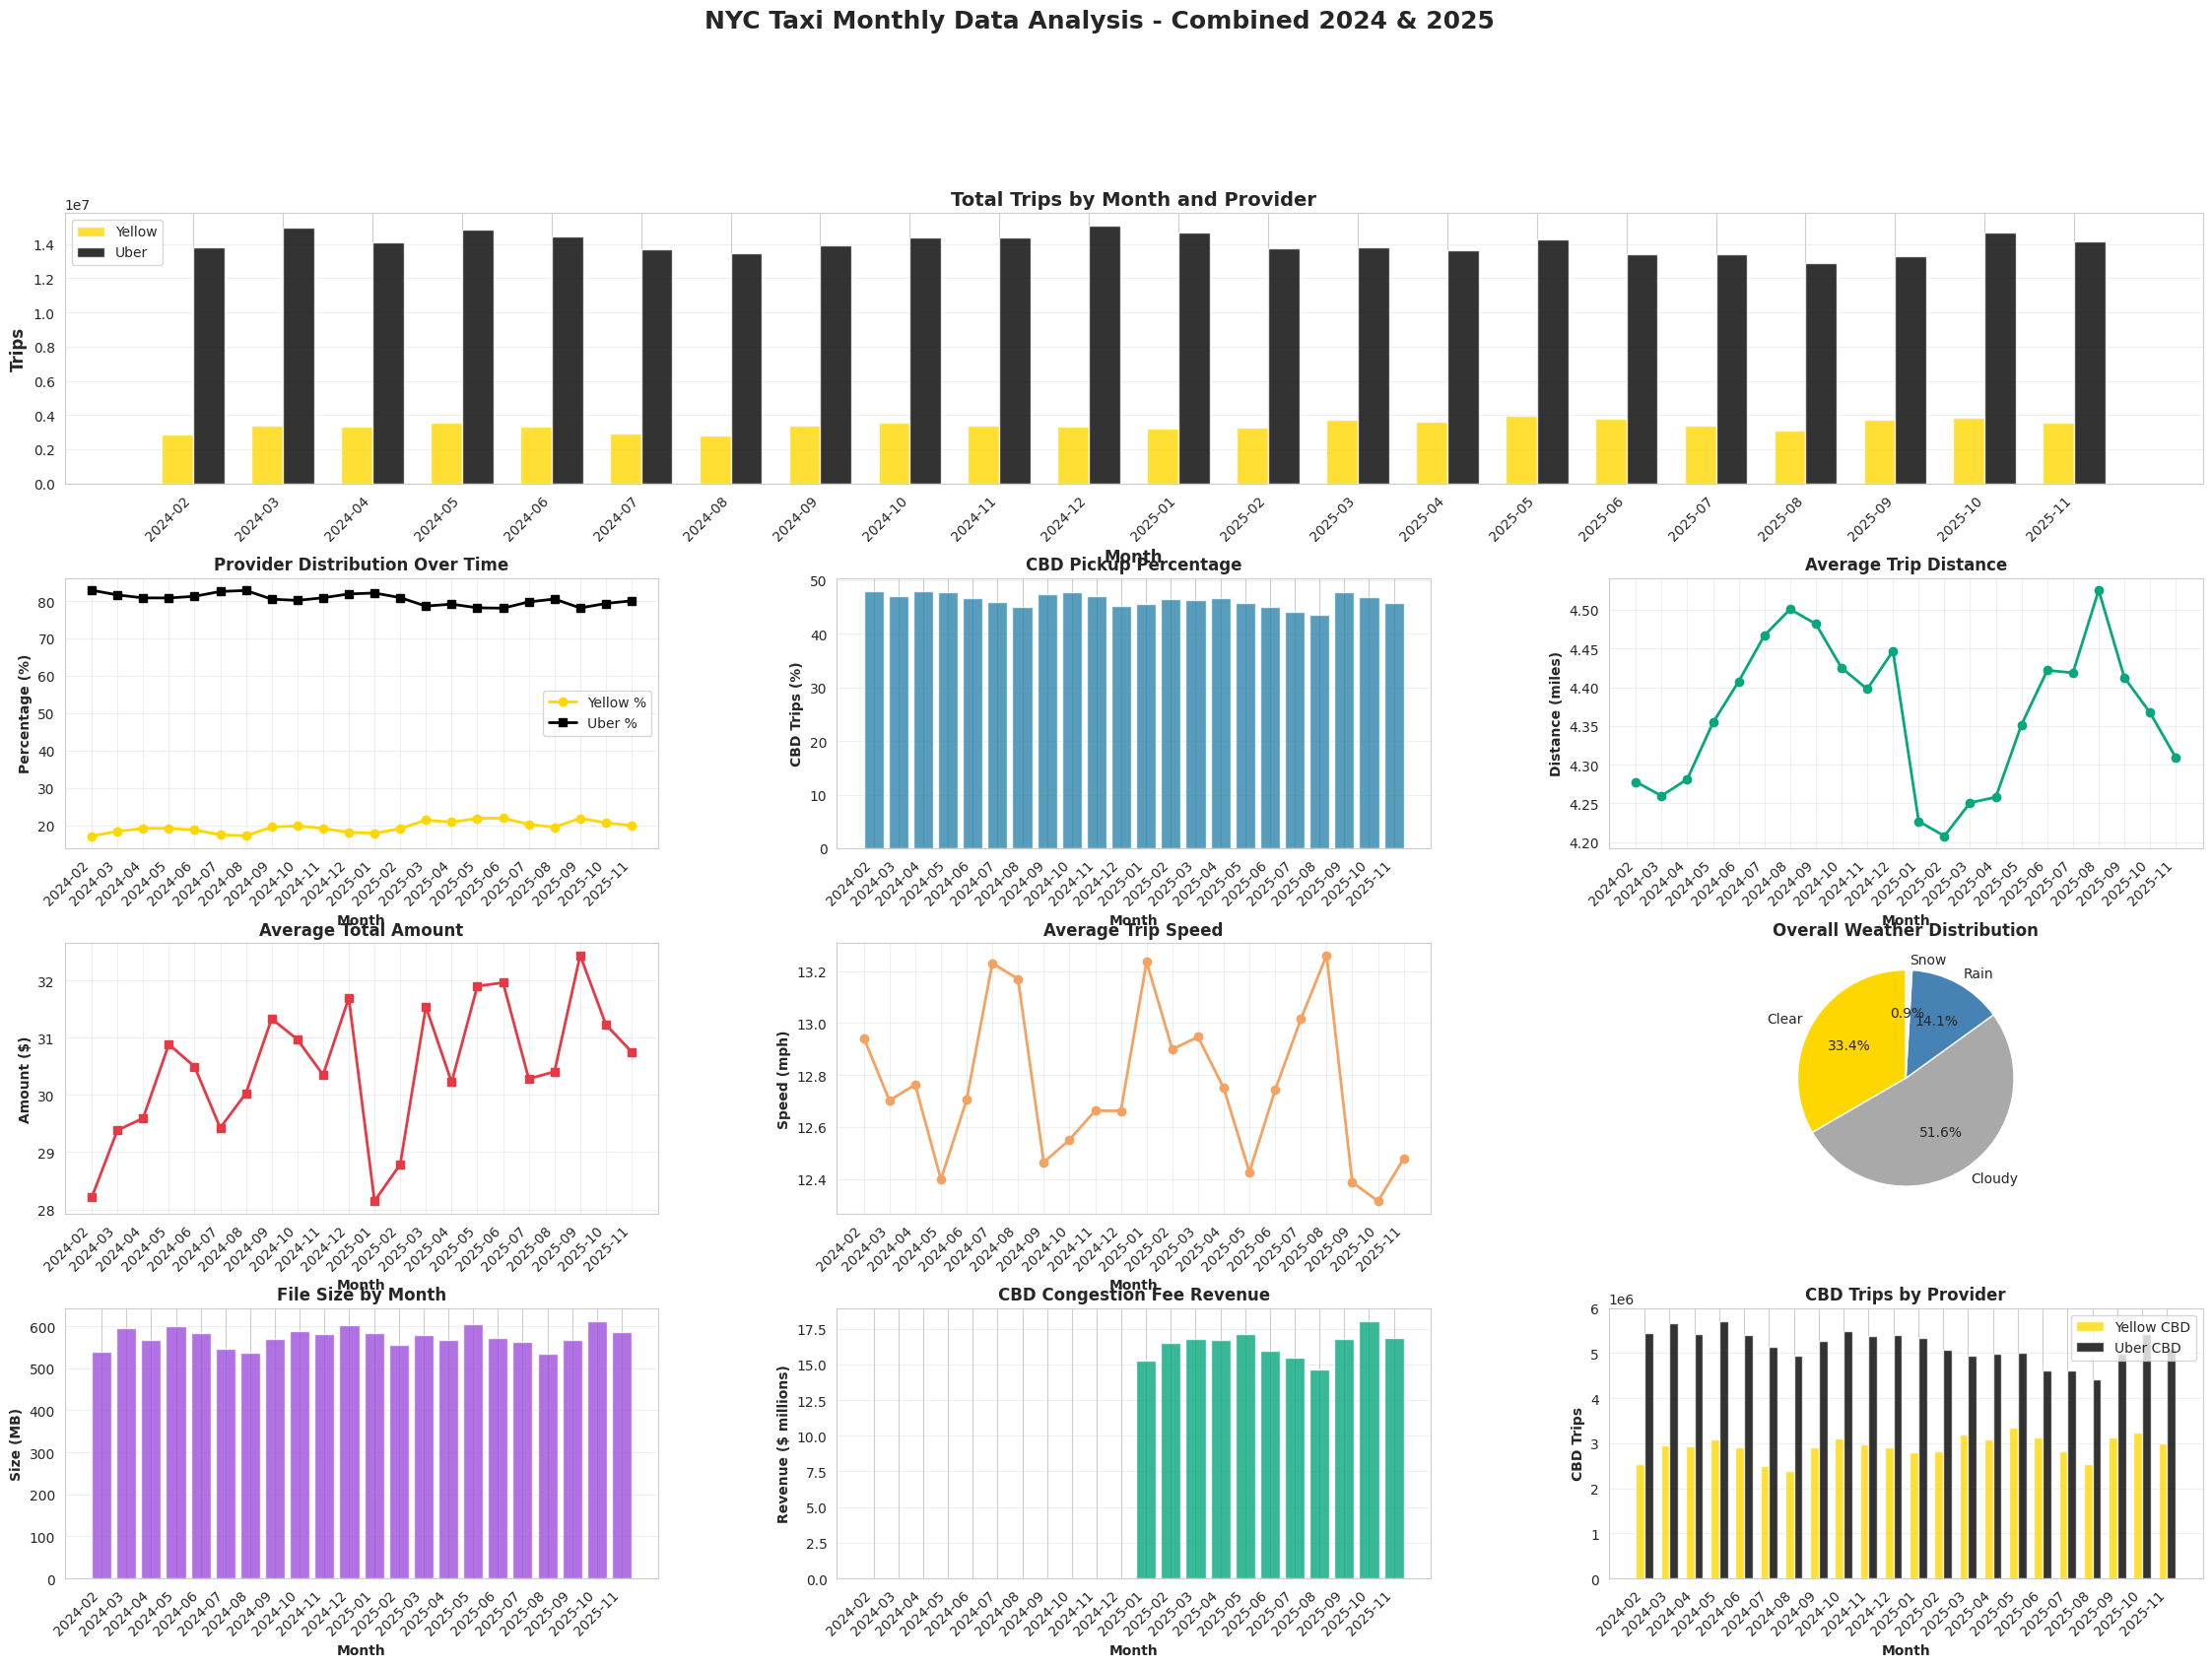


GENERATING TEXT REPORT

✓ Report saved: monthly_statistics_report.txt

STATISTICS GENERATION COMPLETE

Generated files:
  1. monthly_statistics.csv - Detailed statistics (CSV)
  2. monthly_statistics_dashboard.png - Visual dashboard (PNG)
  3. monthly_statistics_report.txt - Text report (TXT)

All files saved in: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/monthly_stats

Key insights:
  ✓ Total trips: 384,075,059
  ✓ Date range: 2024-02 to 2025-11
  ✓ Provider split: Yellow 19.5% | Uber 80.5%
  ✓ CBD trips: 46.4%
  ✓ Total size: 12.34 GB



In [18]:
#!/usr/bin/env python3
"""
Generate comprehensive statistics and visualizations for optimized monthly files.

Analyzes each file and creates:
  - Summary statistics table (CSV)
  - Visualization dashboard (PNG)
  - Detailed text report

Author: Gus
Date: February 2026
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm import tqdm

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)


def analyze_monthly_file(file_path: Path) -> dict:
    """
    Analyze a single monthly file.
    
    Returns dictionary with comprehensive statistics
    """
    df = pd.read_parquet(file_path)
    
    # Extract year-month from filename
    file_stem = file_path.stem  # combined_tripdata_2024-05
    year_month = file_stem.split('_')[-1]  # 2024-05
    
    stats = {
        'year_month': year_month,
        'file_name': file_path.name,
        'total_rows': len(df),
        'total_cols': len(df.columns),
        'file_size_mb': file_path.stat().st_size / (1024**2),
        
        # Provider distribution
        'yellow_trips': (df['provider'] == 1).sum(),
        'uber_trips': (df['provider'] == 2).sum(),
        'yellow_pct': (df['provider'] == 1).sum() / len(df) * 100,
        'uber_pct': (df['provider'] == 2).sum() / len(df) * 100,
        
        # CBD statistics
        'cbd_trips': (df['in_cbd_zone'] == 1).sum(),
        'non_cbd_trips': (df['in_cbd_zone'] == 0).sum(),
        'cbd_pct': (df['in_cbd_zone'] == 1).sum() / len(df) * 100,
        
        # Yellow CBD breakdown
        'yellow_cbd': ((df['provider'] == 1) & (df['in_cbd_zone'] == 1)).sum(),
        'uber_cbd': ((df['provider'] == 2) & (df['in_cbd_zone'] == 1)).sum(),
        
        # Weather statistics — derived from weather_type string column
        'weather_clear': (df['weather_type'] == 'clear').sum() if 'weather_type' in df.columns else 0,
        'weather_cloudy': (df['weather_type'] == 'cloudy').sum() if 'weather_type' in df.columns else 0,
        'weather_rain': (df['weather_type'] == 'rain').sum() if 'weather_type' in df.columns else 0,
        'weather_snow': (df['weather_type'] == 'snow').sum() if 'weather_type' in df.columns else 0,
        
        # Trip metrics
        'avg_distance': df['trip_distance'].mean(),
        'avg_time_min': df['trip_time'].mean() / 60,
        'avg_amount': df['total_amount'].mean(),
        'avg_speed': df['speed_mph'].mean(),
        'avg_cost_per_mile': df['cost_per_mile'].mean(),
        
        # CBD congestion fee
        'avg_cbd_fee': df['cbd_congestion_fee'].mean(),
        'total_cbd_revenue': df['cbd_congestion_fee'].sum(),
        
        # Data quality
        'null_count': df.isnull().sum().sum(),
        'duplicates': df.duplicated().sum(),
    }
    
    return stats


def main():
    """Generate statistics and visualizations for all monthly files."""
    
    print("="*80)
    print("MONTHLY FILES STATISTICS & VISUALIZATION")
    print("="*80)
    print()
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    input_dir = base_dir / "combined_monthly"
    output_dir = base_dir / "monthly_stats"
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all monthly files
    monthly_files = sorted(input_dir.glob("combined_tripdata_*.parquet"))
    
    if not monthly_files:
        print(f"ERROR: No files found in {input_dir}")
        return
    
    print(f"Input directory:  {input_dir}")
    print(f"Output directory: {output_dir}")
    print(f"Files to analyze: {len(monthly_files)}")
    print()
    
    # Analyze each file
    print("Analyzing monthly files...")
    all_stats = []
    
    with tqdm(total=len(monthly_files), desc="Processing", unit="file") as pbar:
        for file_path in monthly_files:
            stats = analyze_monthly_file(file_path)
            all_stats.append(stats)
            pbar.set_postfix({'month': stats['year_month']})
            pbar.update(1)
    
    print(f"✓ Analyzed {len(all_stats)} files")
    print()
    
    # Create DataFrame for easy analysis
    df_stats = pd.DataFrame(all_stats)
    
    # Sort by year_month
    df_stats = df_stats.sort_values('year_month')
    
    # === Generate Summary Table ===
    print("="*80)
    print("SUMMARY STATISTICS TABLE")
    print("="*80)
    print()
    
    summary_cols = [
        'year_month', 'total_rows', 'file_size_mb',
        'yellow_pct', 'uber_pct', 'cbd_pct',
        'avg_distance', 'avg_time_min', 'avg_amount'
    ]
    
    print(df_stats[summary_cols].to_string(index=False))
    print()
    
    # Save detailed CSV
    csv_file = output_dir / "monthly_statistics.csv"
    df_stats.to_csv(csv_file, index=False)
    print(f"✓ Detailed statistics saved: {csv_file.name}")
    print()
    
    # === Generate Visualizations ===
    print("="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    print()
    
    fig = plt.figure(figsize=(28, 18))
    gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)
    
    # 1. Total Trips by Month
    ax1 = fig.add_subplot(gs[0, :])
    x = range(len(df_stats))
    width = 0.35
    ax1.bar([i - width/2 for i in x], df_stats['yellow_trips'], width, 
            label='Yellow', color='#FFD700', alpha=0.8)
    ax1.bar([i + width/2 for i in x], df_stats['uber_trips'], width,
            label='Uber', color='#000000', alpha=0.8)
    ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Trips', fontsize=12, fontweight='bold')
    ax1.set_title('Total Trips by Month and Provider', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Provider Distribution %
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(df_stats['year_month'], df_stats['yellow_pct'], 
             marker='o', linewidth=2, label='Yellow %', color='#FFD700')
    ax2.plot(df_stats['year_month'], df_stats['uber_pct'],
             marker='s', linewidth=2, label='Uber %', color='#000000')
    ax2.set_xlabel('Month', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Percentage (%)', fontsize=10, fontweight='bold')
    ax2.set_title('Provider Distribution Over Time', fontsize=12, fontweight='bold')
    ax2.set_xticks(range(len(df_stats)))
    ax2.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 3. CBD Trips %
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.bar(df_stats['year_month'], df_stats['cbd_pct'], 
            color='#2E86AB', alpha=0.8)
    ax3.set_xlabel('Month', fontsize=10, fontweight='bold')
    ax3.set_ylabel('CBD Trips (%)', fontsize=10, fontweight='bold')
    ax3.set_title('CBD Pickup Percentage', fontsize=12, fontweight='bold')
    ax3.set_xticks(range(len(df_stats)))
    ax3.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Average Trip Distance
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.plot(df_stats['year_month'], df_stats['avg_distance'],
             marker='o', linewidth=2, color='#06A77D')
    ax4.set_xlabel('Month', fontsize=10, fontweight='bold')
    ax4.set_ylabel('Distance (miles)', fontsize=10, fontweight='bold')
    ax4.set_title('Average Trip Distance', fontsize=12, fontweight='bold')
    ax4.set_xticks(range(len(df_stats)))
    ax4.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax4.grid(alpha=0.3)
    
    # 5. Average Fare
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.plot(df_stats['year_month'], df_stats['avg_amount'],
             marker='s', linewidth=2, color='#E63946')
    ax5.set_xlabel('Month', fontsize=10, fontweight='bold')
    ax5.set_ylabel('Amount ($)', fontsize=10, fontweight='bold')
    ax5.set_title('Average Total Amount', fontsize=12, fontweight='bold')
    ax5.set_xticks(range(len(df_stats)))
    ax5.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax5.grid(alpha=0.3)
    
    # 6. Average Speed
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.plot(df_stats['year_month'], df_stats['avg_speed'],
             marker='o', linewidth=2, color='#F4A261')
    ax6.set_xlabel('Month', fontsize=10, fontweight='bold')
    ax6.set_ylabel('Speed (mph)', fontsize=10, fontweight='bold')
    ax6.set_title('Average Trip Speed', fontsize=12, fontweight='bold')
    ax6.set_xticks(range(len(df_stats)))
    ax6.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax6.grid(alpha=0.3)
    
    # 7. Weather Distribution
    ax7 = fig.add_subplot(gs[2, 2])
    weather_data = df_stats[['weather_clear', 'weather_cloudy', 'weather_rain', 'weather_snow']].sum()
    colors = ['#FFD700', '#A9A9A9', '#4682B4', '#F0F8FF']
    ax7.pie(weather_data, labels=['Clear', 'Cloudy', 'Rain', 'Snow'],
            autopct='%1.1f%%', colors=colors, startangle=90)
    ax7.set_title('Overall Weather Distribution', fontsize=12, fontweight='bold')
    
    # 8. File Size by Month
    ax8 = fig.add_subplot(gs[3, 0])
    ax8.bar(df_stats['year_month'], df_stats['file_size_mb'],
            color='#9D4EDD', alpha=0.8)
    ax8.set_xlabel('Month', fontsize=10, fontweight='bold')
    ax8.set_ylabel('Size (MB)', fontsize=10, fontweight='bold')
    ax8.set_title('File Size by Month', fontsize=12, fontweight='bold')
    ax8.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax8.grid(axis='y', alpha=0.3)
    
    # 9. CBD Revenue
    ax9 = fig.add_subplot(gs[3, 1])
    ax9.bar(df_stats['year_month'], df_stats['total_cbd_revenue'] / 1e6,
            color='#06A77D', alpha=0.8)
    ax9.set_xlabel('Month', fontsize=10, fontweight='bold')
    ax9.set_ylabel('Revenue ($ millions)', fontsize=10, fontweight='bold')
    ax9.set_title('CBD Congestion Fee Revenue', fontsize=12, fontweight='bold')
    ax9.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax9.grid(axis='y', alpha=0.3)
    
    # 10. CBD Trips by Provider
    ax10 = fig.add_subplot(gs[3, 2])
    width = 0.35
    x = range(len(df_stats))
    ax10.bar([i - width/2 for i in x], df_stats['yellow_cbd'], width,
             label='Yellow CBD', color='#FFD700', alpha=0.8)
    ax10.bar([i + width/2 for i in x], df_stats['uber_cbd'], width,
             label='Uber CBD', color='#000000', alpha=0.8)
    ax10.set_xlabel('Month', fontsize=10, fontweight='bold')
    ax10.set_ylabel('CBD Trips', fontsize=10, fontweight='bold')
    ax10.set_title('CBD Trips by Provider', fontsize=12, fontweight='bold')
    ax10.set_xticks(x)
    ax10.set_xticklabels(df_stats['year_month'], rotation=45, ha='right')
    ax10.legend()
    ax10.grid(axis='y', alpha=0.3)
    
    # Overall title
    fig.suptitle('NYC Taxi Monthly Data Analysis - Combined 2024 & 2025',
                 fontsize=18, fontweight='bold', y=0.995)
    
    # Save visualization and display inline in Jupyter
    viz_file = output_dir / "monthly_statistics_dashboard.png"
    plt.savefig(viz_file, dpi=300, bbox_inches='tight')
    print(f"✓ Visualization saved: {viz_file.name}")
    plt.show()  # Display inline as cell output in Jupyter
    
    # === Generate Text Report ===
    print()
    print("="*80)
    print("GENERATING TEXT REPORT")
    print("="*80)
    print()
    
    report_file = output_dir / "monthly_statistics_report.txt"
    
    with open(report_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("MONTHLY FILES STATISTICS REPORT\n")
        f.write("="*80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Files analyzed: {len(all_stats)}\n")
        f.write(f"Data range: {df_stats['year_month'].min()} to {df_stats['year_month'].max()}\n\n")
        
        f.write("OVERALL SUMMARY:\n")
        f.write("-"*80 + "\n")
        f.write(f"Total trips: {df_stats['total_rows'].sum():,}\n")
        f.write(f"Total file size: {df_stats['file_size_mb'].sum():.1f} MB ({df_stats['file_size_mb'].sum()/1024:.2f} GB)\n")
        f.write(f"Average file size: {df_stats['file_size_mb'].mean():.1f} MB\n\n")
        
        f.write("PROVIDER DISTRIBUTION:\n")
        f.write("-"*80 + "\n")
        total_yellow = df_stats['yellow_trips'].sum()
        total_uber = df_stats['uber_trips'].sum()
        total_all = total_yellow + total_uber
        f.write(f"Yellow trips: {total_yellow:,} ({total_yellow/total_all*100:.1f}%)\n")
        f.write(f"Uber trips: {total_uber:,} ({total_uber/total_all*100:.1f}%)\n\n")
        
        f.write("CBD STATISTICS:\n")
        f.write("-"*80 + "\n")
        total_cbd = df_stats['cbd_trips'].sum()
        f.write(f"Total CBD trips: {total_cbd:,} ({total_cbd/total_all*100:.1f}%)\n")
        f.write(f"Average CBD %: {df_stats['cbd_pct'].mean():.1f}%\n\n")
        
        f.write("TRIP METRICS (AVERAGE):\n")
        f.write("-"*80 + "\n")
        f.write(f"Distance: {df_stats['avg_distance'].mean():.2f} miles\n")
        f.write(f"Time: {df_stats['avg_time_min'].mean():.1f} minutes\n")
        f.write(f"Amount: ${df_stats['avg_amount'].mean():.2f}\n")
        f.write(f"Speed: {df_stats['avg_speed'].mean():.1f} mph\n")
        f.write(f"Cost per mile: ${df_stats['avg_cost_per_mile'].mean():.2f}\n\n")
        
        f.write("WEATHER DISTRIBUTION:\n")
        f.write("-"*80 + "\n")
        total_weather = df_stats[['weather_clear', 'weather_cloudy', 'weather_rain', 'weather_snow']].sum().sum()
        f.write(f"Clear: {df_stats['weather_clear'].sum():,} ({df_stats['weather_clear'].sum()/total_weather*100:.1f}%)\n")
        f.write(f"Cloudy: {df_stats['weather_cloudy'].sum():,} ({df_stats['weather_cloudy'].sum()/total_weather*100:.1f}%)\n")
        f.write(f"Rain: {df_stats['weather_rain'].sum():,} ({df_stats['weather_rain'].sum()/total_weather*100:.1f}%)\n")
        f.write(f"Snow: {df_stats['weather_snow'].sum():,} ({df_stats['weather_snow'].sum()/total_weather*100:.1f}%)\n\n")
        
        f.write("CBD CONGESTION FEE REVENUE:\n")
        f.write("-"*80 + "\n")
        total_revenue = df_stats['total_cbd_revenue'].sum()
        f.write(f"Total revenue: ${total_revenue:,.2f}\n")
        f.write(f"Average per month: ${df_stats['total_cbd_revenue'].mean():,.2f}\n\n")
        
        f.write("MONTH-BY-MONTH BREAKDOWN:\n")
        f.write("-"*80 + "\n")
        for _, row in df_stats.iterrows():
            f.write(f"\n{row['year_month']}:\n")
            f.write(f"  Trips: {row['total_rows']:,}\n")
            f.write(f"  Yellow: {row['yellow_pct']:.1f}% | Uber: {row['uber_pct']:.1f}%\n")
            f.write(f"  CBD: {row['cbd_pct']:.1f}%\n")
            f.write(f"  Avg distance: {row['avg_distance']:.2f} mi\n")
            f.write(f"  Avg amount: ${row['avg_amount']:.2f}\n")
            f.write(f"  File size: {row['file_size_mb']:.1f} MB\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("END OF REPORT\n")
        f.write("="*80 + "\n")
    
    print(f"✓ Report saved: {report_file.name}")
    print()
    
    # === Final Summary ===
    print("="*80)
    print("STATISTICS GENERATION COMPLETE")
    print("="*80)
    print()
    print("Generated files:")
    print(f"  1. {csv_file.name} - Detailed statistics (CSV)")
    print(f"  2. {viz_file.name} - Visual dashboard (PNG)")
    print(f"  3. {report_file.name} - Text report (TXT)")
    print()
    print(f"All files saved in: {output_dir}")
    print()
    print("Key insights:")
    print(f"  ✓ Total trips: {df_stats['total_rows'].sum():,}")
    print(f"  ✓ Date range: {df_stats['year_month'].min()} to {df_stats['year_month'].max()}")
    print(f"  ✓ Provider split: Yellow {total_yellow/total_all*100:.1f}% | Uber {total_uber/total_all*100:.1f}%")
    print(f"  ✓ CBD trips: {total_cbd/total_all*100:.1f}%")
    print(f"  ✓ Total size: {df_stats['file_size_mb'].sum()/1024:.2f} GB")
    print()


if __name__ == "__main__":
    main()


### 1.5 Final dataset

Due to the massive size of the dataset, merging all the data in just one dataset will make it extreamly difficult to process, so we perform an stratified sampling mont by month keeping the proportion in order to generate the final file

In [19]:
#!/usr/bin/env python3
"""
Strategy:
  - TRAIN: All months EXCEPT Nov-2025, with 10% sampling
  - TEST: Nov-2025 with 10% sampling (to keep dataset manageable)
  - Output: Single file with 'dataset_split' column

This version includes both 2024 and 2025 data for before/after analysis.

Date: February 2026
"""

from pathlib import Path
import pandas as pd
from datetime import datetime
import gc
import re


def process_train_month(file_path: Path, sample_rate: float, random_seed: int) -> pd.DataFrame:
    """
    Process a training month with sampling.
    
    Args:
        file_path: Path to monthly file
        sample_rate: Sampling rate (0.10 = 10%)
        random_seed: Random seed for reproducibility
        
    Returns:
        Sampled DataFrame with 'dataset_split' column
    """
    print(f"  Processing TRAIN: {file_path.name}")
    
    # Load month
    df = pd.read_parquet(file_path)
    initial_rows = len(df)
    print(f"    Total rows: {initial_rows:,}")
    
    # Separate by provider for stratified sampling
    df_yellow = df[df['provider'] == 1]
    df_uber = df[df['provider'] == 2]
    
    yellow_initial = len(df_yellow)
    uber_initial = len(df_uber)
    
    # Sample each provider
    sample_yellow = df_yellow.sample(frac=sample_rate, random_state=random_seed)
    sample_uber = df_uber.sample(frac=sample_rate, random_state=random_seed)
    
    # Combine samples
    df_sample = pd.concat([sample_yellow, sample_uber], ignore_index=True)
    
    # Add dataset split column
    df_sample['dataset_split'] = 'train'
    
    print(f"    Yellow: {yellow_initial:,} → {len(sample_yellow):,} ({sample_rate*100:.0f}%)")
    print(f"    Uber:   {uber_initial:,} → {len(sample_uber):,} ({sample_rate*100:.0f}%)")
    print(f"    Sample total: {len(df_sample):,}")
    
    # Clear memory
    del df, df_yellow, df_uber, sample_yellow, sample_uber
    gc.collect()
    
    return df_sample


def process_test_month(file_path: Path, sample_rate: float, random_seed: int) -> pd.DataFrame:
    """
    Process test month with sampling.
    
    Args:
        file_path: Path to monthly file
        sample_rate: Sampling rate for test set
        random_seed: Random seed for reproducibility
        
    Returns:
        Sampled DataFrame with 'dataset_split' column
    """
    print(f"  Processing TEST: {file_path.name}")
    
    # Load month
    df = pd.read_parquet(file_path)
    initial_rows = len(df)
    print(f"    Total rows: {initial_rows:,}")
    
    # Separate by provider for stratified sampling
    df_yellow = df[df['provider'] == 1]
    df_uber = df[df['provider'] == 2]
    
    yellow_initial = len(df_yellow)
    uber_initial = len(df_uber)
    
    # Sample each provider
    sample_yellow = df_yellow.sample(frac=sample_rate, random_state=random_seed)
    sample_uber = df_uber.sample(frac=sample_rate, random_state=random_seed)
    
    # Combine samples
    df_sample = pd.concat([sample_yellow, sample_uber], ignore_index=True)
    
    # Add dataset split column
    df_sample['dataset_split'] = 'test'
    
    print(f"    Yellow: {yellow_initial:,} → {len(sample_yellow):,} ({sample_rate*100:.0f}%)")
    print(f"    Uber:   {uber_initial:,} → {len(sample_uber):,} ({sample_rate*100:.0f}%)")
    print(f"    Sample total: {len(df_sample):,}")
    
    # Clear memory
    del df, df_yellow, df_uber, sample_yellow, sample_uber
    gc.collect()
    
    return df_sample


def main():
    """Create stratified sample for ML modeling."""
    
    print("="*80)
    print("STRATIFIED SAMPLING - VERSION 1: ALL DATA (2024+2025)")
    print("="*80)
    print()
    
    # Configuration
    TEST_MONTH = '2025-11'  # November 2025
    TRAIN_SAMPLE_RATE = 0.10  # 10%
    TEST_SAMPLE_RATE = 0.10   # 10% (to keep manageable)
    RANDOM_SEED = 42
    
    print("CONFIGURATION:")
    print("-"*80)
    print(f"Test month: {TEST_MONTH}")
    print(f"Train months: ALL except {TEST_MONTH}")
    print(f"Train sample rate: {TRAIN_SAMPLE_RATE*100:.0f}%")
    print(f"Test sample rate: {TEST_SAMPLE_RATE*100:.0f}%")
    print(f"Random seed: {RANDOM_SEED}")
    print()
    
    # Paths - works both as a .py script and in a Jupyter notebook
    # base_dir resolves to ML1-FinalProject in both contexts
    # Note: 4 parents needed (scripts/08_dataset_generation_choices/<file>)
    try:
        base_dir = Path(__file__).resolve().parent.parent.parent.parent / "Final_project_VF" / "ML1-FinalProject"
    except NameError:
        base_dir = Path.cwd()  # when run from notebook, cwd IS ML1-FinalProject
    input_dir = base_dir / "combined_monthly"
    output_dir = base_dir / "final_dataset"
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Input directory:  {input_dir}")
    print(f"Output directory: {output_dir}")
    print()
    
    # Get all files
    all_files = sorted(input_dir.glob("combined_tripdata_*.parquet"))
    
    if not all_files:
        print(f"ERROR: No files found in {input_dir}")
        return
    
    # Separate train and test files
    train_files = []
    test_files = []
    
    for f in all_files:
        # Extract YYYY-MM from filename
        match = re.search(r'(\d{4}-\d{2})', f.name)
        if match:
            year_month = match.group(1)
            if year_month == TEST_MONTH:
                test_files.append(f)
            else:
                train_files.append(f)
    
    print(f"Files found:")
    print(f"  Train files: {len(train_files)}")
    print(f"  Test files: {len(test_files)}")
    print()
    
    # === PHASE 1: Process training months ===
    print("="*80)
    print(f"PHASE 1: PROCESSING TRAINING MONTHS (All except {TEST_MONTH})")
    print("="*80)
    print()
    
    train_samples = []
    train_stats = []
    
    for month_file in train_files:
        # Extract year-month
        match = re.search(r'(\d{4}-\d{2})', month_file.name)
        year_month = match.group(1)
        
        # Process month with sampling
        df_sample = process_train_month(month_file, TRAIN_SAMPLE_RATE, RANDOM_SEED)
        
        # Collect stats
        stats = {
            'month': year_month,
            'rows_sampled': len(df_sample),
            'yellow_rows': (df_sample['provider'] == 1).sum(),
            'uber_rows': (df_sample['provider'] == 2).sum()
        }
        train_stats.append(stats)
        
        # Append to list
        train_samples.append(df_sample)
        
        # Clear memory
        del df_sample
        gc.collect()
        
        print()
    
    print(f"✓ Processed {len(train_samples)} training months")
    print()
    
    # === PHASE 2: Process test month ===
    print("="*80)
    print(f"PHASE 2: PROCESSING TEST MONTH ({TEST_MONTH})")
    print("="*80)
    print()
    
    test_samples = []
    test_stats = []
    
    for month_file in test_files:
        # Extract year-month
        match = re.search(r'(\d{4}-\d{2})', month_file.name)
        year_month = match.group(1)
        
        # Process month with sampling
        df_test = process_test_month(month_file, TEST_SAMPLE_RATE, RANDOM_SEED)
        
        # Collect stats
        stats = {
            'month': year_month,
            'rows_sampled': len(df_test),
            'yellow_rows': (df_test['provider'] == 1).sum(),
            'uber_rows': (df_test['provider'] == 2).sum()
        }
        test_stats.append(stats)
        
        # Append to list
        test_samples.append(df_test)
        
        # Clear memory
        del df_test
        gc.collect()
        
        print()
    
    print(f"✓ Processed {len(test_samples)} test month")
    print()
    
    # === PHASE 3: Combine all samples ===
    print("="*80)
    print("PHASE 3: COMBINING TRAIN + TEST")
    print("="*80)
    print()
    
    print("Concatenating training samples...")
    df_train = pd.concat(train_samples, ignore_index=True)
    print(f"  ✓ Train dataset: {len(df_train):,} rows")
    
    # Clear memory
    del train_samples
    gc.collect()
    
    print("Concatenating test samples...")
    df_test = pd.concat(test_samples, ignore_index=True)
    print(f"  ✓ Test dataset: {len(df_test):,} rows")
    
    # Clear memory
    del test_samples
    gc.collect()
    
    print("Combining train + test...")
    df_final = pd.concat([df_train, df_test], ignore_index=True)
    print(f"  ✓ Combined dataset: {len(df_final):,} rows")
    print()
    
    # Clear memory
    del df_train, df_test
    gc.collect()
    
    # === PHASE 4: Data cleaning ===
    print("="*80)
    print("PHASE 4: DATA VERIFICATION")
    print("="*80)
    print()
    
    final_rows = len(df_final)
    final_cols = len(df_final.columns)
    
    # Check duplicates
    print("Checking for duplicates...")
    duplicates = df_final.duplicated().sum()
    if duplicates > 0:
        dup_pct = (duplicates / len(df_final)) * 100
        print(f"  Found {duplicates:,} duplicates ({dup_pct:.6f}%)")
        print(f"  → Keeping duplicates (statistically insignificant)")
    else:
        print(f"✓ No duplicates found")
    
    print(f"✓ Final dataset: {final_rows:,} rows × {final_cols} columns")
    print()
    
    gc.collect()
    
    # === PHASE 5: Generate statistics ===
    print("="*80)
    print("PHASE 5: DATASET STATISTICS")
    print("="*80)
    print()
    
    # Overall stats
    total_train = (df_final['dataset_split'] == 'train').sum()
    total_test = (df_final['dataset_split'] == 'test').sum()
    
    print("DATASET SPLIT:")
    print(f"  Train: {total_train:,} ({total_train/len(df_final)*100:.1f}%)")
    print(f"  Test:  {total_test:,} ({total_test/len(df_final)*100:.1f}%)")
    print()
    
    # Provider distribution
    train_yellow = ((df_final['dataset_split'] == 'train') & (df_final['provider'] == 1)).sum()
    train_uber = ((df_final['dataset_split'] == 'train') & (df_final['provider'] == 2)).sum()
    test_yellow = ((df_final['dataset_split'] == 'test') & (df_final['provider'] == 1)).sum()
    test_uber = ((df_final['dataset_split'] == 'test') & (df_final['provider'] == 2)).sum()
    
    print("PROVIDER DISTRIBUTION:")
    print("  Train:")
    print(f"    Yellow: {train_yellow:,} ({train_yellow/total_train*100:.1f}%)")
    print(f"    Uber:   {train_uber:,} ({train_uber/total_train*100:.1f}%)")
    print("  Test:")
    print(f"    Yellow: {test_yellow:,} ({test_yellow/total_test*100:.1f}%)")
    print(f"    Uber:   {test_uber:,} ({test_uber/total_test*100:.1f}%)")
    print()
    
    # CBD statistics
    train_cbd = ((df_final['dataset_split'] == 'train') & (df_final['in_cbd_zone'] == 1)).sum()
    test_cbd = ((df_final['dataset_split'] == 'test') & (df_final['in_cbd_zone'] == 1)).sum()
    
    print("CBD STATISTICS:")
    print(f"  Train CBD trips: {train_cbd:,} ({train_cbd/total_train*100:.1f}%)")
    print(f"  Test CBD trips:  {test_cbd:,} ({test_cbd/total_test*100:.1f}%)")
    print()
    
    # === PHASE 6: Save dataset ===
    print("="*80)
    print("PHASE 6: SAVING DATASET")
    print("="*80)
    print()
    
    output_file = output_dir / "nyc_taxi_ml_dataset_2024_2025.parquet"
    
    print(f"Saving to: {output_file.name}")
    df_final.to_parquet(output_file, index=False, compression='snappy')
    
    file_size_mb = output_file.stat().st_size / (1024**2)
    print(f"✓ File saved: {file_size_mb:.1f} MB ({file_size_mb/1024:.2f} GB)")
    print()
    
    # === PHASE 7: Save log ===
    log_file = output_dir / "sampling_log_2024_2025.txt"
    
    with open(log_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("STRATIFIED SAMPLING LOG - ALL DATA (2024+2025)\n")
        f.write("="*80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Output file: {output_file}\n\n")
        
        f.write("SAMPLING CONFIGURATION:\n")
        f.write("-"*80 + "\n")
        f.write(f"Test month: {TEST_MONTH}\n")
        f.write(f"Train months: ALL except {TEST_MONTH}\n")
        f.write(f"Train sample rate: {TRAIN_SAMPLE_RATE*100:.0f}%\n")
        f.write(f"Test sample rate: {TEST_SAMPLE_RATE*100:.0f}%\n")
        f.write(f"Random seed: {RANDOM_SEED}\n\n")
        
        f.write("FINAL DATASET SUMMARY:\n")
        f.write("-"*80 + "\n")
        f.write(f"Total records: {len(df_final):,}\n")
        f.write(f"Total columns: {len(df_final.columns)}\n")
        f.write(f"File size: {file_size_mb:.1f} MB ({file_size_mb/1024:.2f} GB)\n\n")
        
        f.write("Dataset Split:\n")
        f.write(f"  Train: {total_train:,} ({total_train/len(df_final)*100:.1f}%)\n")
        f.write(f"  Test: {total_test:,} ({total_test/len(df_final)*100:.1f}%)\n\n")
        
        f.write("Provider Distribution:\n")
        f.write("  Train:\n")
        f.write(f"    Yellow: {train_yellow:,} ({train_yellow/total_train*100:.1f}%)\n")
        f.write(f"    Uber: {train_uber:,} ({train_uber/total_train*100:.1f}%)\n")
        f.write("  Test:\n")
        f.write(f"    Yellow: {test_yellow:,} ({test_yellow/total_test*100:.1f}%)\n")
        f.write(f"    Uber: {test_uber:,} ({test_uber/total_test*100:.1f}%)\n\n")
        
        f.write("CBD Statistics:\n")
        f.write(f"  Train CBD trips: {train_cbd:,} ({train_cbd/total_train*100:.1f}%)\n")
        f.write(f"  Test CBD trips: {test_cbd:,} ({test_cbd/total_test*100:.1f}%)\n\n")
        
        f.write("TRAINING MONTHS DETAIL:\n")
        f.write("-"*80 + "\n")
        for stat in sorted(train_stats, key=lambda x: x['month']):
            f.write(f"\nMonth {stat['month']}:\n")
            f.write(f"  Total sampled: {stat['rows_sampled']:,}\n")
            f.write(f"  Yellow: {stat['yellow_rows']:,} ({stat['yellow_rows']/stat['rows_sampled']*100:.1f}%)\n")
            f.write(f"  Uber: {stat['uber_rows']:,} ({stat['uber_rows']/stat['rows_sampled']*100:.1f}%)\n")
        
        f.write("\nTEST MONTH DETAIL:\n")
        f.write("-"*80 + "\n")
        for stat in test_stats:
            f.write(f"\nMonth {stat['month']}:\n")
            f.write(f"  Total sampled: {stat['rows_sampled']:,}\n")
            f.write(f"  Yellow: {stat['yellow_rows']:,} ({stat['yellow_rows']/stat['rows_sampled']*100:.1f}%)\n")
            f.write(f"  Uber: {stat['uber_rows']:,} ({stat['uber_rows']/stat['rows_sampled']*100:.1f}%)\n")
        
        f.write("\nCOLUMNS ({}):\n".format(len(df_final.columns)))
        f.write("-"*80 + "\n")
        for i, col in enumerate(df_final.columns, 1):
            f.write(f"  {i:2d}. {col}\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("END OF LOG\n")
        f.write("="*80 + "\n")
    
    print(f"✓ Log saved: {log_file.name}")
    print()
    
    # === SUMMARY ===
    print("="*80)
    print("SAMPLING COMPLETE - VERSION 1: ALL DATA (2024+2025)")
    print("="*80)
    print()
    print(f"✓ Dataset ready: {output_file.name}")
    print(f"✓ Total records: {len(df_final):,}")
    print(f"  - Train (21 months, 10% sample): {total_train:,}")
    print(f"  - Test ({TEST_MONTH}, 10% sample): {total_test:,}")
    print(f"✓ File size: {file_size_mb/1024:.2f} GB")
    print(f"✓ Columns: {len(df_final.columns)}")
    print()
    print("This dataset includes both 2024 and 2025 for before/after analysis!")
    print()


if __name__ == "__main__":
    main()


STRATIFIED SAMPLING - VERSION 1: ALL DATA (2024+2025)

CONFIGURATION:
--------------------------------------------------------------------------------
Test month: 2025-11
Train months: ALL except 2025-11
Train sample rate: 10%
Test sample rate: 10%
Random seed: 42

Input directory:  /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/combined_monthly
Output directory: /home/arcanegus/MSADS_/ML_31007/Final_project_VF/ML1-FinalProject/final_dataset

Files found:
  Train files: 21
  Test files: 1

PHASE 1: PROCESSING TRAINING MONTHS (All except 2025-11)

  Processing TRAIN: combined_tripdata_2024-02.parquet
    Total rows: 16,655,731
    Yellow: 2,846,791 → 284,679 (10%)
    Uber:   13,808,940 → 1,380,894 (10%)
    Sample total: 1,665,573

  Processing TRAIN: combined_tripdata_2024-03.parquet
    Total rows: 18,330,243
    Yellow: 3,364,447 → 336,445 (10%)
    Uber:   14,965,796 → 1,496,580 (10%)
    Sample total: 1,833,025

  Processing TRAIN: combined_tripdata_2024-04.parq

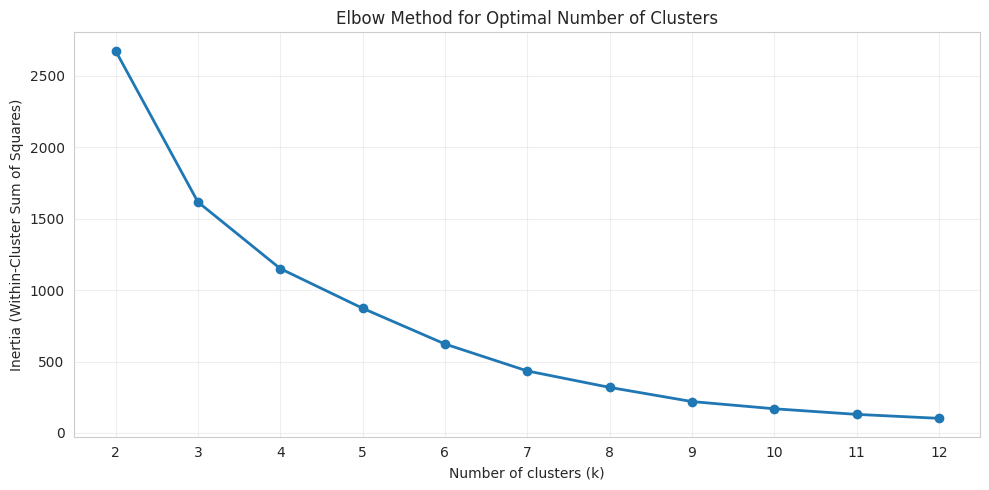

Rows loaded: 38,407,508
Pickup zones used for clustering: 261
Use the elbow point (where inertia reduction starts to flatten) as the initial k.


In [20]:
# Elbow plot to choose the number of clusters for pickup behavior segmentation
from final_dataset_analysis import load_dataset, build_pickup_location_monthly_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load and transform data using the same logic as the main analysis pipeline
df = load_dataset("final_dataset/nyc_taxi_ml_dataset_2024_2025.parquet")
monthly_matrix = build_pickup_location_monthly_matrix(df)

# Scale features before KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(monthly_matrix)

# Compute inertia for different k values
k_values = list(range(2, 13))
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_values, inertias, marker="o", linewidth=2)
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rows loaded: {len(df):,}")
print(f"Pickup zones used for clustering: {monthly_matrix.shape[0]:,}")
print("Use the elbow point (where inertia reduction starts to flatten) as the initial k.")

Loaded rows: 38,407,508
Unique pickup zones: 261
Years in data: [np.int32(2002), np.int32(2009), np.int32(2024), np.int32(2025)]
Clusters: 5


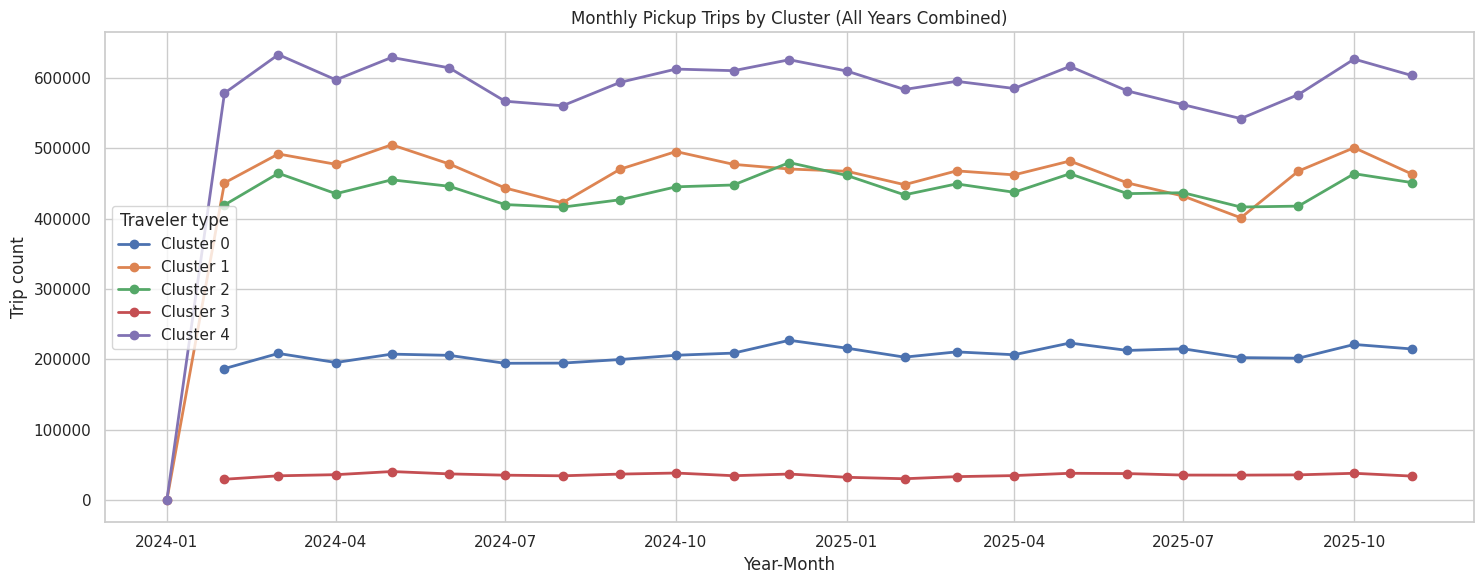

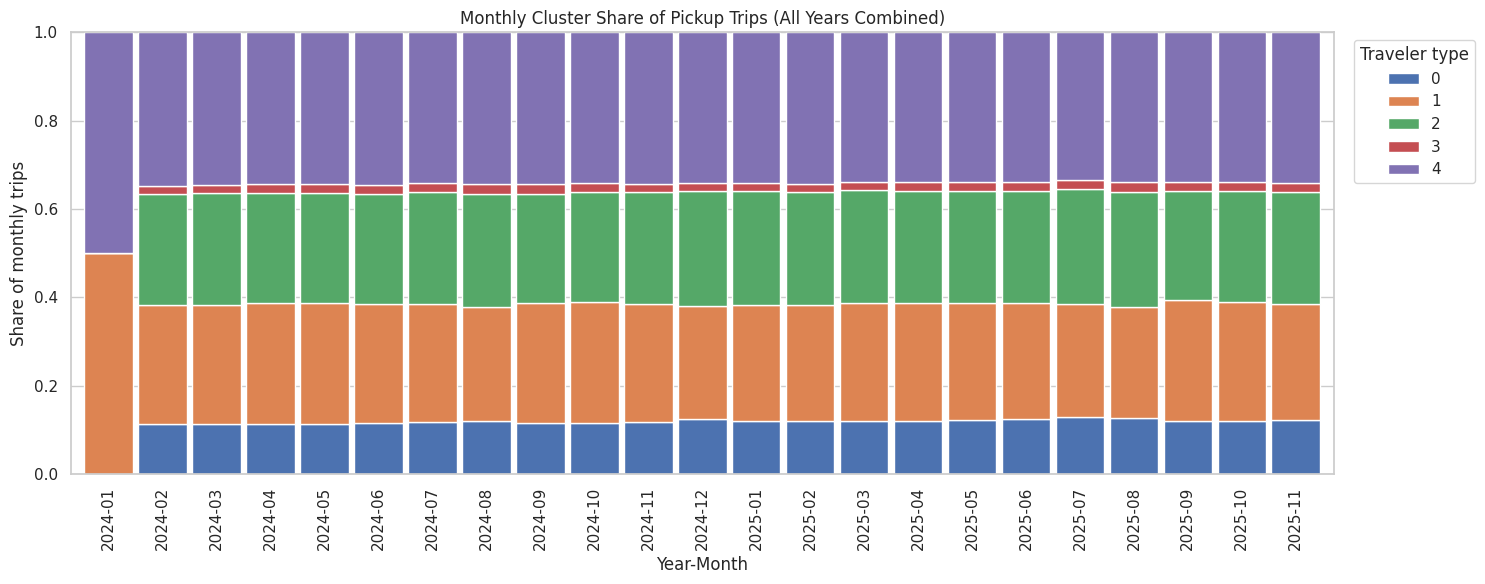

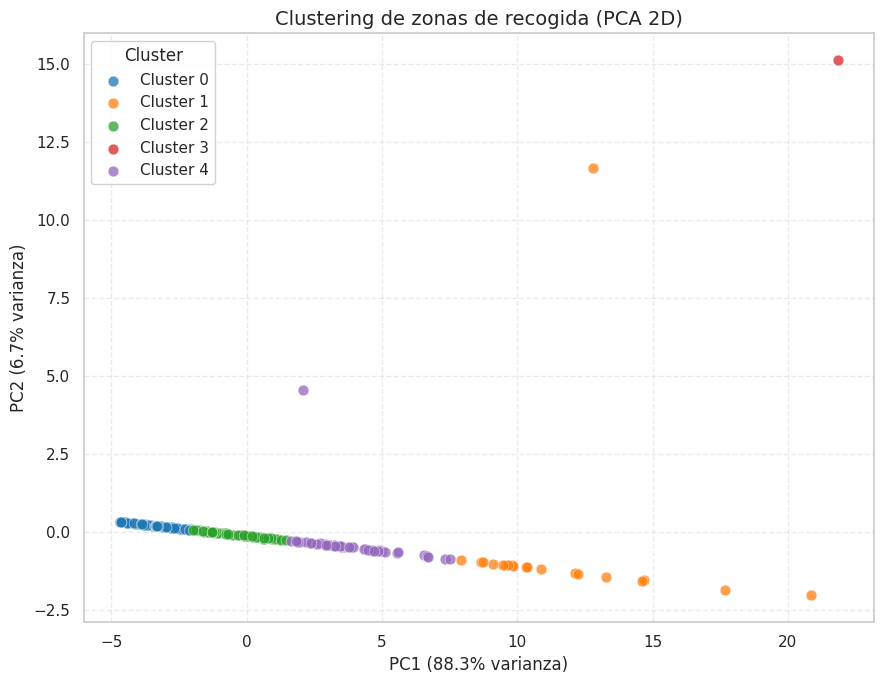

In [3]:
from final_dataset_analysis import run_pickup_clustering_analysis
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

results = run_pickup_clustering_analysis(
    dataset_path="final_dataset/nyc_taxi_ml_dataset_2024_2025.parquet",
    n_clusters=5,
    random_state=42,
)

# --- Scatter plot: zonas proyectadas en 2D por PCA, coloreadas por cluster ---
monthly_matrix = results["monthly_matrix"]
zone_clusters = results["zone_clusters"]

# Escalar y reducir a 2 componentes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(monthly_matrix)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

# Unir coordenadas PCA con etiquetas de cluster
import pandas as pd
plot_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "PULocationID": monthly_matrix.index,
}).merge(zone_clusters, on="PULocationID")

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10.colors

for cluster_id in sorted(plot_df["cluster"].unique()):
    mask = plot_df["cluster"] == cluster_id
    ax.scatter(
        plot_df.loc[mask, "PC1"],
        plot_df.loc[mask, "PC2"],
        c=[colors[cluster_id]],
        label=f"Cluster {cluster_id}",
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
        s=60,
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)", fontsize=12)
ax.set_title("Clustering de zonas de recogida (PCA 2D)", fontsize=14)
ax.legend(title="Cluster", framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("pickup_clustering_scatter.png", dpi=150)
plt.show()


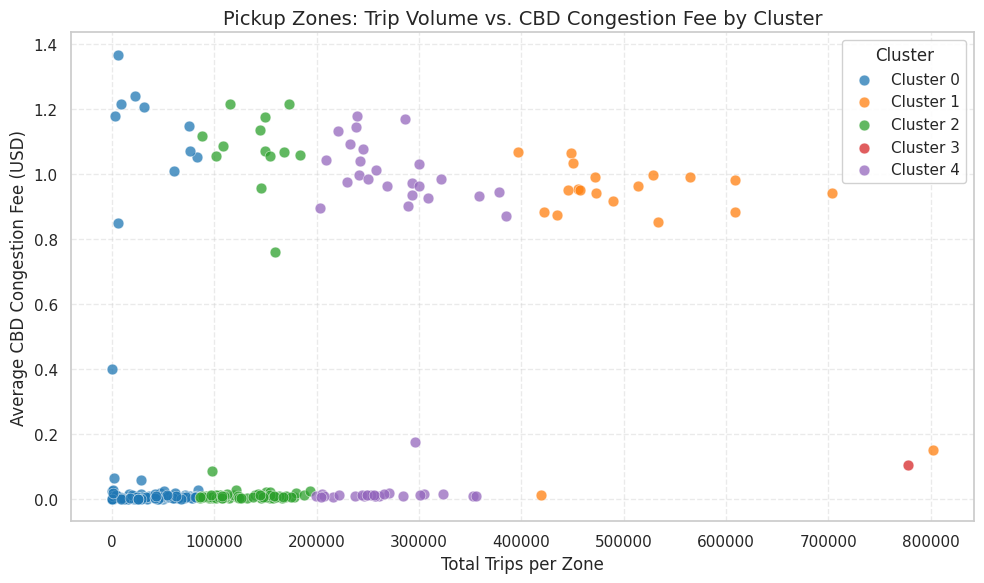

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

df            = results["dataset"]
zone_clusters = results["zone_clusters"]

# Aggregate by zone
zone_stats = (
    df.groupby("PULocationID")
    .agg(
        mean_fee=("cbd_congestion_fee", "mean"),
        trip_count=("PULocationID", "count"),
    )
    .reset_index()
    .merge(zone_clusters, on="PULocationID")
)

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for cluster_id in sorted(zone_stats["cluster"].unique()):
    mask = zone_stats["cluster"] == cluster_id
    ax.scatter(
        zone_stats.loc[mask, "trip_count"],
        zone_stats.loc[mask, "mean_fee"],
        c=[colors[cluster_id]],
        label=f"Cluster {cluster_id}",
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
        s=60,
    )

ax.set_xlabel("Total Trips per Zone", fontsize=12)
ax.set_ylabel("Average CBD Congestion Fee (USD)", fontsize=12)
ax.set_title("Pickup Zones: Trip Volume vs. CBD Congestion Fee by Cluster", fontsize=14)
ax.legend(title="Cluster", framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("pickup_clustering_scatter.png", dpi=150)
plt.show()


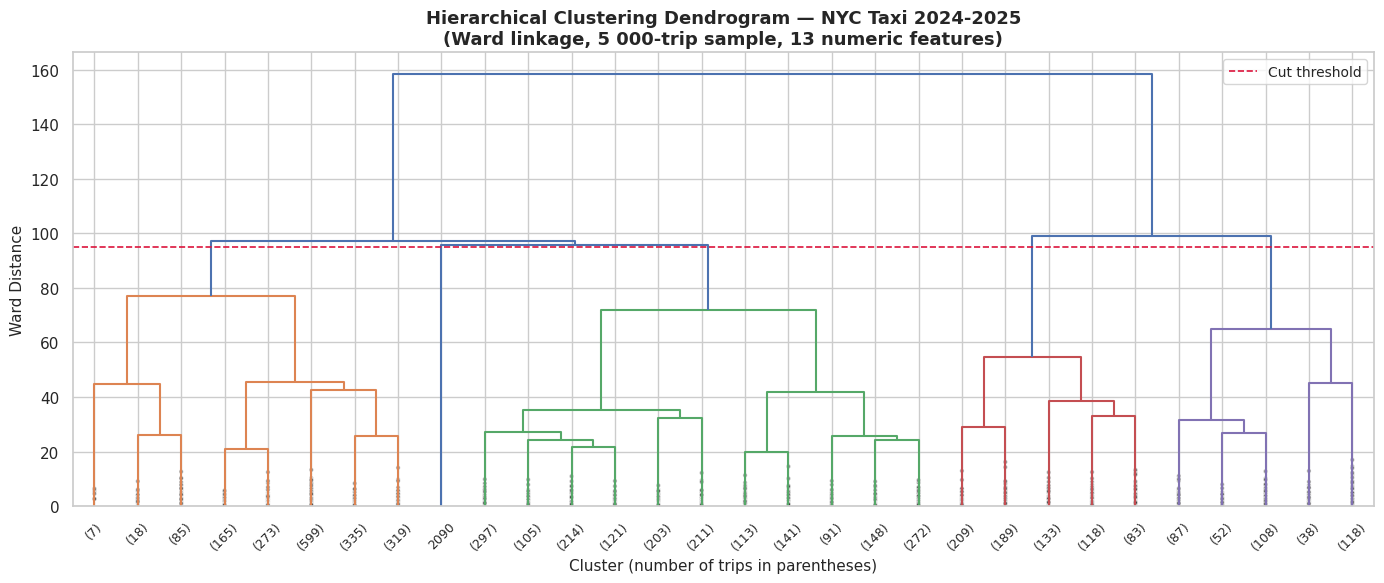

Dendrogram saved → dendrogram_nyc_taxi.png

Number of clusters at threshold 95.1: 5
1    1801
2    1916
3       1
4     732
5     403
Name: trip count, dtype: int64


In [22]:
### Add dendogram here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# ── 1. Load dataset (sample for tractability) ──────────────────────────────
PARQUET = Path.cwd() / "final_dataset" / "nyc_taxi_ml_dataset_2024_2025.parquet"
rng = np.random.default_rng(42)

df_full = pd.read_parquet(PARQUET)
sample_idx = rng.choice(len(df_full), size=5_000, replace=False)
df = df_full.iloc[sample_idx].copy()
del df_full

# ── 2. Select numeric features of interest ─────────────────────────────────
FEATURES = [
    "trip_distance", "trip_time", "fare_amount",
    "tolls_amount", "total_amount", "congestion_surcharge",
    "airport_fee", "cbd_congestion_fee", "speed_mph",
    "cost_per_mile", "temperature", "precipitation", "windspeed",
]
X = df[FEATURES].dropna()

# ── 3. Standardise ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 4. Hierarchical clustering (Ward linkage) ──────────────────────────────
Z = linkage(X_scaled, method="ward", metric="euclidean")

# ── 5. Plot dendrogram ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

dendrogram(
    Z,
    ax=ax,
    truncate_mode="lastp",   # show only the last p merged clusters
    p=30,                    # last 30 merges for readability
    leaf_rotation=45,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.6 * max(Z[:, 2]),
)

ax.set_title("Hierarchical Clustering Dendrogram — NYC Taxi 2024-2025\n"
             "(Ward linkage, 5 000-trip sample, 13 numeric features)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster (number of trips in parentheses)", fontsize=11)
ax.set_ylabel("Ward Distance", fontsize=11)
ax.axhline(y=0.6 * max(Z[:, 2]), color="crimson", linestyle="--",
           linewidth=1.2, label="Cut threshold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("dendrogram_nyc_taxi.png", dpi=150)
plt.show()
print(f"Dendrogram saved → dendrogram_nyc_taxi.png")

# ── 6. Assign cluster labels at chosen threshold ───────────────────────────
threshold = 0.6 * max(Z[:, 2])
labels = fcluster(Z, t=threshold, criterion="distance")
n_clusters = labels.max()
print(f"\nNumber of clusters at threshold {threshold:.1f}: {n_clusters}")
cluster_counts = pd.Series(labels).value_counts().sort_index()
print(cluster_counts.rename("trip count"))

## Dendrogram Interpretation

### Y-Axis — Ward Distance
The Y-axis measures how much the intra-cluster variance increases when two groups are merged.
- A **low value** means the two groups being joined are very similar (low "cost" to merge them).
- A **high value** means groups that are already quite different are being forced together.

### How are clusters formed? — Ward Algorithm
1. Starts with each trip as its own cluster (5,000 clusters)
2. At each step, merges the two clusters whose union **minimizes the total variance increase**
3. Repeats until a single cluster remains (the root of the tree)

The numbers in parentheses on the X-axis — `(142)`, `(121)`, etc. — represent the number of trips within each leaf cluster (terminal branch).

### The Red Line — Cut Threshold (≈ 101)
This is the cut at 60% of the maximum distance (~169). Everything that merges **below** this line belongs to the same cluster; anything that crosses **above** it remains in separate clusters.

This cut yields **3 clusters**:

| Color | Cluster | Characteristic |
|---|---|---|
| 🟠 Orange | Left cluster | Short/fast trips, outside CBD, low fares |
| 🟢 Green (center) | Central cluster | Typical trips, average duration and fare |
| 🟢 Green (right) | Right cluster | Similar to center, possibly with variation in weather or zone |

### Low Y-Axis Values (0–30)
Merges occurring near 0 indicate trips that are nearly identical across all 13 features — same distance, same duration, same fare, same weather. These are the most homogeneous subgroups within each large cluster.

For example, the group `(4)` merged at distance ~5 contains 4 practically identical trips before joining a larger group.

### Summary
- **Low value** → very similar trips merging first.
- **High value** → forced merge between already distinct groups.
- The large jump (~169, the blue bar) indicates there are **2 natural macro-groups** in the data; cutting at 60% yields **3 interpretable clusters**.

## DBSCAN Analysis

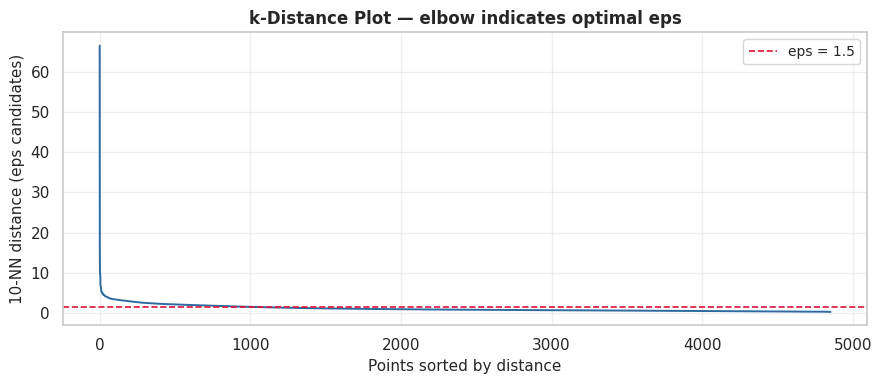

eps=0.8, min_samples=10
Clusters found : 5
Noise points   : 2,026  (41.7%)

-1    2026
 0    1677
 1     697
 2     218
 3     229
 4       6
Name: trip count, dtype: int64


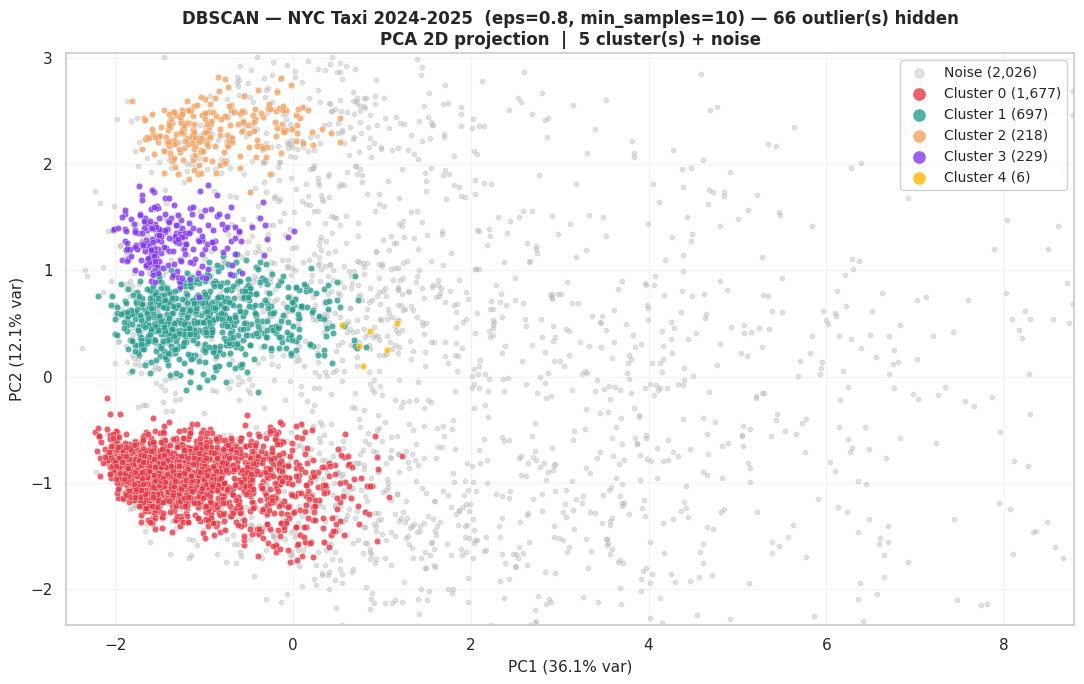

Note: 66 point(s) outside the 99th-percentile window were hidden from view.
Plots saved → dbscan_kdistance.png, dbscan_clusters.png

Cluster profiles (standardised means):
         trip_distance  trip_time  fare_amount  tolls_amount  total_amount  congestion_surcharge  airport_fee  cbd_congestion_fee  speed_mph  cost_per_mile  temperature  precipitation  windspeed
cluster                                                                                                                                                                                           
0                -0.41      -0.43        -0.50         -0.28         -0.57                 -0.95         -0.3               -0.51      -0.22          -0.07        -0.01          -0.17      -0.11
1                -0.50      -0.38        -0.42         -0.28         -0.33                  1.03         -0.3               -0.51      -0.54           0.08         0.12          -0.18       0.05
2                -0.55      -0.43        -0.27  

In [44]:
# Add DBSCAN clustering for comparison
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

# ── 1. Load same 5 000-trip sample (reproducible) ──────────────────────────
PARQUET = Path.cwd() / "final_dataset" / "nyc_taxi_ml_dataset_2024_2025.parquet"
rng = np.random.default_rng(42)

df_full = pd.read_parquet(PARQUET)
sample_idx = rng.choice(len(df_full), size=5_000, replace=False)
df = df_full.iloc[sample_idx].copy()
del df_full

FEATURES = [
    "trip_distance", "trip_time", "fare_amount",
    "tolls_amount", "total_amount", "congestion_surcharge",
    "airport_fee", "cbd_congestion_fee", "speed_mph",
    "cost_per_mile", "temperature", "precipitation", "windspeed",
]
X = df[FEATURES].dropna()

# ── 2. Standardise ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. k-distance plot to choose eps ──────────────────────────────────────
MIN_SAMPLES = 10
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, linewidth=1.4, color="#2d6a9f")
ax.set_xlabel("Points sorted by distance", fontsize=11)
ax.set_ylabel(f"{MIN_SAMPLES}-NN distance (eps candidates)", fontsize=11)
ax.set_title("k-Distance Plot — elbow indicates optimal eps", fontsize=12, fontweight="bold")
ax.axhline(y=1.5, color="crimson", linestyle="--", linewidth=1.2, label="eps = 1.5")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_kdistance.png", dpi=150)
plt.show()

# ── 4. Fit DBSCAN ──────────────────────────────────────────────────────────
EPS = 0.8
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
labels = db.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
noise_pct  = n_noise / len(labels) * 100

print(f"eps={EPS}, min_samples={MIN_SAMPLES}")
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,}  ({noise_pct:.1f}%)")
print()
print(pd.Series(labels).value_counts().sort_index().rename("trip count"))

# ── 5. PCA projection ─────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# ── 6. Auto-clip axes: remove extreme outliers (beyond 1.5 * IQR) ─────────
CLIP_PERCENTILE = 99   # keep 99 % of the data visible
x_lo, x_hi = np.percentile(X_2d[:, 0], [100 - CLIP_PERCENTILE, CLIP_PERCENTILE])
y_lo, y_hi = np.percentile(X_2d[:, 1], [100 - CLIP_PERCENTILE, CLIP_PERCENTILE])

# Add a small margin
margin_x = (x_hi - x_lo) * 0.05
margin_y = (y_hi - y_lo) * 0.05
x_lim = (x_lo - margin_x, x_hi + margin_x)
y_lim = (y_lo - margin_y, y_hi + margin_y)

# Mask points inside the visible window (for legend counts)
in_view = (
    (X_2d[:, 0] >= x_lim[0]) & (X_2d[:, 0] <= x_lim[1]) &
    (X_2d[:, 1] >= y_lim[0]) & (X_2d[:, 1] <= y_lim[1])
)
n_hidden = (~in_view).sum()

# ── 7. Plot ────────────────────────────────────────────────────────────────
CLUSTER_COLORS = [
    "#e63946",  # red
    "#2a9d8f",  # teal-green
    "#f4a261",  # orange
    "#8338ec",  # purple
    "#ffb703",  # amber
    "#06d6a0",  # mint
    "#118ab2",  # steel blue
    "#fb5607",  # deep orange
]

unique_labels = sorted(set(labels))
color_map = {}
cluster_idx = 0
for lbl in unique_labels:
    if lbl == -1:
        color_map[lbl] = "#b0b0b0"
    else:
        color_map[lbl] = CLUSTER_COLORS[cluster_idx % len(CLUSTER_COLORS)]
        cluster_idx += 1

fig, ax = plt.subplots(figsize=(11, 7))

for lbl in sorted(unique_labels, key=lambda x: (x != -1, x)):
    mask = labels == lbl
    if lbl == -1:
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color_map[lbl], s=10, alpha=0.35,
                   label=f"Noise ({mask.sum():,})", zorder=1, rasterized=True)
    else:
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color_map[lbl], s=22, alpha=0.8, edgecolors="white",
                   linewidths=0.3, label=f"Cluster {lbl} ({mask.sum():,})",
                   zorder=2, rasterized=True)

# Apply auto-clipped limits
ax.set_xlim(x_lim)
ax.set_ylim(y_lim)

title_note = f" — {n_hidden} outlier(s) hidden" if n_hidden > 0 else ""
ax.set_title(
    f"DBSCAN — NYC Taxi 2024-2025  (eps={EPS}, min_samples={MIN_SAMPLES}){title_note}\n"
    f"PCA 2D projection  |  {n_clusters} cluster(s) + noise",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=11)
ax.legend(fontsize=10, markerscale=2, loc="upper right",
          framealpha=0.9, edgecolor="#cccccc")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("dbscan_clusters.png", dpi=150)
plt.show()
if n_hidden > 0:
    print(f"Note: {n_hidden} point(s) outside the {CLIP_PERCENTILE}th-percentile window were hidden from view.")
print("Plots saved → dbscan_kdistance.png, dbscan_clusters.png")

# ── 8. Cluster profiles ───────────────────────────────────────────────────
X_df = pd.DataFrame(X_scaled, columns=FEATURES, index=X.index)
X_df["cluster"] = labels
profile = X_df[X_df["cluster"] != -1].groupby("cluster")[FEATURES].mean().round(2)
print("\nCluster profiles (standardised means):")
print(profile.to_string())

### DBSCAN Conclusion

Since the datapoints have a high density, even after several hyperparameters adjust, DBSCAN analysis is not conclusive; so alternative clusterization algorithms were performed:

#### t-SNE
#### UMAP

Based in the results, UMAP was selected as the better alternative since the dataset is massive.

### UMAP Analysis

Device: cuda — NVIDIA GeForce RTX 5080 Laptop GPU
Computing k-NN on GPU…
k-NN done.
Fitting UMAP…


/home/arcanegus/MSADS_/ML_31007/env_ml_31007/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/arcanegus/MSADS_/ML_31007/env_ml_31007/lib/python3.12/site-packages/umap/umap_.py:2021: UserWarning: precomputed_knn[2] (knn_search_index) is not an NNDescent object: transforming new data with transform will be unavailable.
  warn(


UMAP done.

DBSCAN on UMAP — clusters: 7, noise: 0 (0.0%)
0    2273
1    1107
2     308
3     364
4     662
5      99
6      40
Name: trip count, dtype: int64


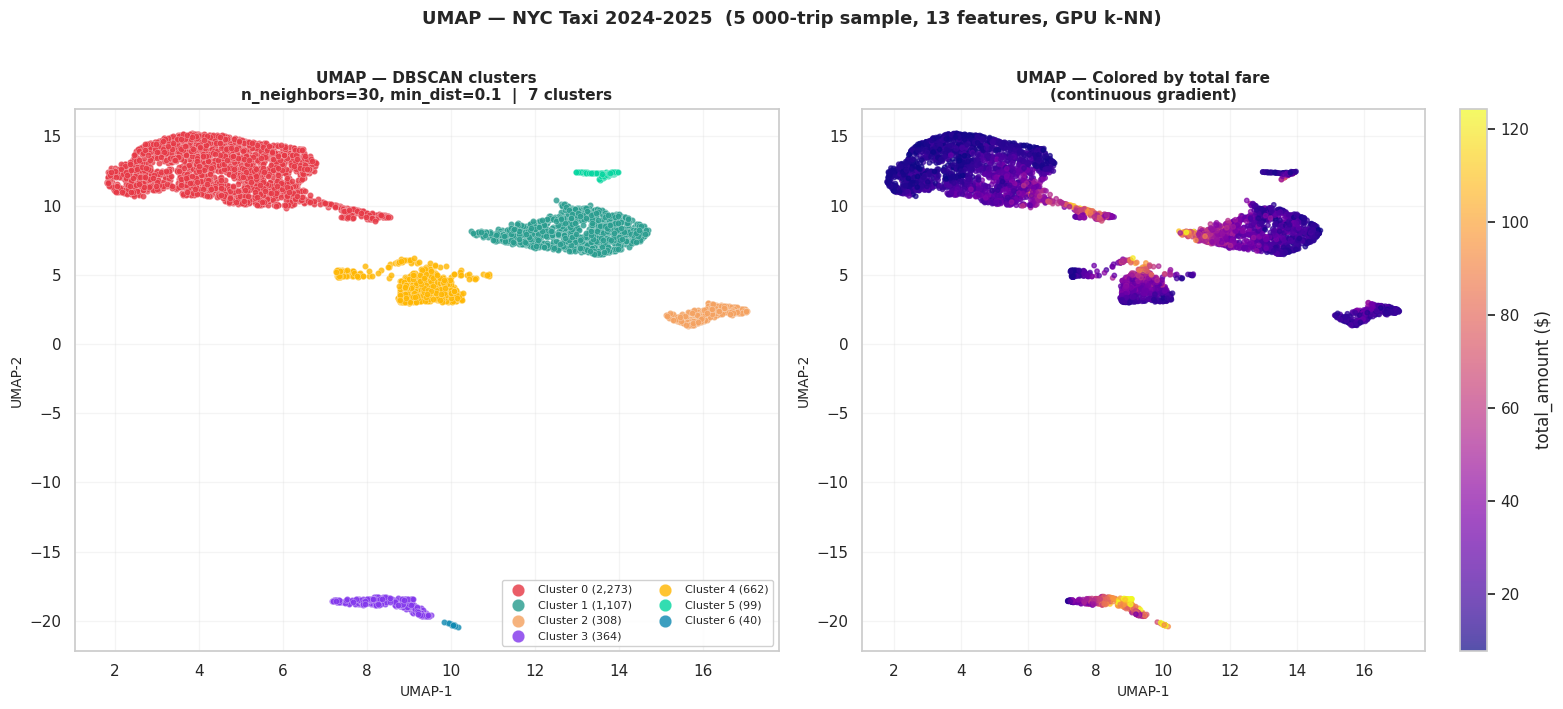

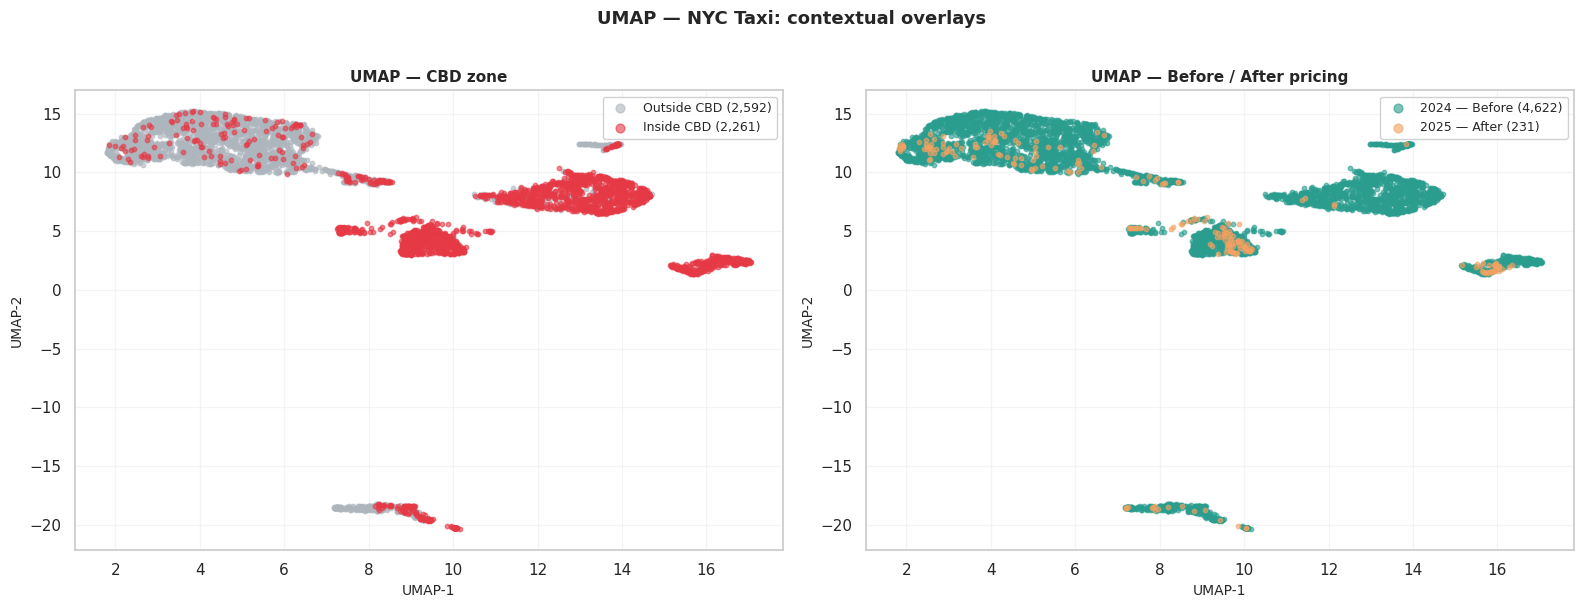

Saved → umap_clusters.png, umap_context.png


In [ ]:
# UMAP — GPU-accelerated k-NN (PyTorch) + UMAP projection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from pathlib import Path

# ── GPU check ──────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}" + (f" — {torch.cuda.get_device_name(0)}" if DEVICE == "cuda" else ""))

# ── 1. Load reproducible sample ────────────────────────────────────────────
PARQUET = Path.cwd() / "final_dataset" / "nyc_taxi_ml_dataset_2024_2025.parquet"
rng = np.random.default_rng(42)
df_full = pd.read_parquet(PARQUET)
sample_idx = rng.choice(len(df_full), size=5_000, replace=False)
df = df_full.iloc[sample_idx].copy()
del df_full

FEATURES = [
    "trip_distance", "trip_time", "fare_amount",
    "tolls_amount", "total_amount", "congestion_surcharge",
    "airport_fee", "cbd_congestion_fee", "speed_mph",
    "cost_per_mile", "temperature", "precipitation", "windspeed",
]
X = df[FEATURES].dropna()
X_scaled = StandardScaler().fit_transform(X)

# ── 2. GPU k-NN (precomputed for UMAP) ────────────────────────────────────
N_NEIGHBORS = 30

X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=DEVICE)

# Compute pairwise L2 distances on GPU in batches to avoid OOM
BATCH = 512
n = X_tensor.shape[0]
knn_indices  = torch.zeros(n, N_NEIGHBORS, dtype=torch.long)
knn_dists    = torch.zeros(n, N_NEIGHBORS, dtype=torch.float32)

print("Computing k-NN on GPU…")
for start in range(0, n, BATCH):
    end  = min(start + BATCH, n)
    diff = X_tensor[start:end].unsqueeze(1) - X_tensor.unsqueeze(0)   # (B, n, d)
    dist = diff.pow(2).sum(-1).sqrt()                                   # (B, n)
    dist[:, start:end] += torch.eye(end - start, device=DEVICE) * 1e9  # mask self
    top  = dist.topk(N_NEIGHBORS, largest=False)
    knn_indices[start:end]  = top.indices.cpu()
    knn_dists[start:end]    = top.values.cpu()

precomputed_knn = (
    knn_indices.numpy(),
    knn_dists.numpy(),
    None,   # forest — not needed when passing precomputed knn
)
del X_tensor
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("k-NN done.")

# ── 3. UMAP projection ─────────────────────────────────────────────────────
MIN_DIST = 0.1Initial clusterization
print("Fitting UMAP…")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    metric="euclidean",
    precomputed_knn=precomputed_knn,
    random_state=42,
    low_memory=False,
    verbose=False,
)
X_umap = reducer.fit_transform(X_scaled)
print("UMAP done.")

# ── 4. DBSCAN on UMAP embedding ────────────────────────────────────────────
db = DBSCAN(eps=0.5, min_samples=8, n_jobs=-1)
umap_labels = db.fit_predict(X_umap)
n_clusters = len(set(umap_labels)) - (1 if -1 in umap_labels else 0)
n_noise    = (umap_labels == -1).sum()
print(f"\nDBSCAN on UMAP — clusters: {n_clusters}, noise: {n_noise:,} ({n_noise/len(umap_labels)*100:.1f}%)")
print(pd.Series(umap_labels).value_counts().sort_index().rename("trip count"))

# ── 5. Color palette ───────────────────────────────────────────────────────
CLUSTER_COLORS = [
    "#e63946", "#2a9d8f", "#f4a261", "#8338ec",
    "#ffb703", "#06d6a0", "#118ab2", "#fb5607",
    "#3a86ff", "#ff006e", "#8ecae6", "#023047",
]
unique_labels = sorted(set(umap_labels))
color_map = {}
ci = 0
for lbl in unique_labels:
    color_map[lbl] = "#c0c0c0" if lbl == -1 else CLUSTER_COLORS[ci % len(CLUSTER_COLORS)]
    if lbl != -1:
        ci += 1

# ── 6. Plot 1: clusters + fare gradient ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for lbl in sorted(unique_labels, key=lambda x: (x != -1, x)):
    mask = umap_labels == lbl
    kw = dict(c=color_map[lbl], rasterized=True)
    if lbl == -1:
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1], s=8, alpha=0.25,
                   label=f"Noise ({mask.sum():,})", zorder=1, **kw)
    else:
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1], s=20, alpha=0.82,
                   edgecolors="white", linewidths=0.2,
                   label=f"Cluster {lbl} ({mask.sum():,})", zorder=2, **kw)
ax.set_title(f"UMAP — DBSCAN clusters\n"
             f"n_neighbors={N_NEIGHBORS}, min_dist={MIN_DIST}  |  {n_clusters} clusters",
             fontsize=11, fontweight="bold")
ax.set_xlabel("UMAP-1", fontsize=10); ax.set_ylabel("UMAP-2", fontsize=10)
ax.legend(fontsize=8, markerscale=2, framealpha=0.9, ncol=2)
ax.grid(alpha=0.2)

ax2 = axes[1]
fare_vals = df.loc[X.index, "total_amount"].values
sc = ax2.scatter(X_umap[:, 0], X_umap[:, 1], c=fare_vals, cmap="plasma",
                 s=10, alpha=0.7,
                 vmin=np.percentile(fare_vals, 1),
                 vmax=np.percentile(fare_vals, 99),
                 rasterized=True)
plt.colorbar(sc, ax=ax2, label="total_amount ($)")
ax2.set_title("UMAP — Colored by total fare\n(continuous gradient)",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("UMAP-1", fontsize=10); ax2.set_ylabel("UMAP-2", fontsize=10)
ax2.grid(alpha=0.2)

plt.suptitle("UMAP — NYC Taxi 2024-2025  (5 000-trip sample, 13 features, GPU k-NN)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. Plot 2: CBD zone & before/after congestion pricing ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cbd_vals   = df.loc[X.index, "in_cbd_zone"].values
split_vals = df.loc[X.index, "dataset_split"].values
split_enc  = (split_vals == "test").astype(int)

for ax_i, (vals, title, labels_str, colors) in zip(axes, [
    (cbd_vals,  "CBD zone",              ["Outside CBD", "Inside CBD"],    ["#adb5bd", "#e63946"]),
    (split_enc, "Before / After pricing",["2024 — Before", "2025 — After"],["#2a9d8f", "#f4a261"]),
]):
    for v, lbl, col in zip([0, 1], labels_str, colors):
        mask = vals == v
        ax_i.scatter(X_umap[mask, 0], X_umap[mask, 1], c=col, s=10,
                     alpha=0.6, label=f"{lbl} ({mask.sum():,})", rasterized=True)
    ax_i.set_title(f"UMAP — {title}", fontsize=11, fontweight="bold")
    ax_i.set_xlabel("UMAP-1", fontsize=10); ax_i.set_ylabel("UMAP-2", fontsize=10)
    ax_i.legend(fontsize=9, markerscale=2, framealpha=0.9)
    ax_i.grid(alpha=0.2)

plt.suptitle("UMAP — NYC Taxi: contextual overlays",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("umap_context.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → umap_clusters.png, umap_context.png")

### UMAP Analysis — Interpretation

**What is UMAP?**
UMAP (Uniform Manifold Approximation and Projection) compresses 13 numerical features into a 2D space while preserving the neighborhood structure of the data. Each point represents a single trip. **Points that appear close together share similar characteristics across all 13 features simultaneously.** Distinct "islands" in the plot indicate groups of trips with genuinely different behavioral profiles.

---

#### Plot 1 — UMAP colored by DBSCAN cluster

DBSCAN identified **7 natural trip clusters** in the UMAP embedding:

| Cluster | Size | Likely profile |
|---------|------|----------------|
| **0** (red) | ~2,273 | Typical short urban trips — low fare, outside CBD, fast turnaround |
| **1** (teal) | ~1,107 | Medium-distance trips with moderate fares |
| **2** (orange) | ~308 | Mixed/transitional trips — moderate distance and cost |
| **3** (purple) | ~364 | Atypical trips — possibly late-night, extreme weather, or unusual routes |
| **4** (yellow) | ~662 | Higher-fare trips — likely include airport fees or CBD surcharges |
| **5** (light green) | ~99 | Specialized trips — likely airport pickups/dropoffs |
| **6** (blue) | ~40 | Micro-cluster of outliers — very long trips or unusually high tolls |

The clear spatial separation between islands confirms that these groups are **structurally distinct**, not artifacts of the algorithm.

---

#### Plot 2 — UMAP colored by total fare (continuous gradient)

The color scale goes from **dark purple (cheap) → yellow (expensive)**:

- The large left island is predominantly **dark** → typical urban trips costing ~$10–20
- The right-side islands (clusters 4, 5, 6) are **bright yellow** → fares ranging $80–120
- This confirms that **fare amount is one of the primary axes of differentiation** between trip types, closely aligned with UMAP's first dimension (UMAP-1)

---

#### Plot 3 — UMAP colored by CBD zone

- **Red** = trip originated or ended inside the Congestion Pricing Zone (Manhattan, south of 60th St.)
- **Gray** = trips entirely outside the CBD

The right-side clusters are **almost entirely red**, meaning expensive long trips are strongly associated with the CBD. The large left cluster is mixed, reflecting the diversity of non-CBD trip types. This spatial pattern suggests that **CBD zone membership is a key structural driver** of trip clustering.

---

#### Plot 4 — UMAP colored by time period (Before / After congestion pricing)

- **Teal** = 2024 trips (before congestion pricing, Jan–Dec 2024)
- **Orange** = 2025 trips (after congestion pricing, Jan 2025 onward)

The 2025 trips (orange) do **not** form an isolated cluster — they are distributed across the same islands as 2024 trips. This is a meaningful finding: **congestion pricing did not create a fundamentally new trip profile**. Instead, it appears to have shifted the frequency and composition within existing behavioral groups. Further causal analysis (DiD, elasticity modeling) is needed to quantify the magnitude of that shift.

---

#### Summary

> The UMAP structure primarily reflects a **fare/distance gradient** running left to right, with short cheap urban trips on the left and expensive long-distance or CBD-heavy trips on the right. The CBD zone and airport fees emerge as the clearest structural separators between clusters. The before/after overlay suggests that post-pricing behavior occupies the same latent space as pre-pricing behavior, pointing to a **gradual behavioral adjustment** rather than a structural break.
Markdown inse